In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [21]:
!pip install --upgrade pandas
!pip install openquake.engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 93.2 MB/s eta 0:00:00


In [3]:
# @title Importación librerias pygmt y gpd
!sudo apt update
!sudo apt upgrade -y
!sudo apt install -y build-essential cmake libcurl4-gnutls-dev libnetcdf-dev gdal-bin libgdal-dev libfftw3-dev libpcre3-dev liblapack-dev libblas-dev libglib2.0-dev ghostscript ghostscript-x graphicsmagick ffmpeg xdg-utils
!git clone --depth 50 https://github.com/GenericMappingTools/gmt
!cmake /content/gmt
!cmake --build . --target install
!pip install https://github.com/GenericMappingTools/pygmt/archive/master.zip
!pip install pygmt
!pip install scipy==1.11.2

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,155 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,543 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd

In [15]:
%cd /usr/local/lib/python3.11/dist-packages/openquake
!git clone --filter=blob:none --sparse https://github.com/gem/oq-engine.git
%cd oq-engine
!git sparse-checkout set demos
%cd /usr/local/lib/python3.11/dist-packages/openquake

[Errno 2] No such file or directory: '/usr/local/lib/python3.11/dist-packages/openquake'
/content
Cloning into 'oq-engine'...
remote: Enumerating objects: 546597, done.
remote: Counting objects: 100% (973/973), done.
remote: Compressing objects: 100% (253/253), done.
remote: Total 546597 (delta 812), reused 757 (delta 720), pack-reused 545624 (from 4)
Receiving objects: 100% (546597/546597), 74.06 MiB | 14.21 MiB/s, done.
Resolving deltas: 100% (330372/330372), done.
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 28 (delta 11), reused 11 (delta 11), pack-reused 9 (from 3)
Receiving objects: 100% (28/28), 48.44 KiB | 4.04 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/oq-engine
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 182 (delta 75), reused 18 (delta 18), pack-reused

In [1]:
!pip install numpy==1.25.2 --force-reinstall

  Using cached numpy-1.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pygmt 999.999.999+unknown requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.25.2 which is incompatible.
scikit-image 0.25.2 requires scipy>=1.11.4, but you have scipy 1.11.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.25.2 which is incompatible.
blo

In [9]:
import pandas as pd
import numpy as np
import math
from shapely.geometry import Point, Polygon
import geopandas as gpd
import matplotlib.pyplot as plt


In [7]:
# Carga el shapefile
shapefile_path_5km = '/content/drive/MyDrive/Codigos_Proyecto NEXA/slab2.0 - subduction/sam_depth_5km.shp'
gdf_5km = gpd.read_file(shapefile_path_5km)

shapefile_path_20km = '/content/drive/MyDrive/Codigos_Proyecto NEXA/slab2.0 - subduction/sam_depth_20km.shp'
gdf_20km = gpd.read_file(shapefile_path_20km)


# Define el polígono de recorte
bounds = [(-88, 0), (-62, 0), (-62, -20), (-88, -20)]  # Coordenadas (lon, lat)
polygon = Polygon(bounds)

# Crea un GeoDataFrame con el polígono
clipping_mask_5km = gpd.GeoDataFrame(geometry=[polygon], crs=gdf_5km.crs)
clipping_mask_20km = gpd.GeoDataFrame(geometry=[polygon], crs=gdf_20km.crs)

# Acota el shapefile usando clip
clipped_gdf_5km = gpd.clip(gdf_5km, clipping_mask_5km)
clipped_gdf_20km = gpd.clip(gdf_20km, clipping_mask_20km)

# Guarda el shapefile acotado (opcional)
clipped_gdf_5km.to_file('/content/drive/MyDrive/Codigos_Proyecto NEXA/shape - slab - cortado/slab_modificado_5km.shp')
clipped_gdf_20km.to_file('/content/drive/MyDrive/Codigos_Proyecto NEXA/shape - slab - cortado/slab_modificado_20km.shp')



In [3]:
polys_interfase = gpd.GeoSeries({
    'F-1a': Polygon([(-81.558,-2.43),(-80.041,-2.07),(-80.042,-1.344),(-79.998,-1.147),(-79.841,-0.492),(-79.495,0.323),(-79.212,0.79),(-78.914,1.227),(-78.597,1.648),(-78.266,2.016),(-77.579,2.914),(-78.664,3.318),(-79.388,2.507),(-79.924,1.898),(-80.16,1.622),(-80.418,1.226),(-80.669,0.71),(-80.997,-0.056),(-81.295,-0.649),(-81.367,-1.006),(-81.477,-1.506),(-81.552,-1.885)]),
    'F-2a': Polygon([(-81.933,-6.015),(-80.25,-5.459),(-80.281,-4.844),(-80.251,-4.406),(-80.145,-3.833),(-80.088,-3.369),(-80.047,-2.808),(-80.041,-2.07),(-81.558,-2.43),(-81.608,-2.799),(-81.695,-3.158),(-81.859,-3.852),(-81.94,-4.411),(-81.954,-5.315)]),
    'F-3a': Polygon([(-81.933,-6.015),(-80.25,-5.459),(-80.145,-5.943),(-79.388,-7.934),(-79.159,-8.475),(-78.675,-9.455),(-80.008,-10.191),(-80.008,-10.191),(-80.011,-10.19),(-80.201,-9.878),(-80.404,-9.527),(-80.908,-8.651),(-81.249,-7.952),(-81.576,-7.21),(-81.776,-6.65)]),
    'F-4a': Polygon([(-78.675,-9.455),(-80.008,-10.191),(-79.608,-10.917),(-79.306,-11.371),(-78.927,-11.912),(-78.611,-12.403),(-78.291,-12.906),(-78.011,-13.27),(-77.529,-13.899),(-76.822,-14.736),(-75.614,-13.801),(-76.655,-12.426),(-76.877,-12.116),(-77.518,-11.333)]),
    'F-5a.1': Polygon([(-74.27,-16.889),(-74.418,-16.775),(-74.879,-16.53),(-75.356,-16.122),(-75.916,-15.558),(-76.822,-14.736),(-75.614,-13.801),(-75.329,-14.226),(-74.939,-14.755),(-74.146,-15.475),(-73.572,-15.869)]),
    'F-5a.2': Polygon([(-73.572,-15.869),(-73.28,-16.069),(-72.758,-16.439),(-72.409,-16.721),(-71.036,-17.812),(-70.564,-18.332),(-71.567,-19.373),(-71.85,-18.968),(-72.27,-18.562),(-73.064,-17.847),(-73.508,-17.475),(-74.27,-16.889)]),
    'F-6a': Polygon([(-71.567,-19.373),(-70.564,-18.332),(-70.267,-18.804),(-69.93,-19.6),(-69.829,-19.972),(-69.615,-21.516),(-69.579,-22.694),(-69.622,-23.548),(-69.86,-25.014),(-71.45,-24.976),(-71.18,-21.528),(-71.279,-20.484)]),
})
polys_intraplaca = gpd.GeoSeries({
    'F-1b.1': Polygon([(-79.841,-0.492),(-78.663,-0.755),(-77.544,-0.893),(-76.908,-0.862),(-76.732,0.216),(-76.706,0.378),(-76.519,0.979),(-76.272,1.514),(-75.942,2.383),(-77.579,2.914),(-78.266,2.016),(-78.597,1.648),(-78.914,1.227),(-79.212,0.79),(-79.495,0.323)]),
    'F-1b.2': Polygon([(-80.041,-2.07),(-80.042,-1.344),(-79.998,-1.147),(-79.998,-1.147),(-79.841,-0.492),(-78.663,-0.755),(-78.625,-1.406),(-78.505,-1.731),(-78.369,-2.142),(-78.198,-2.869),(-78.641,-2.871),(-79.424,-2.858),(-80.047,-2.808)]),
    'F-1c': Polygon([(-78.663,-0.755),(-77.544,-0.893),(-76.908,-0.862),(-76.713,-1.176),(-76.536,-1.482),(-76.475,-1.559),(-76.246,-1.756),(-75.91,-2.085),(-76.734,-2.549),(-77.598,-2.819),(-78.198,-2.869),(-78.369,-2.142),(-78.505,-1.731),(-78.625,-1.406)]),
    'F-2b': Polygon([(-80.25,-5.459),(-80.281,-4.844),(-80.251,-4.406),(-80.145,-3.833),(-80.088,-3.369),(-80.047,-2.808),(-79.424,-2.858),(-78.641,-2.871),(-78.198,-2.869),(-78.193,-3.708),(-78.193,-3.708),(-78.237,-4.191),(-78.243,-4.779)]),
    'F-2c': Polygon([(-78.243,-4.779),(-78.237,-4.191),(-78.193,-3.708),(-78.198,-2.869),(-77.598,-2.819),(-76.734,-2.549),(-75.91,-2.085),(-75.634,-2.367),(-75.396,-2.718),(-75.268,-2.987),(-75.178,-3.352),(-75.149,-3.741)]),
    'F-3b': Polygon([(-80.25,-5.459),(-78.243,-4.779),(-78.162,-5.322),(-78.005,-6.071),(-77.68,-6.613),(-77.36,-7.335),(-76.796,-8.414),(-78.675,-9.455),(-79.159,-8.475),(-79.388,-7.934),(-80.145,-5.943)]),
    'F-3c': Polygon([(-76.796,-8.414),(-77.36,-7.335),(-77.68,-6.613),(-78.005,-6.071),(-78.162,-5.322),(-78.243,-4.779),(-75.149,-3.741),(-75.131,-4.172),(-75.075,-4.643),(-75.005,-4.969),(-74.846,-5.366),(-74.643,-5.751),(-74.407,-6.146),(-74.254,-6.4),(-74.024,-6.868)]),
    'F-4b': Polygon([(-78.675,-9.455),(-76.796,-8.414),(-76.407,-9.295),(-76.111,-10.173),(-75.916,-10.622),(-75.685,-10.98),(-75.218,-11.387),(-74.846,-11.919),(-74.206,-12.707),(-75.614,-13.801),(-76.655,-12.426),(-76.877,-12.116),(-77.518,-11.333)]),
    'F-4c.1': Polygon([(-76.796,-8.414),(-74.024,-6.868),(-73.939,-7.066),(-73.844,-7.325),(-73.833,-7.885),(-73.868,-8.461),(-73.878,-8.633),(-73.835,-8.928),(-76.111,-10.173),(-76.407,-9.295)]),
    'F-4c.2': Polygon([(-76.111,-10.173),(-73.835,-8.928),(-73.74,-9.177),(-73.601,-9.417),(-73.479,-9.625),(-73.313,-9.833),(-72.891,-10.22),(-72.527,-10.613),(-72.105,-11.046),(-72.414,-11.309),(-72.417,-11.312),(-74.206,-12.707),(-74.846,-11.919),(-75.218,-11.387),(-75.685,-10.98),(-75.916,-10.622)]),
    'F-5b.1': Polygon([(-75.614,-13.801),(-74.206,-12.707),(-73.153,-13.949),(-72.397,-14.832),(-72.771,-15.217),(-73.28,-16.069),(-74.146,-15.475),(-74.939,-14.755),(-75.329,-14.226)]),
    'F-5c.1': Polygon([(-74.206,-12.707),(-72.417,-11.312),(-72.154,-11.668),(-72.015,-11.869),(-71.8,-12.331),(-71.597,-12.978),(-71.414,-13.524),(-71.309,-13.924),(-71.258,-14.171),(-72.013,-14.496),(-72.013,-14.496),(-72.397,-14.832),(-73.153,-13.949)]),
    'F-5b.2': Polygon([(-73.28,-16.069),(-72.771,-15.217),(-72.397,-14.832),(-72.013,-14.496),(-71.258,-14.171),(-71.262,-15.193),(-71.108,-15.856),(-70.707,-16.219),(-69.516,-16.97),(-70.564,-18.332),(-71.036,-17.812),(-72.409,-16.721),(-72.758,-16.439)]),
    'F-5c.2': Polygon([(-71.258,-14.171),(-70.245,-13.738),(-69.935,-14.35),(-69.813,-14.577),(-69.666,-14.714),(-69.438,-14.934),(-69.411,-14.998),(-69.067,-15.227),(-68.482,-15.613),(-68.847,-16.123),(-69.167,-16.538),(-69.516,-16.97),(-70.707,-16.219),(-71.108,-15.856),(-71.262,-15.193)]),
    'F-6b': Polygon([(-70.564,-18.332),(-69.516,-16.97),(-68.971,-17.922),(-68.575,-18.821),(-67.921,-20.595),(-67.459,-22.83),(-67.289,-24.263),(-67.256,-25.019),(-69.86,-25.014),(-69.622,-23.548),(-69.579,-22.694),(-69.615,-21.516),(-69.829,-19.972),(-69.93,-19.6),(-70.267,-18.804)]),
})
polys_corteza = gpd.GeoSeries({
    'PSe-1': Polygon([(-79.219,-2.417),(-79.256,-2.168),(-79.52,-0.082),(-78.021,1.689),(-76.925,1.172),(-77.245,-1.571)]),
    'PSe-2': Polygon([(-77.245,-1.571),(-76.847,-2.864),(-76.402,-4.64),(-78.28,-5.361),(-78.717,-4.458),(-79.219,-2.417)]),
    'PSe-3': Polygon([(-78.28,-5.361),(-76.402,-4.64),(-75.889,-5.555),(-75.516,-6.27),(-75.227,-7.379),(-76.926,-8.542),(-77.49,-7.004)]),
    'PSe-4': Polygon([(-76.402,-4.64),(-75.361,-4.599),(-73.763,-6.213),(-73.228,-8.298),(-74.063,-10.05),(-75.045,-8.717),(-75.227,-7.379),(-75.516,-6.27),(-75.889,-5.555)]),
    'PSe-5': Polygon([(-76.926,-8.542),(-75.227,-7.379),(-75.045,-8.717),(-74.063,-10.05),(-73.711,-10.545),(-72.31,-11.63),(-73.381,-12.815),(-73.861,-13.316),(-74.474,-12.821),(-75.381,-12.024)]),
    'PSe-6': Polygon([(-73.381,-12.815),(-72.31,-11.63),(-71.215,-12.137),(-70.327,-12.512),(-69.429,-12.963),(-69.81,-13.944),(-70.287,-15.166),(-70.76,-13.942),(-71.243,-13.211),(-71.969,-13.001),(-72.507,-12.871)]),
    'PSw-1': Polygon([(-78.717,-4.458),(-79.219,-2.417),(-79.256,-2.168),(-80.53,-2.897),(-80.559,-3.785),(-80.604,-4.337),(-80.572,-5.268),(-80.525,-5.589)]),
    'PSw-2': Polygon([(-78.717,-4.458),(-80.525,-5.589),(-80.121,-6.381),(-79.699,-7.211),(-79.34,-7.91),(-77.49,-7.004),(-78.28,-5.361)]),
    'PSw-3': Polygon([(-77.49,-7.004),(-76.926,-8.542),(-75.381,-12.024),(-74.474,-12.821),(-75.717,-13.738),(-76.29,-13.054),(-77.041,-11.976),(-77.373,-11.519),(-77.564,-11.212),(-78.409,-9.646),(-79.03,-8.452),(-79.34,-7.91)]),
    'PSw-4': Polygon([(-75.717,-13.738),(-74.474,-12.821),(-73.861,-13.316),(-72.13,-14.95),(-73.102,-16.274),(-73.515,-16.001),(-74.793,-14.7)]),
    'PSw-5': Polygon([(-73.861,-13.316),(-73.381,-12.815),(-72.507,-12.871),(-71.969,-13.001),(-71.243,-13.211),(-70.76,-13.942),(-70.287,-15.166),(-70.479,-15.744),(-72.13,-14.95)]),
    'PSw-6': Polygon([(-73.102,-16.274),(-72.13,-14.95),(-70.479,-15.744),(-69.175,-17.883),(-69.901,-18.512)]),
})

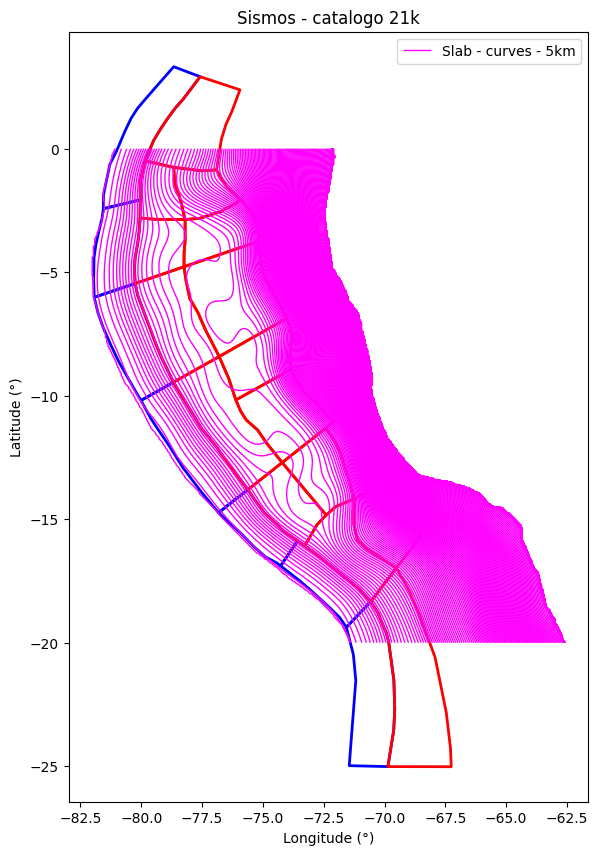

In [10]:
catalogo_path = '/content/drive/MyDrive/Codigos_Proyecto NEXA/Catalogos al 030325/catalogue_21k.csv'
df_catalogo =pd.read_csv(catalogo_path)

dgpd_catalogo = gpd.GeoDataFrame(df_catalogo, geometry=gpd.points_from_xy(df_catalogo.longitude, df_catalogo.latitude))

# Load the shapefile
shapefile_path_5km_cut = '/content/drive/MyDrive/Codigos_Proyecto NEXA/shape - slab - cortado/slab_modificado_5km.shp'
dgpd_shape_5km_cut = gpd.read_file(shapefile_path_5km_cut)

shapefile_path_20km_cut = '/content/drive/MyDrive/Codigos_Proyecto NEXA/shape - slab - cortado/slab_modificado_20km.shp'
dgpd_shape_20km_cut = gpd.read_file(shapefile_path_20km_cut)

# Create the geodataframes por interfase, intraplaca y  corteza

gdf_interfase = dgpd_catalogo[dgpd_catalogo['tectEnv'] == 'interfase']
gdf_intraplaca = dgpd_catalogo[dgpd_catalogo['tectEnv'] == 'intraplaca']
gdf_corteza = dgpd_catalogo[dgpd_catalogo['tectEnv'] == 'corteza']

# Create a single figure and axes
fig, ax = plt.subplots(figsize=(15, 10))

polys_interfase.plot(ax=ax, facecolor='none', edgecolor='blue',zorder = 1, linewidth= 2)
polys_intraplaca.plot(ax=ax, facecolor='none', edgecolor='red', zorder = 1, linewidth=2)
#polys_corteza.plot(ax=ax, color='lightcoral', edgecolor='black', label="'PSe-1' Polygon")

# Plot the dgpd_shape on the axes
dgpd_shape_5km_cut.plot(ax=ax, color='magenta', edgecolor='blue', zorder = 3, label = "Slab - curves - 5km", linewidth = 1)
#dgpd_shape_20km_cut.plot(ax=ax, color='black', edgecolor='blue', zorder = 3, label = "Slab - curves- 20km", linewidth = 2)

# Plot the GeoDataFrames with different colors
#gdf_interfase.plot(ax=ax, marker='o', color='blue', markersize=0.1, zorder=2, label = "INTERFASE")
#gdf_intraplaca.plot(ax=ax, marker='o', color='red', markersize=0.1, zorder=2, label = "INTRAPLACA")
#gdf_corteza.plot(ax=ax, marker='o', color='green', markersize=0.1, zorder=2, label = "CORTEZA")

# Set the title
ax.set_title('Sismos - catalogo 21k')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
plt.legend()
plt.show()

<ipython-input-11-62f1081d7c0f>:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


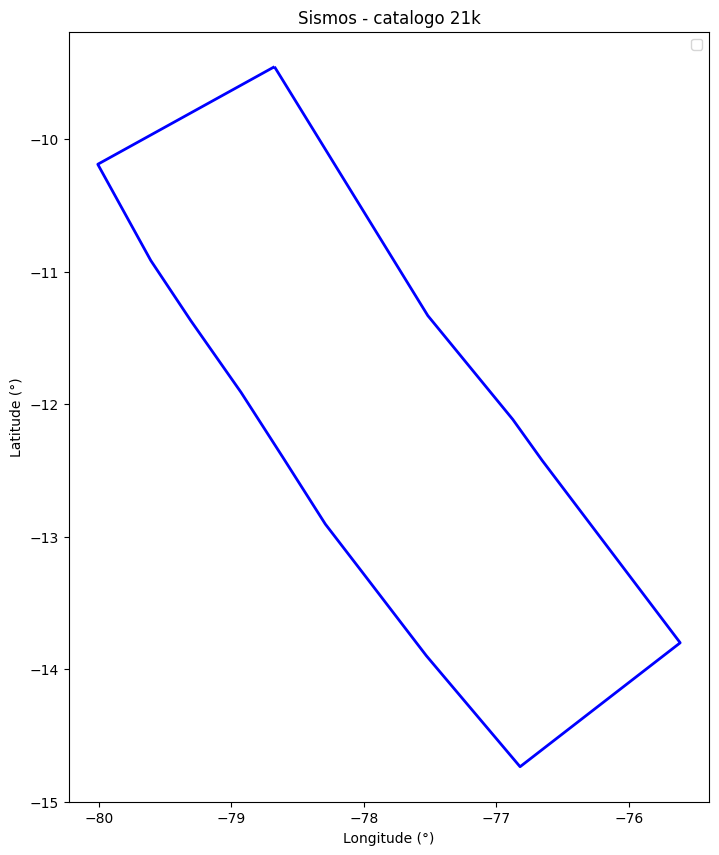

In [11]:
fuente = "interfase | F-4a" #@param ["interfase | F-3a", "interfase | F-4a","interfase | F-5a.1","intraplaca | F-3b", "intraplaca | F-3c", "intraplaca | F-4b","intraplaca | F-4c.1","intraplaca | F-4c.2", "intraplaca | F-5b.1","intraplaca | F-5c.1","corteza | PSw-3","corteza | PSw-4","corteza | PSe-3","corteza | PSe-5","corteza | PSw-5", "corteza | PSe-4", "corteza | PSe-6"]
fuente_name = fuente.split(" | ")[1]

if fuente.split(" | ")[0] == "interfase":
  poly = polys_interfase
elif fuente.split(" | ")[0] == "intraplaca":
  poly = polys_intraplaca
elif fuente.split(" | ")[0] == "corteza":
  poly = polys_corteza

f_polygon = poly[fuente_name]
f_geoseries = gpd.GeoSeries([f_polygon])

# Create a single figure and axes
fig, ax = plt.subplots(figsize=(15, 10))

f_geoseries.plot(ax=ax, facecolor='none', edgecolor='blue',zorder = 1, linewidth= 2)
#polys_corteza.plot(ax=ax, color='lightcoral', edgecolor='black', label="'PSe-1' Polygon")

# Plot the GeoDataFrames with different colors
#gdf_interfase.plot(ax=ax, marker='o', color='blue', markersize=0.1, zorder=2, label = "INTERFASE")
#gdf_intraplaca.plot(ax=ax, marker='o', color='red', markersize=0.1, zorder=2, label = "INTRAPLACA")
#gdf_corteza.plot(ax=ax, marker='o', color='green', markersize=0.1, zorder=2, label = "CORTEZA")

# Set the title
ax.set_title('Sismos - catalogo 21k')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
plt.legend()
plt.show()

<ipython-input-12-21c09cd648f6>:50: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


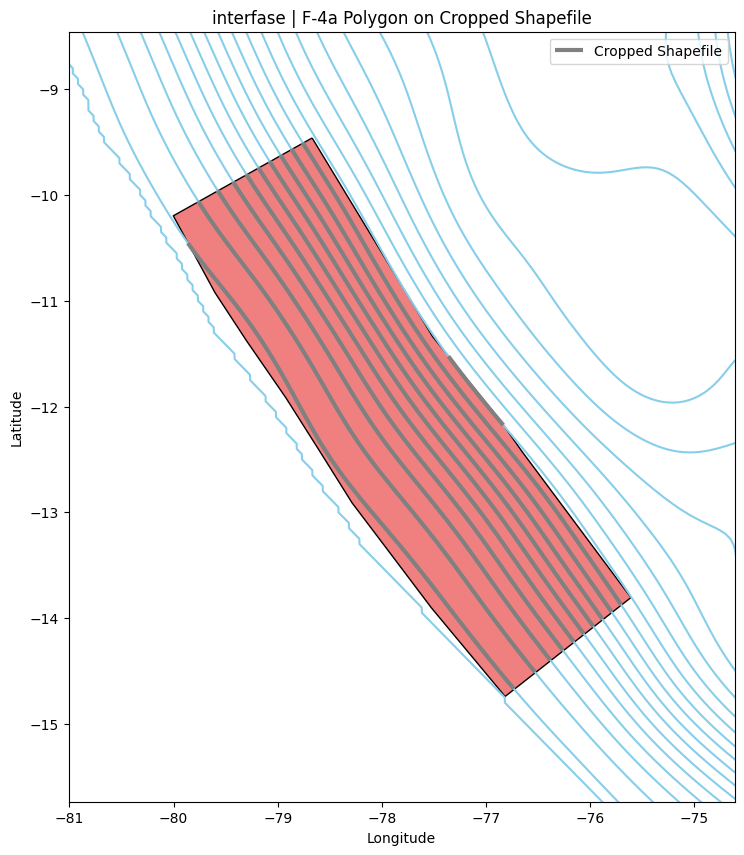

Points of slab curves within the source polygon, separated by line:
{'id': '1', 'name': 'F-4a', 'Edge': 'faultBottomEdge', 'coords': [(-77.35, -11.54, 60.0), (-77.342, -11.55, 60.0), (-77.304, -11.6, 60.0), (-77.3, -11.606, 60.0), (-77.266, -11.65, 60.0), (-77.25, -11.67, 60.0), (-77.227, -11.7, 60.0), (-77.2, -11.734, 60.0), (-77.187, -11.75, 60.0), (-77.15, -11.796, 60.0), (-77.147, -11.8, 60.0), (-77.107, -11.85, 60.0), (-77.1, -11.858, 60.0), (-77.066, -11.9, 60.0), (-77.05, -11.919, 60.0), (-77.024, -11.95, 60.0), (-77.0, -11.979, 60.0), (-76.983, -12.0, 60.0), (-76.95, -12.039, 60.0), (-76.941, -12.05, 60.0), (-76.9, -12.098, 60.0), (-76.899, -12.1, 60.0), (-76.856, -12.15, 60.0), (-76.85, -12.157, 60.0), (-76.835, -12.175, 60.0)]}

{'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-78.75, -9.523, 55.0), (-78.733, -9.55, 55.0), (-78.701, -9.6, 55.0), (-78.7, -9.602, 55.0), (-78.67, -9.65, 55.0), (-78.65, -9.681, 55.0), (-78.638, -9.7, 55.0), (-78.606, -9.75, 55.

In [12]:
# @title Linestring del Slab dentro de fuentes de interés
import geopandas as gpd
import matplotlib.pyplot as plt

fuente = "interfase | F-4a" #@param ["interfase | F-3a", "interfase | F-4a","interfase | F-5a.1","intraplaca | F-3b", "intraplaca | F-3c", "intraplaca | F-4b","intraplaca | F-4c.1","intraplaca | F-4c.2", "intraplaca | F-5b.1","intraplaca | F-5c.1","corteza | PSw-3","corteza | PSw-4","corteza | PSe-3","corteza | PSe-5","corteza | PSw-5", "corteza | PSe-4", "corteza | PSe-6"]
fuente_name = fuente.split(" | ")[1]
if fuente.split(" | ")[0] == "interfase":
  poly = polys_interfase
elif fuente.split(" | ")[0] == "intraplaca":
  poly = polys_intraplaca
elif fuente.split(" | ")[0] == "corteza":
  poly = polys_corteza

polygon_fuente = poly[fuente_name]

# Assuming 'dgpd_shape' is your original shapefile GeoDataFrame
# Crop 'dgpd_shape' to the bounds of 'pse_1_polygon'
dgpd_shape_cropped = gpd.clip(dgpd_shape_5km_cut, polygon_fuente)  # Clip dgpd_shape to_polygon
min_lon, min_lat, max_lon, max_lat = polygon_fuente.bounds

# Adjust the bounds for plotting
plot_min_lon = min_lon - 1  # Subtract 1 degree from minimum longitude
plot_max_lon = max_lon + 1  # Add 1 degree to maximum longitude
plot_min_lat = min_lat - 1  # Subtract 1 degree from minimum latitude
plot_max_lat = max_lat + 1  # Add 1 degree to maximum latitude
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 10))  # Adjust figure size as needed

# Plot the cropped shapefile
dgpd_shape_cropped.plot(ax=ax, color='gray', edgecolor='blue', label='Cropped Shapefile', zorder=4, linewidth=3)

gpd.GeoSeries([polygon_fuente]).plot(ax=ax, color='lightcoral', edgecolor='black', label="Polygon")

shapefile_path_5km_cut = '/content/drive/MyDrive/Codigos_Proyecto NEXA/shape - slab - cortado/slab_modificado_5km.shp'
dgpd_shape_5km_cut = gpd.read_file(shapefile_path_5km_cut)
dgpd_shape_5km_cut.plot(ax=ax, color="skyblue",edgecolor="black")



# Set title and labels
tilte_fig = str(fuente) + " Polygon on Cropped Shapefile"
ax.set_title(tilte_fig)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')


ax.set_xlim([plot_min_lon, plot_max_lon])
ax.set_ylim([plot_min_lat, plot_max_lat])
# Add legend
plt.legend()

# Show the plot
plt.show()

# Get points of the curves within the source polygon, separated by line
points_within_source = {}  # Use a dictionary to store points for each line
depths_by_line = {}       # Use a dictionary to store depths for each line

for index, row in dgpd_shape_cropped.iterrows():
    # Access the geometry (LineString) for each row
    geometry = row.geometry
    depth = row['level']  # Get the depth for this line

    # Check if geometry is a MultiLineString
    if geometry.geom_type == 'MultiLineString':
        # Iterate over the individual LineStrings within the MultiLineString
        for i, linestring in enumerate(geometry.geoms):
            line_id = f"{index}-{i}"  # Create a unique ID for each line
            points_within_source[line_id] = []  # Initialize list for this line's points
            depths_by_line[line_id] = depth     # Store the depth for this line

            # Iterate through the points in the LineString
            for point in linestring.coords:
                # Check if the point is within the source polygon
                if polygon_fuente.contains(Point(point)):
                    points_within_source[line_id].append(point)
    else:
        # If geometry is not a MultiLineString (e.g., LineString), proceed as before
        line_id = str(index)  # Use index as ID for single LineStrings
        points_within_source[line_id] = []
        depths_by_line[line_id] = depth

        for point in geometry.coords:
            # Check if the point is within the source polygon
            if polygon_fuente.contains(Point(point)):
                points_within_source[line_id].append(point)

# Print the points within the source polygon, separated by line
print("Points of slab curves within the source polygon, separated by line:")


# 1. Sort lines by depth (ascending)
sorted_lines = sorted(depths_by_line.items(), key=lambda item: item[1])

# 2. Create the 'data' list
data = []
for i, (line_id, depth) in enumerate(sorted_lines):
    edge_type = ""
    if i == 0:  # Shallowest line (faultBottomEdge)
        edge_type = "faultBottomEdge"
    elif i == len(sorted_lines) - 1:  # Deepest line (faultTopEdge)
        edge_type = "faultTopEdge"
    else:  # Intermediate lines (intermediateEdge)
        edge_type = "intermediateEdge"

    # Create the 'coords' list with (longitude, latitude, depth) tuples
    coords = [(round(point[0],3), round(point[1],3), -1*depth) for point in points_within_source[line_id]]

    # Add the dictionary to the 'data' list
    data.append({
        "id": "1",  # You can adjust the ID as needed
        "name": fuente_name,  # You can adjust the name as needed
        "Edge": edge_type,
        "coords": coords
    })
list_total = []
# Print the 'data' list
for item in data:
    list_total.append(item)
    print(item)
    print()  # Add a blank line to create a break
# Print the depths of each LineString
print(list_total)



for line_id, depth in depths_by_line.items():
    print(f"Line ID: {line_id}, Depth: {depth}")

In [20]:
data

[{'id': '1',
  'name': 'Fault A',
  'faultTopEdge': [(0.6, -1.4, 2), (1.0, -1.3, 5), (1.5, -1.0, 8)],
  'intermediateEdge': [[(0.65, -1.55, 4), (1.1, -1.4, 10), (1.5, -1.2, 20)],
   [(0.7, -1.5, 5), (1.2, -1.3, 11), (1.6, -1.1, 21)]],
  'faultBottomEdge': [(0.65, -1.7, 8), (1.2, -1.6, 15), (1.5, -1.7, 35)]},
 {'id': '2',
  'name': 'Fault B',
  'faultTopEdge': [(1.0, -2.0, 3), (1.2, -2.1, 6)],
  'intermediateEdge': [[(1.0, -2.2, 4), (1.3, -2.3, 7)]],
  'faultBottomEdge': [(1.4, -2.5, 9)]}]

In [19]:
import pandas as pd
import xml.etree.ElementTree as ET
import xml.dom.minidom as minidom

# Simulación de un DataFrame de entrada
data = [
    {
        "id": "1",
        "name": "Fault A",
        "faultTopEdge": [(0.6, -1.4, 2), (1.0, -1.3, 5), (1.5, -1.0, 8)],
        "intermediateEdge": [
            [(0.65, -1.55, 4), (1.1, -1.4, 10), (1.5, -1.2, 20)],
            [(0.7, -1.5, 5), (1.2, -1.3, 11), (1.6, -1.1, 21)]
        ],
        "faultBottomEdge": [(0.65, -1.7, 8), (1.2, -1.6, 15), (1.5, -1.7, 35)]
    },
    {
        "id": "2",
        "name": "Fault B",
        "faultTopEdge": [(1.0, -2.0, 3), (1.2, -2.1, 6)],
        "intermediateEdge": [
            [(1.0, -2.2, 4), (1.3, -2.3, 7)]
        ],
        "faultBottomEdge": [(1.4, -2.5, 9)]
    }
]
df = pd.DataFrame(data)

# Crear estructura base del XML
nrml = ET.Element("nrml", attrib={
    "xmlns": "http://openquake.org/xmlns/nrml/0.5",
    "xmlns:gml": "http://www.opengis.net/gml"
})

source_model = ET.SubElement(nrml, "sourceModel", name="Generated Source Model")
source_group = ET.SubElement(source_model, "sourceGroup", name="group 1", tectonicRegion="Active Shallow Crust")

# Función para convertir lista de tuplas a string gml:posList
def poslist_from_coords(coords):
    return " ".join(f"{x:.7E} {y:.7E} {z:.7E}" for x, y, z in coords)

# Generar complexFaultSource para cada fila
for _, row in df.iterrows():
    source = ET.SubElement(source_group, "complexFaultSource", id=row["id"], name=row["name"], tectonicRegion="Active Shallow Crust")
    geometry = ET.SubElement(source, "complexFaultGeometry")

    # faultTopEdge
    top_edge = ET.SubElement(geometry, "faultTopEdge")
    linestring = ET.SubElement(top_edge, "{http://www.opengis.net/gml}LineString")
    poslist = ET.SubElement(linestring, "{http://www.opengis.net/gml}posList")
    poslist.text = poslist_from_coords(row["faultTopEdge"])

    # intermediateEdges (pueden ser muchos)
    for intermediate in row["intermediateEdge"]:
        int_edge = ET.SubElement(geometry, "intermediateEdge")
        linestring = ET.SubElement(int_edge, "{http://www.opengis.net/gml}LineString")
        poslist = ET.SubElement(linestring, "{http://www.opengis.net/gml}posList")
        poslist.text = poslist_from_coords(intermediate)

    # faultBottomEdge
    bottom_edge = ET.SubElement(geometry, "faultBottomEdge")
    linestring = ET.SubElement(bottom_edge, "{http://www.opengis.net/gml}LineString")
    poslist = ET.SubElement(linestring, "{http://www.opengis.net/gml}posList")
    poslist.text = poslist_from_coords(row["faultBottomEdge"])

# Prettify usando minidom
rough_string = ET.tostring(nrml, encoding="utf-8")
reparsed = minidom.parseString(rough_string)
pretty_xml = reparsed.toprettyxml(indent="  ")

# Guardar a archivo si se desea
with open("generated_faults.xml", "w", encoding="utf-8") as f:
    f.write(pretty_xml)


In [16]:
import xml.etree.ElementTree as ET
import plotly.graph_objects as go
import numpy as np

# Namespace necesario para parsear correctamente
ns = {
    'nrml': 'http://openquake.org/xmlns/nrml/0.5',
    'gml': 'http://www.opengis.net/gml'
}

# Cargar y parsear el archivo XML
tree = ET.parse('/usr/local/lib/python3.11/dist-packages/openquake/oq-engine/generated_faults.xml')  # Cambia esto por tu archivo real
root = tree.getroot()

# Extraer las listas de posiciones
coordinates = {}

# Procesar faultTopEdge
top_edge = root.find(".//nrml:faultTopEdge/gml:LineString/gml:posList", ns)
if top_edge is not None:
    pos_list = list(map(float, top_edge.text.strip().split()))
    coords = [(pos_list[i], pos_list[i+1], pos_list[i+2]) for i in range(0, len(pos_list), 3)]
    coordinates['faultTopEdge'] = [coords]

# Procesar todas las intermediateEdge
intermediate_edges = root.findall(".//nrml:intermediateEdge/gml:LineString/gml:posList", ns)
if intermediate_edges:
    coordinates['intermediateEdge'] = []
    for idx, elem in enumerate(intermediate_edges):
        pos_list = list(map(float, elem.text.strip().split()))
        coords = [(pos_list[i], pos_list[i+1], pos_list[i+2]) for i in range(0, len(pos_list), 3)]
        coordinates['intermediateEdge'].append(coords)

# Procesar faultBottomEdge
bottom_edge = root.find(".//nrml:faultBottomEdge/gml:LineString/gml:posList", ns)
if bottom_edge is not None:
    pos_list = list(map(float, bottom_edge.text.strip().split()))
    coords = [(pos_list[i], pos_list[i+1], pos_list[i+2]) for i in range(0, len(pos_list), 3)]
    coordinates['faultBottomEdge'] = [coords]

# Crear la figura interactiva
fig = go.Figure()

for edge_name, list_of_segments in coordinates.items():
    for i, points in enumerate(list_of_segments):
        x, y, z = zip(*points)
        fig.add_trace(go.Scatter3d(
            x=x, y=y, z=z,
            mode='lines+markers',
            name=f"{edge_name} {i+1}" if len(list_of_segments) > 1 else edge_name,
            line=dict(width=5)
        ))

fig.update_layout(
    title='Líneas de la Falla (Interactivo)',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=800,
    height=600
)

fig.show()



FileNotFoundError: [Errno 2] No such file or directory: '/usr/local/lib/python3.11/dist-packages/openquake/oq-engine/generated_faults.xml'

In [ ]:
fig.write_html("my_plot.html")

In [ ]:
data11

,id,name,Edge,coords
0,1,Fault A,faultTopEdge,"[(0.6, -1.4, 2), (1.0, -1.3, 5), (1.5, -1.0, 8)]"
1,1,Fault A,intermediateEdge,"[(0.65, -1.55, 4), (1.1, -1.4, 10), (1.5, -1.2..."
2,1,Fault A,intermediateEdge,"[(0.7, -1.5, 5), (1.2, -1.3, 11), (1.6, -1.1, ..."
3,1,Fault A,faultBottomEdge,"[(0.65, -1.7, 8), (1.2, -1.6, 15), (1.5, -1.7,..."
4,2,Fault B,faultTopEdge,"[(1.0, -2.0, 3), (1.2, -2.1, 6)]"
5,2,Fault B,intermediateEdge,"[(1.0, -2.2, 4), (1.3, -2.3, 7)]"
6,2,Fault B,faultBottomEdge,"[(1.4, -2.5, 9)]"


In [ ]:
data = [[{'id': '1', 'name': 'F-4a', 'Edge': 'faultBottomEdge', 'coords': [(-77.35000000000001, -11.53967232724448, 60.0), (-77.34223113908325, -11.549999999999999, 60.0), (-77.30436986653524, -11.599999999999996, 60.0), (-77.30000000000001, -11.605728068267164, 60.0), (-77.265808399393, -11.649999999999997, 60.0), (-77.25, -11.670372082098512, 60.0), (-77.22673632679593, -11.699999999999998, 60.0), (-77.2, -11.733917914571935, 60.0), (-77.18717958350734, -11.749999999999998, 60.0), (-77.15, -11.79649693955515, 60.0), (-77.14716877426905, -11.799999999999999, 60.0), (-77.10659838672547, -11.849999999999996, 60.0), (-77.10000000000001, -11.858108996653046, 60.0), (-77.06558934253923, -11.899999999999997, 60.0), (-77.05000000000001, -11.918955154570655, 60.0), (-77.02423627942011, -11.949999999999998, 60.0), (-77.0, -11.979194244103903, 60.0), (-76.98257719626106, -11.999999999999998, 60.0), (-76.95, -12.038924292018747, 60.0), (-76.94065235816895, -12.049999999999999, 60.0), (-76.9, -12.098240807228175, 60.0), (-76.89850543262847, -12.099999999999996, 60.0), (-76.85605960059517, -12.149999999999997, 60.0), (-76.85000000000001, -12.157156632301936, 60.0), (-76.83457154092623, -12.175246947355255, 60.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-78.75, -9.522645908738662, 55.0), (-78.73285125092428, -9.549999999999999, 55.0), (-78.70141212631198, -9.599999999999996, 55.0), (-78.7, -9.602228529965457, 55.0), (-78.66961693023497, -9.649999999999997, 55.0), (-78.65, -9.680852729851695, 55.0), (-78.63780002699325, -9.699999999999998, 55.0), (-78.60595506388063, -9.749999999999998, 55.0), (-78.60000000000001, -9.75933502715739, 55.0), (-78.57407685571079, -9.799999999999999, 55.0), (-78.55000000000001, -9.837964845165077, 55.0), (-78.54238309713756, -9.849999999999996, 55.0), (-78.51081807396965, -9.899999999999997, 55.0), (-78.5, -9.917203411931476, 55.0), (-78.47945980355985, -9.949999999999998, 55.0), (-78.45, -9.997443395768824, 55.0), (-78.44841992634596, -9.999999999999998, 55.0), (-78.41756841914487, -10.049999999999999, 55.0), (-78.4, -10.078710488345175, 55.0), (-78.38704356002944, -10.099999999999996, 55.0), (-78.35680700673507, -10.149999999999997, 55.0), (-78.35000000000001, -10.16128792228181, 55.0), (-78.32678384497761, -10.199999999999998, 55.0), (-78.30000000000001, -10.24501796253522, 55.0), (-78.29705033384354, -10.249999999999998, 55.0), (-78.26744249918319, -10.299999999999999, 55.0), (-78.25, -10.329587525931979, 55.0), (-78.23801574696276, -10.349999999999996, 55.0), (-78.20869387910427, -10.399999999999997, 55.0), (-78.2, -10.414800228102811, 55.0), (-78.17938811330296, -10.449999999999998, 55.0), (-78.15015271264382, -10.499999999999998, 55.0), (-78.15, -10.500259345184064, 55.0), (-78.12077467936854, -10.549999999999999, 55.0), (-78.10000000000001, -10.585315487534265, 55.0), (-78.09137123013426, -10.599999999999996, 55.0), (-78.06181681345836, -10.649999999999997, 55.0), (-78.05000000000001, -10.669870959198098, 55.0), (-78.0320879755569, -10.699999999999998, 55.0), (-78.00222454165738, -10.749999999999998, 55.0), (-78.0, -10.75368805948572, 55.0), (-77.97205259221877, -10.799999999999999, 55.0), (-77.95, -10.836354393307007, 55.0), (-77.94170931588158, -10.849999999999996, 55.0), (-77.91108082740587, -10.899999999999997, 55.0), (-77.9, -10.91794514144208, 55.0), (-77.88015653681528, -10.949999999999998, 55.0), (-77.85000000000001, -10.998422227610687, 55.0), (-77.8490135649609, -10.999999999999998, 55.0), (-77.81743966449172, -11.049999999999999, 55.0), (-77.80000000000001, -11.077431249131296, 55.0), (-77.78557791618864, -11.099999999999996, 55.0), (-77.75339174068938, -11.149999999999997, 55.0), (-77.75, -11.155218686558372, 55.0), (-77.72070600070307, -11.199999999999998, 55.0), (-77.7, -11.23142199121124, 55.0), (-77.68765944817515, -11.249999999999998, 55.0), (-77.65417735429148, -11.299999999999999, 55.0), (-77.65, -11.306179417363202, 55.0), (-77.62010390150188, -11.349999999999996, 55.0), (-77.60000000000001, -11.379231746033325, 55.0), (-77.58556893885104, -11.399999999999997, 55.0), (-77.55054412195166, -11.449999999999998, 55.0), (-77.55000000000001, -11.450769373664807, 55.0), (-77.51480529425164, -11.499999999999998, 55.0), (-77.5, -11.520542374770075, 55.0), (-77.47852875284323, -11.549999999999999, 55.0), (-77.45, -11.588839636969242, 55.0), (-77.44170785222644, -11.599999999999996, 55.0), (-77.40427988735502, -11.649999999999997, 55.0), (-77.4, -11.655672533664047, 55.0), (-77.36619542537797, -11.699999999999998, 55.0), (-77.35000000000001, -11.721098605083784, 55.0), (-77.32758385018366, -11.749999999999998, 55.0), (-77.30000000000001, -11.785363051244415, 55.0), (-77.28846913672854, -11.799999999999999, 55.0), (-77.25, -11.848600024480364, 55.0), (-77.24888139365027, -11.849999999999996, 55.0), (-77.20874190331749, -11.899999999999997, 55.0), (-77.2, -11.91084694865839, 55.0), (-77.16818982608389, -11.949999999999998, 55.0), (-77.15, -11.972326037650221, 55.0), (-77.1272810320813, -11.999999999999998, 55.0), (-77.10000000000001, -12.033171513457765, 55.0), (-77.08605990794132, -12.049999999999999, 55.0), (-77.05000000000001, -12.093497918050295, 55.0), (-77.04457268721825, -12.099999999999996, 55.0), (-77.00283398215538, -12.149999999999997, 55.0), (-77.0, -12.153394387959535, 55.0), (-76.96086271366696, -12.199999999999998, 55.0), (-76.95, -12.212958965486552, 55.0), (-76.91877908339036, -12.249999999999998, 55.0), (-76.9, -12.272350355020249, 55.0), (-76.87664647026563, -12.299999999999999, 55.0), (-76.85000000000001, -12.33169527372518, 55.0), (-76.83453485372587, -12.349999999999996, 55.0), (-76.80000000000001, -12.391133029732076, 55.0), (-76.79252077680329, -12.399999999999997, 55.0), (-76.75067734966476, -12.449999999999998, 55.0), (-76.75, -12.450815295720632, 55.0), (-76.70899585420514, -12.499999999999998, 55.0), (-76.7, -12.51090521929107, 55.0), (-76.66764678932336, -12.549999999999999, 55.0), (-76.65, -12.571589855816748, 55.0), (-76.62670801120125, -12.599999999999996, 55.0), (-76.60000000000001, -12.633040436249813, 55.0), (-76.58624982577095, -12.649999999999997, 55.0), (-76.55000000000001, -12.695418409665487, 55.0), (-76.54633196877661, -12.699999999999998, 55.0), (-76.50690124361769, -12.749999999999998, 55.0), (-76.5, -12.758891392370517, 55.0), (-76.46800826137431, -12.799999999999999, 55.0), (-76.45, -12.823551614868629, 55.0), (-76.42971358332221, -12.849999999999996, 55.0), (-76.4, -12.889439589169902, 55.0), (-76.39201415480319, -12.899999999999997, 55.0), (-76.3548152731402, -12.949999999999998, 55.0), (-76.35000000000001, -12.956562852596372, 55.0), (-76.31800624764584, -12.999999999999998, 55.0), (-76.30000000000001, -13.024829148021903, 55.0), (-76.28166194510533, -13.049999999999999, 55.0), (-76.25, -13.094090552407371, 55.0), (-76.2457338511353, -13.099999999999996, 55.0), (-76.20999116779196, -13.149999999999997, 55.0), (-76.2, -13.164108087736802, 55.0), (-76.17444885126665, -13.199999999999998, 55.0), (-76.15, -13.234667448693662, 55.0), (-76.1391262490421, -13.249999999999998, 55.0), (-76.10390985394658, -13.299999999999999, 55.0), (-76.10000000000001, -13.305564206516019, 55.0), (-76.06862443239345, -13.349999999999996, 55.0), (-76.05000000000001, -13.376514337785524, 55.0), (-76.03342553751257, -13.399999999999997, 55.0), (-76.0, -13.447595730138127, 55.0), (-75.99830420378717, -13.449999999999998, 55.0), (-75.96303879189247, -13.499999999999998, 55.0), (-75.95, -13.518543171231814, 55.0), (-75.9278271275473, -13.549999999999999, 55.0), (-75.9, -13.589658615186456, 55.0), (-75.89273162946141, -13.599999999999996, 55.0), (-75.85767652291473, -13.649999999999997, 55.0), (-75.85000000000001, -13.660970256072458, 55.0), (-75.82270578459155, -13.699999999999998, 55.0), (-75.80000000000001, -13.732681863605366, 55.0), (-75.78798474339507, -13.749999999999998, 55.0), (-75.75351976214915, -13.799999999999999, 55.0), (-75.75, -13.805115284608918, 55.0), (-75.71921909264786, -13.849999999999996, 55.0), (-75.7047696479367, -13.871256308626496, 55.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-78.85000000000001, -9.593751901714272, 50.0), (-78.84605870752506, -9.599999999999996, 50.0), (-78.81424976659656, -9.649999999999997, 50.0), (-78.80000000000001, -9.672250209387181, 50.0), (-78.78218635078814, -9.699999999999998, 50.0), (-78.75, -9.749957439929732, 50.0), (-78.74997255217527, -9.749999999999998, 50.0), (-78.71757351063717, -9.799999999999999, 50.0), (-78.7, -9.827094386718999, 50.0), (-78.68516966178457, -9.849999999999996, 50.0), (-78.6528209982303, -9.899999999999997, 50.0), (-78.65, -9.904352972902087, 50.0), (-78.62054529641675, -9.949999999999998, 50.0), (-78.60000000000001, -9.981948223644684, 50.0), (-78.58845272675644, -9.999999999999998, 50.0), (-78.55657706658084, -10.049999999999999, 50.0), (-78.55000000000001, -10.060335471264294, 50.0), (-78.52493399831539, -10.099999999999996, 50.0), (-78.5, -10.139683219468244, 50.0), (-78.49356409103993, -10.149999999999997, 50.0), (-78.46246336244778, -10.199999999999998, 50.0), (-78.45, -10.220109883167835, 50.0), (-78.43161568120081, -10.249999999999998, 50.0), (-78.40101427475713, -10.299999999999999, 50.0), (-78.4, -10.301656120845914, 50.0), (-78.37061121774838, -10.349999999999996, 50.0), (-78.35000000000001, -10.384011291744114, 50.0), (-78.34037397516563, -10.399999999999997, 50.0), (-78.31026319772332, -10.449999999999998, 50.0), (-78.30000000000001, -10.467012915233104, 50.0), (-78.28021473882814, -10.499999999999998, 50.0), (-78.25020203535196, -10.549999999999999, 50.0), (-78.25, -10.550334548396814, 50.0), (-78.22015414575164, -10.599999999999996, 50.0), (-78.2, -10.6334253390353, 50.0), (-78.19004486455059, -10.649999999999997, 50.0), (-78.15983848726603, -10.699999999999998, 50.0), (-78.15, -10.716172238693163, 50.0), (-78.12948588374383, -10.749999999999998, 50.0), (-78.10000000000001, -10.798338143610104, 50.0), (-78.09898851507359, -10.799999999999999, 50.0), (-78.06829378834435, -10.849999999999996, 50.0), (-78.05000000000001, -10.879594689982222, 50.0), (-78.03740599565417, -10.899999999999997, 50.0), (-78.00631790563934, -10.949999999999998, 50.0), (-78.0, -10.960076873026166, 50.0), (-77.97498806008628, -10.999999999999998, 50.0), (-77.95, -11.03960447161546, 50.0), (-77.94343788232622, -11.049999999999999, 50.0), (-77.91163150053096, -11.099999999999996, 50.0), (-77.9, -11.118145077209421, 50.0), (-77.87954568913617, -11.149999999999997, 50.0), (-77.85000000000001, -11.195675762801214, 50.0), (-77.8471939191839, -11.199999999999998, 50.0), (-77.8144966224831, -11.249999999999998, 50.0), (-77.80000000000001, -11.271992836504902, 50.0), (-77.78145279450231, -11.299999999999999, 50.0), (-77.75, -11.347108039674046, 50.0), (-77.74805717467963, -11.349999999999996, 50.0), (-77.71420101180887, -11.399999999999997, 50.0), (-77.7, -11.420788383314646, 50.0), (-77.67989638335966, -11.449999999999998, 50.0), (-77.65, -11.493047648953338, 50.0), (-77.64513029432696, -11.499999999999998, 50.0), (-77.60981513286981, -11.549999999999999, 50.0), (-77.60000000000001, -11.563769602950872, 50.0), (-77.57394073458654, -11.599999999999996, 50.0), (-77.55000000000001, -11.632974169849005, 50.0), (-77.53752104219993, -11.649999999999997, 50.0), (-77.50054530858269, -11.699999999999998, 50.0), (-77.5, -11.700731519410661, 50.0), (-77.46294156051229, -11.749999999999998, 50.0), (-77.45, -11.767057302275804, 50.0), (-77.42478526945972, -11.799999999999999, 50.0), (-77.4, -11.832128871728473, 50.0), (-77.38609698239416, -11.849999999999996, 50.0), (-77.35000000000001, -11.89608069866732, 50.0), (-77.34690535001936, -11.899999999999997, 50.0), (-77.30721208511825, -11.949999999999998, 50.0), (-77.30000000000001, -11.959032772544665, 50.0), (-77.26707548785227, -11.999999999999998, 50.0), (-77.25, -12.021144168776734, 50.0), (-77.22655596241917, -12.049999999999999, 50.0), (-77.2, -12.082565477504419, 50.0), (-77.18570359178642, -12.099999999999996, 50.0), (-77.15, -12.143430374369112, 50.0), (-77.14457134022076, -12.149999999999997, 50.0), (-77.1032021091808, -12.199999999999998, 50.0), (-77.10000000000001, -12.20386622954918, 50.0), (-77.06164017744709, -12.249999999999998, 50.0), (-77.05000000000001, -12.264001920203603, 50.0), (-77.0199654263056, -12.299999999999999, 50.0), (-77.0, -12.323968214823752, 50.0), (-76.97824413057266, -12.349999999999996, 50.0), (-76.95, -12.383900806148906, 50.0), (-76.93654737244289, -12.399999999999997, 50.0), (-76.9, -12.443945017795555, 50.0), (-76.89495115071087, -12.449999999999998, 50.0), (-76.85352012132088, -12.499999999999998, 50.0), (-76.85000000000001, -12.50427702398874, 50.0), (-76.8123205500636, -12.549999999999999, 50.0), (-76.80000000000001, -12.565082501038022, 50.0), (-76.77145015074254, -12.599999999999996, 50.0), (-76.75, -12.626511324710451, 50.0), (-76.73098316016288, -12.649999999999997, 50.0), (-76.7, -12.6887351097317, 50.0), (-76.69098526456719, -12.699999999999998, 50.0), (-76.65150349425458, -12.749999999999998, 50.0), (-76.65, -12.75192798401583, 50.0), (-76.612526985223, -12.799999999999999, 50.0), (-76.60000000000001, -12.816302965623196, 50.0), (-76.57411271059195, -12.849999999999996, 50.0), (-76.55000000000001, -12.881857171990939, 50.0), (-76.53626523320511, -12.899999999999997, 50.0), (-76.5, -12.948624249212552, 50.0), (-76.49897320967999, -12.949999999999998, 50.0), (-76.46212360352969, -12.999999999999998, 50.0), (-76.45, -13.016661856190057, 50.0), (-76.42572237115738, -13.049999999999999, 50.0), (-76.4, -13.085743449653977, 50.0), (-76.38972449196683, -13.099999999999996, 50.0), (-76.35404162317337, -13.149999999999997, 50.0), (-76.35000000000001, -13.155701277729763, 50.0), (-76.31854138291332, -13.199999999999998, 50.0), (-76.30000000000001, -13.226281045193216, 50.0), (-76.2832267511523, -13.249999999999998, 50.0), (-76.25, -13.297221126787926, 50.0), (-76.24803920712726, -13.299999999999999, 50.0), (-76.21281691747751, -13.349999999999996, 50.0), (-76.2, -13.368214934189199, 50.0), (-76.17758436123252, -13.399999999999997, 50.0), (-76.15, -13.439136851320514, 50.0), (-76.14232714502324, -13.449999999999998, 50.0), (-76.10697790175146, -13.499999999999998, 50.0), (-76.10000000000001, -13.509845068670886, 50.0), (-76.07151941136534, -13.549999999999999, 50.0), (-76.05000000000001, -13.580310224878305, 50.0), (-76.03602053877533, -13.599999999999996, 50.0), (-76.00050867486293, -13.649999999999997, 50.0), (-76.0, -13.65071366401377, 50.0), (-75.9649451590314, -13.699999999999998, 50.0), (-75.95, -13.721016807224752, 50.0), (-75.9294539567045, -13.749999999999998, 50.0), (-75.9, -13.7916166931667, 50.0), (-75.89409091191214, -13.799999999999999, 50.0), (-75.85887683179186, -13.849999999999996, 50.0), (-75.85000000000001, -13.86261682792493, 50.0), (-75.82386195781922, -13.899999999999997, 50.0), (-75.80000000000001, -13.934255872791992, 50.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-78.97446452032078, -9.620345751654988, 45.0), (-78.95575290847222, -9.649999999999997, 45.0), (-78.95, -9.659013102029524, 45.0), (-78.92380319234424, -9.699999999999998, 45.0), (-78.9, -9.736864553838446, 45.0), (-78.89151500258619, -9.749999999999998, 45.0), (-78.85897428436344, -9.799999999999999, 45.0), (-78.85000000000001, -9.813688928316944, 45.0), (-78.82624660301074, -9.849999999999996, 45.0), (-78.80000000000001, -9.889915149230868, 45.0), (-78.79339123392133, -9.899999999999997, 45.0), (-78.76052402480649, -9.949999999999998, 45.0), (-78.75, -9.965962595662306, 45.0), (-78.72769512604344, -9.999999999999998, 45.0), (-78.7, -10.042232612114054, 45.0), (-78.69494242561737, -10.049999999999999, 45.0), (-78.66239279418659, -10.099999999999996, 45.0), (-78.65, -10.11904445152492, 45.0), (-78.63003799684671, -10.149999999999997, 45.0), (-78.60000000000001, -10.196675130817164, 45.0), (-78.59788032053144, -10.199999999999998, 45.0), (-78.56604370826994, -10.249999999999998, 45.0), (-78.55000000000001, -10.27524029944833, 45.0), (-78.5344211465086, -10.299999999999999, 45.0), (-78.50301711662287, -10.349999999999996, 45.0), (-78.5, -10.354801405286695, 45.0), (-78.47188770268583, -10.399999999999997, 45.0), (-78.45, -10.435199227140851, 45.0), (-78.44088271298018, -10.449999999999998, 45.0), (-78.41004408052297, -10.499999999999998, 45.0), (-78.4, -10.516239989469456, 45.0), (-78.37930157216623, -10.549999999999999, 45.0), (-78.35000000000001, -10.597638942843902, 45.0), (-78.34855878284677, -10.599999999999996, 45.0), (-78.31788947996526, -10.649999999999997, 45.0), (-78.30000000000001, -10.679000314987336, 45.0), (-78.28713362895307, -10.699999999999998, 45.0), (-78.2563046820421, -10.749999999999998, 45.0), (-78.25, -10.760150652987635, 45.0), (-78.22539906541927, -10.799999999999999, 45.0), (-78.2, -10.84082562650518, 45.0), (-78.19432140562441, -10.849999999999996, 45.0), (-78.16314465758823, -10.899999999999997, 45.0), (-78.15, -10.920910695397199, 45.0), (-78.13179620609382, -10.949999999999998, 45.0), (-78.1002526187169, -10.999999999999998, 45.0), (-78.10000000000001, -11.000397659076201, 45.0), (-78.0686085231287, -11.049999999999999, 45.0), (-78.05000000000001, -11.079168295243969, 45.0), (-78.03674511633535, -11.099999999999996, 45.0), (-78.004698138745, -11.149999999999997, 45.0), (-78.0, -11.157282901654613, 45.0), (-77.97248534779571, -11.199999999999998, 45.0), (-77.95, -11.234632318556313, 45.0), (-77.9400230625088, -11.249999999999998, 45.0), (-77.90733793848563, -11.299999999999999, 45.0), (-77.9, -11.31114903436625, 45.0), (-77.87439197400049, -11.349999999999996, 45.0), (-77.85000000000001, -11.386681528790811, 45.0), (-77.8411166097407, -11.399999999999997, 45.0), (-77.80751301948462, -11.449999999999998, 45.0), (-77.80000000000001, -11.461091386445124, 45.0), (-77.77352450185026, -11.499999999999998, 45.0), (-77.75, -11.534219444366554, 45.0), (-77.73908797618533, -11.549999999999999, 45.0), (-77.70418588739037, -11.599999999999996, 45.0), (-77.7, -11.605947055030471, 45.0), (-77.66878518196167, -11.649999999999997, 45.0), (-77.65, -11.676213836316824, 45.0), (-77.63282890935037, -11.699999999999998, 45.0), (-77.60000000000001, -11.744974118851976, 45.0), (-77.59630297471455, -11.749999999999998, 45.0), (-77.5592208586571, -11.799999999999999, 45.0), (-77.55000000000001, -11.81230778922074, 45.0), (-77.52155939964773, -11.849999999999996, 45.0), (-77.5, -11.878277281058624, 45.0), (-77.48332403181752, -11.899999999999997, 45.0), (-77.45, -11.94300071221146, 45.0), (-77.44454088764152, -11.949999999999998, 45.0), (-77.40526478397709, -11.999999999999998, 45.0), (-77.4, -12.006654239635767, 45.0), (-77.36553414365282, -12.049999999999999, 45.0), (-77.35000000000001, -12.069394449440837, 45.0), (-77.32537853142597, -12.099999999999996, 45.0), (-77.30000000000001, -12.131357625375871, 45.0), (-77.28485443960945, -12.149999999999997, 45.0), (-77.25, -12.192700609279965, 45.0), (-77.24402201984564, -12.199999999999998, 45.0), (-77.20295768091012, -12.249999999999998, 45.0), (-77.2, -12.253593823722325, 45.0), (-77.16173345285954, -12.299999999999999, 45.0), (-77.15, -12.314204645528159, 45.0), (-77.12038568450879, -12.349999999999996, 45.0), (-77.10000000000001, -12.374634519381429, 45.0), (-77.07898424008219, -12.399999999999997, 45.0), (-77.05000000000001, -12.435029082108882, 45.0), (-77.03760229988177, -12.449999999999998, 45.0), (-77.0, -12.495540043807532, 45.0), (-76.99631579534605, -12.499999999999998, 45.0), (-76.95522448849074, -12.549999999999999, 45.0), (-76.95, -12.5563919473526, 45.0), (-76.91439230378641, -12.599999999999996, 45.0), (-76.9, -12.61774572435713, 45.0), (-76.87387746226753, -12.649999999999997, 45.0), (-76.85000000000001, -12.679730791885051, 45.0), (-76.83374995639346, -12.699999999999998, 45.0), (-76.80000000000001, -12.742515787502127, 45.0), (-76.79407091868563, -12.749999999999998, 45.0), (-76.7549077827986, -12.799999999999999, 45.0), (-76.75, -12.806336736016862, 45.0), (-76.71628652996988, -12.849999999999996, 45.0), (-76.7, -12.87134236620743, 45.0), (-76.67819593581599, -12.899999999999997, 45.0), (-76.65, -12.937508104444968, 45.0), (-76.64063461365393, -12.949999999999998, 45.0), (-76.60359524440497, -12.999999999999998, 45.0), (-76.60000000000001, -13.004905488250474, 45.0), (-76.56704280423548, -13.049999999999999, 45.0), (-76.55000000000001, -13.073545562945808, 45.0), (-76.5308924213102, -13.099999999999996, 45.0), (-76.5, -13.143130568765104, 45.0), (-76.49508653076917, -13.149999999999997, 45.0), (-76.4595725726291, -13.199999999999998, 45.0), (-76.45, -13.213539019547616, 45.0), (-76.42424806506672, -13.249999999999998, 45.0), (-76.4, -13.284424960230494, 45.0), (-76.38903341212165, -13.299999999999999, 45.0), (-76.35386877705108, -13.349999999999996, 45.0), (-76.35000000000001, -13.355496240057258, 45.0), (-76.3186861297303, -13.399999999999997, 45.0), (-76.30000000000001, -13.426488842075608, 45.0), (-76.28341653182926, -13.449999999999998, 45.0), (-76.25, -13.497211272098893, 45.0), (-76.24802634407354, -13.499999999999998, 45.0), (-76.2125106946288, -13.549999999999999, 45.0), (-76.2, -13.567520697336976, 45.0), (-76.17683795282099, -13.599999999999996, 45.0), (-76.15, -13.637444847579149, 45.0), (-76.14101833624457, -13.649999999999997, 45.0), (-76.10509476308414, -13.699999999999998, 45.0), (-76.10000000000001, -13.707056455186054, 45.0), (-76.06911471715782, -13.749999999999998, 45.0), (-76.05000000000001, -13.776474763814539, 45.0), (-76.03309813667248, -13.799999999999999, 45.0), (-76.0, -13.845950008368321, 45.0), (-75.997100235591, -13.849999999999996, 45.0), (-75.9612373588819, -13.899999999999997, 45.0), (-75.95, -13.915638342574463, 45.0), (-75.92551224403641, -13.949999999999998, 45.0), (-75.9, -13.985778134821546, 45.0), (-75.88995120026357, -13.999999999999998, 45.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-79.07949112346755, -9.67833493388756, 40.0), (-79.06581433869059, -9.699999999999998, 40.0), (-79.05000000000001, -9.724654454909937, 40.0), (-79.03376133473112, -9.749999999999998, 40.0), (-79.00127288827156, -9.799999999999999, 40.0), (-79.0, -9.801939679855225, 40.0), (-78.96856331708773, -9.849999999999996, 40.0), (-78.95, -9.878041596269723, 40.0), (-78.93552554009247, -9.899999999999997, 40.0), (-78.90226410961189, -9.949999999999998, 40.0), (-78.9, -9.953381536451689, 40.0), (-78.86900235829395, -9.999999999999998, 40.0), (-78.85000000000001, -10.028370436251427, 40.0), (-78.835630151031, -10.049999999999999, 40.0), (-78.8022528497066, -10.099999999999996, 40.0), (-78.80000000000001, -10.10336461244553, 40.0), (-78.76910636881851, -10.149999999999997, 40.0), (-78.75, -10.178741583979681, 40.0), (-78.7360298643498, -10.199999999999998, 40.0), (-78.70311739724546, -10.249999999999998, 40.0), (-78.7, -10.254731074017352, 40.0), (-78.67056029738033, -10.299999999999999, 40.0), (-78.65, -10.331559420430276, 40.0), (-78.63814286703145, -10.349999999999996, 40.0), (-78.6059664837413, -10.399999999999997, 40.0), (-78.60000000000001, -10.409258662748714, 40.0), (-78.5740960864104, -10.449999999999998, 40.0), (-78.55000000000001, -10.487791914093142, 40.0), (-78.54231392144499, -10.499999999999998, 40.0), (-78.51076349255501, -10.549999999999999, 40.0), (-78.5, -10.5669892800299, 40.0), (-78.47933624917268, -10.599999999999996, 40.0), (-78.45, -10.64659884413272, 40.0), (-78.44788189324339, -10.649999999999997, 40.0), (-78.4166109401693, -10.699999999999998, 40.0), (-78.4, -10.726360855908998, 40.0), (-78.3852516029384, -10.749999999999998, 40.0), (-78.35381511690679, -10.799999999999999, 40.0), (-78.35000000000001, -10.806028083520337, 40.0), (-78.32242350668321, -10.849999999999996, 40.0), (-78.30000000000001, -10.885418018912675, 40.0), (-78.29084231780176, -10.899999999999997, 40.0), (-78.25920683230726, -10.949999999999998, 40.0), (-78.25, -10.96443889599544, 40.0), (-78.22749274808398, -10.999999999999998, 40.0), (-78.2, -11.043033077137425, 40.0), (-78.19557760735633, -11.049999999999999, 40.0), (-78.16366222812428, -11.099999999999996, 40.0), (-78.15, -11.121236003396506, 40.0), (-78.13159899974436, -11.149999999999997, 40.0), (-78.10000000000001, -11.198971409832579, 40.0), (-78.09933924670165, -11.199999999999998, 40.0), (-78.06710983467417, -11.249999999999998, 40.0), (-78.05000000000001, -11.276322599430634, 40.0), (-78.0346586615248, -11.299999999999999, 40.0), (-78.00200254577189, -11.349999999999996, 40.0), (-78.0, -11.353054798292133, 40.0), (-77.96927631309697, -11.399999999999997, 40.0), (-77.95, -11.429174830620711, 40.0), (-77.93624086105578, -11.449999999999998, 40.0), (-77.90290975357871, -11.499999999999998, 40.0), (-77.9, -11.504342037714865, 40.0), (-77.869352913774, -11.549999999999999, 40.0), (-77.85000000000001, -11.578500441630732, 40.0), (-77.83535559906355, -11.599999999999996, 40.0), (-77.80089582692555, -11.649999999999997, 40.0), (-77.80000000000001, -11.65129153473155, 40.0), (-77.76607088067054, -11.699999999999998, 40.0), (-77.75, -11.722763111917972, 40.0), (-77.73067137388915, -11.749999999999998, 40.0), (-77.7, -11.792640012255672, 40.0), (-77.69467548002805, -11.799999999999999, 40.0), (-77.65815487445559, -11.849999999999996, 40.0), (-77.65, -11.86103705576416, 40.0), (-77.62105514115257, -11.899999999999997, 40.0), (-77.60000000000001, -11.927967551282988, 40.0), (-77.58332545119706, -11.949999999999998, 40.0), (-77.55000000000001, -11.993490493890457, 40.0), (-77.54498753850498, -11.999999999999998, 40.0), (-77.5061494420572, -12.049999999999999, 40.0), (-77.5, -12.05784300320328, 40.0), (-77.46683217179205, -12.099999999999996, 40.0), (-77.45, -12.121178457746824, 40.0), (-77.42702963383809, -12.149999999999997, 40.0), (-77.4, -12.18362158347554, 40.0), (-77.38680492176638, -12.199999999999998, 40.0), (-77.35000000000001, -12.24535655382214, 40.0), (-77.3462263920658, -12.249999999999998, 40.0), (-77.3054374015563, -12.299999999999999, 40.0), (-77.30000000000001, -12.306637601219025, 40.0), (-77.26447998603787, -12.349999999999996, 40.0), (-77.25, -12.367608019101242, 40.0), (-77.22337676282636, -12.399999999999997, 40.0), (-77.2, -12.428375999655968, 40.0), (-77.1822032439748, -12.449999999999998, 40.0), (-77.15, -12.489100604890494, 40.0), (-77.14103592783287, -12.499999999999998, 40.0), (-77.10000000000001, -12.54994158433516, 40.0), (-77.09995208934497, -12.549999999999999, 40.0), (-77.05914512067343, -12.599999999999996, 40.0), (-77.05000000000001, -12.611238881174748, 40.0), (-77.0185661830085, -12.649999999999997, 40.0), (-77.0, -12.672999416063247, 40.0), (-76.97828712610149, -12.699999999999998, 40.0), (-76.95, -12.73539224158745, 40.0), (-76.93837416144564, -12.749999999999998, 40.0), (-76.9, -12.79858099545517, 40.0), (-76.89888424458844, -12.799999999999999, 40.0), (-76.85998459248765, -12.849999999999996, 40.0), (-76.85000000000001, -12.862945302747702, 40.0), (-76.82158458164378, -12.899999999999997, 40.0), (-76.80000000000001, -12.928402199051108, 40.0), (-76.78368062757954, -12.949999999999998, 40.0), (-76.75, -12.994986481814879, 40.0), (-76.74626720198611, -12.999999999999998, 40.0), (-76.7094308589878, -13.049999999999999, 40.0), (-76.7, -13.062905561557072, 40.0), (-76.67304847780541, -13.099999999999996, 40.0), (-76.65, -13.13192754040917, 40.0), (-76.63701973203007, -13.149999999999997, 40.0), (-76.601297338209, -13.199999999999998, 40.0), (-76.60000000000001, -13.201825556540788, 40.0), (-76.5659264562959, -13.249999999999998, 40.0), (-76.55000000000001, -13.272540307823105, 40.0), (-76.53067283445783, -13.299999999999999, 40.0), (-76.5, -13.3435421685452, 40.0), (-76.49546483606177, -13.349999999999996, 40.0), (-76.46033376478739, -13.399999999999997, 40.0), (-76.45, -13.414650208580627, 40.0), (-76.4251364699982, -13.449999999999998, 40.0), (-76.4, -13.485518112099728, 40.0), (-76.38977581273141, -13.499999999999998, 40.0), (-76.35425766030062, -13.549999999999999, 40.0), (-76.35000000000001, -13.555955892207455, 40.0), (-76.31860555528685, -13.599999999999996, 40.0), (-76.30000000000001, -13.625873683925969, 40.0), (-76.28270440788987, -13.649999999999997, 40.0), (-76.25, -13.695232221585533, 40.0), (-76.24656490888319, -13.699999999999998, 40.0), (-76.21032671802125, -13.749999999999998, 40.0), (-76.2, -13.764138217473166, 40.0), (-76.17394343780532, -13.799999999999999, 40.0), (-76.15, -13.832711312733538, 40.0), (-76.13742408425401, -13.849999999999996, 40.0), (-76.10083352953616, -13.899999999999997, 40.0), (-76.10000000000001, -13.901134169238107, 40.0), (-76.06439033661837, -13.949999999999998, 40.0), (-76.05000000000001, -13.969642161650798, 40.0), (-76.0279723139604, -13.999999999999998, 40.0), (-76.0, -14.03838292136201, 40.0), (-75.99162402244998, -14.049999999999999, 40.0), (-75.97155676310524, -14.077751302569036, 40.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-79.18029734163733, -9.749999999999998, 35.0), (-79.15, -9.79704213697706, 35.0), (-79.14810223540778, -9.799999999999999, 35.0), (-79.1156507160774, -9.849999999999996, 35.0), (-79.10000000000001, -9.873689107393416, 35.0), (-79.08271345896074, -9.899999999999997, 35.0), (-79.05000000000001, -9.948978622713641, 35.0), (-79.04932219521116, -9.949999999999998, 35.0), (-79.01588130061877, -9.999999999999998, 35.0), (-79.0, -10.023416969913862, 35.0), (-78.98213363304627, -10.049999999999999, 35.0), (-78.95, -10.097244282917844, 35.0), (-78.9481448604079, -10.099999999999996, 35.0), (-78.91432320437416, -10.149999999999997, 35.0), (-78.9, -10.170981113941457, 35.0), (-78.88044614838944, -10.199999999999998, 35.0), (-78.85000000000001, -10.244829577782495, 35.0), (-78.84653744696287, -10.249999999999998, 35.0), (-78.81297388106135, -10.299999999999999, 35.0), (-78.80000000000001, -10.319219524479765, 35.0), (-78.77955191407476, -10.349999999999996, 35.0), (-78.75, -10.394238951636082, 35.0), (-78.74621345310061, -10.399999999999997, 35.0), (-78.71330898180004, -10.449999999999998, 35.0), (-78.7, -10.470127902542098, 35.0), (-78.68057758896988, -10.499999999999998, 35.0), (-78.65, -10.54675721482383, 35.0), (-78.64791324184591, -10.549999999999999, 35.0), (-78.61568327895407, -10.599999999999996, 35.0), (-78.60000000000001, -10.624166290358632, 35.0), (-78.58349395929322, -10.649999999999997, 35.0), (-78.55130379220924, -10.699999999999998, 35.0), (-78.55000000000001, -10.70201764326807, 35.0), (-78.5194458587257, -10.749999999999998, 35.0), (-78.5, -10.780241184399992, 35.0), (-78.48746315483581, -10.799999999999999, 35.0), (-78.45547574803778, -10.849999999999996, 35.0), (-78.45, -10.858505243232086, 35.0), (-78.42361416636143, -10.899999999999997, 35.0), (-78.4, -10.93672905011372, 35.0), (-78.39156287984589, -10.949999999999998, 35.0), (-78.35955073290944, -10.999999999999998, 35.0), (-78.35000000000001, -11.01480466169563, 35.0), (-78.32753139280621, -11.049999999999999, 35.0), (-78.30000000000001, -11.092674698631813, 35.0), (-78.29531851532083, -11.099999999999996, 35.0), (-78.26322971408314, -11.149999999999997, 35.0), (-78.25, -11.170453852969851, 35.0), (-78.23105435808336, -11.199999999999998, 35.0), (-78.2, -11.247976925640474, 35.0), (-78.19870029673508, -11.249999999999998, 35.0), (-78.16653988724603, -11.299999999999999, 35.0), (-78.15, -11.325494046562673, 35.0), (-78.13420116329813, -11.349999999999996, 35.0), (-78.10169282595561, -11.399999999999997, 35.0), (-78.10000000000001, -11.402600392845402, 35.0), (-78.06929120880315, -11.449999999999998, 35.0), (-78.05000000000001, -11.479468502776909, 35.0), (-78.03660139555595, -11.499999999999998, 35.0), (-78.00367756696637, -11.549999999999999, 35.0), (-78.0, -11.555562077747668, 35.0), (-77.9706577909717, -11.599999999999996, 35.0), (-77.95, -11.630878158297575, 35.0), (-77.93720372278203, -11.649999999999997, 35.0), (-77.90334396390875, -11.699999999999998, 35.0), (-77.9, -11.704903875206687, 35.0), (-77.86919542551, -11.749999999999998, 35.0), (-77.85000000000001, -11.777657104604971, 35.0), (-77.83444848291299, -11.799999999999999, 35.0), (-77.80000000000001, -11.848693502801522, 35.0), (-77.79907231151677, -11.849999999999996, 35.0), (-77.76329231015274, -11.899999999999997, 35.0), (-77.75, -11.918269930590528, 35.0), (-77.7268292217555, -11.949999999999998, 35.0), (-77.7, -11.98613447775845, 35.0), (-77.68966697046508, -11.999999999999998, 35.0), (-77.65185837527831, -12.049999999999999, 35.0), (-77.65, -12.05243431048162, 35.0), (-77.613592225109, -12.099999999999996, 35.0), (-77.60000000000001, -12.117496667527805, 35.0), (-77.57469884402069, -12.149999999999997, 35.0), (-77.55000000000001, -12.181310613165541, 35.0), (-77.53523798025675, -12.199999999999998, 35.0), (-77.5, -12.244095770037719, 35.0), (-77.49527927112507, -12.249999999999998, 35.0), (-77.45500904750442, -12.299999999999999, 35.0), (-77.45, -12.306174794010689, 35.0), (-77.41449298196018, -12.349999999999996, 35.0), (-77.4, -12.36774562158532, 35.0), (-77.37370892028963, -12.399999999999997, 35.0), (-77.35000000000001, -12.428904881156692, 35.0), (-77.33274150574721, -12.449999999999998, 35.0), (-77.30000000000001, -12.48983796290551, 35.0), (-77.29167440370215, -12.499999999999998, 35.0), (-77.25060346010287, -12.549999999999999, 35.0), (-77.25, -12.550735695519032, 35.0), (-77.20978248425584, -12.599999999999996, 35.0), (-77.2, -12.611973053608418, 35.0), (-77.16909413238866, -12.649999999999997, 35.0), (-77.15, -12.67351196656377, 35.0), (-77.12861341738316, -12.699999999999998, 35.0), (-77.10000000000001, -12.735521608977402, 35.0), (-77.08841066502302, -12.749999999999998, 35.0), (-77.05000000000001, -12.798167503074469, 35.0), (-77.04854856424153, -12.799999999999999, 35.0), (-77.00928107862475, -12.849999999999996, 35.0), (-77.0, -12.861882890026878, 35.0), (-76.97047459778106, -12.899999999999997, 35.0), (-76.95, -12.92658555654903, 35.0), (-76.93212053798759, -12.949999999999998, 35.0), (-76.9, -12.992327796260286, 35.0), (-76.89422766531612, -12.999999999999998, 35.0), (-76.85693518583864, -13.049999999999999, 35.0), (-76.85000000000001, -13.059365088261329, 35.0), (-76.82018439888093, -13.099999999999996, 35.0), (-76.80000000000001, -13.127630983593209, 35.0), (-76.78380175214123, -13.149999999999997, 35.0), (-76.75, -13.1968331608539, 35.0), (-76.74773276792139, -13.199999999999998, 35.0), (-76.71215199704933, -13.249999999999998, 35.0), (-76.7, -13.267083529990375, 35.0), (-76.67676538420898, -13.299999999999999, 35.0), (-76.65, -13.337832473200963, 35.0), (-76.64144992582963, -13.349999999999996, 35.0), (-76.60625097674803, -13.399999999999997, 35.0), (-76.60000000000001, -13.40885127978794, 35.0), (-76.57111899709582, -13.449999999999998, 35.0), (-76.55000000000001, -13.47984681432054, 35.0), (-76.53581651243464, -13.499999999999998, 35.0), (-76.5002982461221, -13.549999999999999, 35.0), (-76.5, -13.550417621575994, 35.0), (-76.46477427755431, -13.599999999999996, 35.0), (-76.45, -13.620553653990457, 35.0), (-76.42893677652285, -13.649999999999997, 35.0), (-76.4, -13.689975760153848, 35.0), (-76.39277898377293, -13.699999999999998, 35.0), (-76.35643081694535, -13.749999999999998, 35.0), (-76.35000000000001, -13.75876376331904, 35.0), (-76.31991775152927, -13.799999999999999, 35.0), (-76.30000000000001, -13.826993076713299, 35.0), (-76.28313282741121, -13.849999999999996, 35.0), (-76.25, -13.89472496221619, 35.0), (-76.24612056795762, -13.899999999999997, 35.0), (-76.20912444591531, -13.949999999999998, 35.0), (-76.2, -13.962231531274442, 35.0), (-76.172086271522, -13.999999999999998, 35.0), (-76.15, -14.029630063504642, 35.0), (-76.13497420844232, -14.049999999999999, 35.0), (-76.10000000000001, -14.097051214929012, 35.0), (-76.09783343928707, -14.099999999999996, 35.0), (-76.06239567305435, -14.148061220451833, 35.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-79.30000000000001, -9.806385881087701, 30.0), (-79.27215593096263, -9.849999999999996, 30.0), (-79.25, -9.883852708108725, 30.0), (-79.23950855107239, -9.899999999999997, 30.0), (-79.20640998713357, -9.949999999999998, 30.0), (-79.2, -9.959531247427035, 30.0), (-79.1730232175909, -9.999999999999998, 30.0), (-79.15, -10.033822277294872, 30.0), (-79.13909453537191, -10.049999999999999, 30.0), (-79.10485202796059, -10.099999999999996, 30.0), (-79.10000000000001, -10.10700055301968, 30.0), (-79.07056284996519, -10.149999999999997, 30.0), (-79.05000000000001, -10.179544194148631, 30.0), (-79.03595693817766, -10.199999999999998, 30.0), (-79.00115930156866, -10.249999999999998, 30.0), (-79.0, -10.251655151316866, 30.0), (-78.96669662051617, -10.299999999999999, 30.0), (-78.95, -10.323941874651402, 30.0), (-78.93214837977634, -10.349999999999996, 30.0), (-78.9, -10.396435398987448, 30.0), (-78.89757783589772, -10.399999999999997, 30.0), (-78.86350882702502, -10.449999999999998, 30.0), (-78.85000000000001, -10.469659951931279, 30.0), (-78.82957082305714, -10.499999999999998, 30.0), (-78.80000000000001, -10.54353082686342, 30.0), (-78.79569309964353, -10.549999999999999, 30.0), (-78.76231478721863, -10.599999999999996, 30.0), (-78.75, -10.618314409114161, 30.0), (-78.72912146108463, -10.649999999999997, 30.0), (-78.7, -10.693776519555504, 30.0), (-78.69593883339536, -10.699999999999998, 30.0), (-78.66320162020926, -10.749999999999998, 30.0), (-78.65, -10.769987563940797, 30.0), (-78.6305371978613, -10.799999999999999, 30.0), (-78.60000000000001, -10.84656039294176, 30.0), (-78.59778198917034, -10.849999999999996, 30.0), (-78.56543386910722, -10.899999999999997, 30.0), (-78.55000000000001, -10.923595902593208, 30.0), (-78.53300056256221, -10.949999999999998, 30.0), (-78.50042226215344, -10.999999999999998, 30.0), (-78.5, -11.000646718638327, 30.0), (-78.46825045142232, -11.049999999999999, 30.0), (-78.45, -11.078030515176456, 30.0), (-78.43589003381189, -11.099999999999996, 30.0), (-78.40347769165612, -11.149999999999997, 30.0), (-78.4, -11.155352920703374, 30.0), (-78.37136556239781, -11.199999999999998, 30.0), (-78.35000000000001, -11.232958355457223, 30.0), (-78.3390821391939, -11.249999999999998, 30.0), (-78.30686985698993, -11.299999999999999, 30.0), (-78.30000000000001, -11.310634872175585, 30.0), (-78.27484593283799, -11.349999999999996, 30.0), (-78.25, -11.388494876814365, 30.0), (-78.24264449490198, -11.399999999999997, 30.0), (-78.2105958424363, -11.449999999999998, 30.0), (-78.2, -11.46644280288959, 30.0), (-78.17854904661894, -11.499999999999998, 30.0), (-78.15, -11.54415178033216, 30.0), (-78.14624244094381, -11.549999999999999, 30.0), (-78.11406643645898, -11.599999999999996, 30.0), (-78.10000000000001, -11.62162584852672, 30.0), (-78.0816264410548, -11.649999999999997, 30.0), (-78.05000000000001, -11.698115954188582, 30.0), (-78.04876495095795, -11.699999999999998, 30.0), (-78.0158850317204, -11.749999999999998, 30.0), (-78.0, -11.773756048430991, 30.0), (-77.98246780108602, -11.799999999999999, 30.0), (-77.95, -11.847699217360274, 30.0), (-77.94843321425572, -11.849999999999996, 30.0), (-77.91412794943763, -11.899999999999997, 30.0), (-77.9, -11.92019673989188, 30.0), (-77.87912370387033, -11.949999999999998, 30.0), (-77.85000000000001, -11.990724692872876, 30.0), (-77.84335401484785, -11.999999999999998, 30.0), (-77.80700555912156, -12.049999999999999, 30.0), (-77.80000000000001, -12.059490203420355, 30.0), (-77.77004755848965, -12.099999999999996, 30.0), (-77.75, -12.12657993544324, 30.0), (-77.7323120973796, -12.149999999999997, 30.0), (-77.7, -12.192002630643694, 30.0), (-77.69384291657938, -12.199999999999998, 30.0), (-77.65484261856042, -12.249999999999998, 30.0), (-77.65, -12.256135481211308, 30.0), (-77.61540963210649, -12.299999999999999, 30.0), (-77.60000000000001, -12.319256754155445, 30.0), (-77.57544319055094, -12.349999999999996, 30.0), (-77.55000000000001, -12.381452576085328, 30.0), (-77.5350372305298, -12.399999999999997, 30.0), (-77.5, -12.44297071947537, 30.0), (-77.49428915438236, -12.449999999999998, 30.0), (-77.45340292850966, -12.499999999999998, 30.0), (-77.45, -12.504143202598245, 30.0), (-77.4125427043002, -12.549999999999999, 30.0), (-77.4, -12.565257005779292, 30.0), (-77.37161542662886, -12.599999999999996, 30.0), (-77.35000000000001, -12.626334345516684, 30.0), (-77.33070889769182, -12.649999999999997, 30.0), (-77.30000000000001, -12.687559917708311, 30.0), (-77.28990556634554, -12.699999999999998, 30.0), (-77.25, -12.749108975790362, 30.0), (-77.24928185118378, -12.749999999999998, 30.0), (-77.20919372423545, -12.799999999999999, 30.0), (-77.2, -12.811474182471402, 30.0), (-77.16943643133894, -12.849999999999996, 30.0), (-77.15, -12.874534776211087, 30.0), (-77.1300368963153, -12.899999999999997, 30.0), (-77.10000000000001, -12.938407845142704, 30.0), (-77.09103298255526, -12.949999999999998, 30.0), (-77.0525276705892, -12.999999999999998, 30.0), (-77.05000000000001, -13.003306480107094, 30.0), (-77.01474109520022, -13.049999999999999, 30.0), (-77.0, -13.069572062766953, 30.0), (-76.97736386372034, -13.099999999999996, 30.0), (-76.95, -13.136865187187558, 30.0), (-76.94036839311258, -13.149999999999997, 30.0), (-76.90382973004644, -13.199999999999998, 30.0), (-76.9, -13.205265981745603, 30.0), (-76.86786710042773, -13.249999999999998, 30.0), (-76.85000000000001, -13.274830879214138, 30.0), (-76.8320990747113, -13.299999999999999, 30.0), (-76.80000000000001, -13.344976226369285, 30.0), (-76.79645286442275, -13.349999999999996, 30.0), (-76.76117186400081, -13.399999999999997, 30.0), (-76.75, -13.415743221894756, 30.0), (-76.72593275531948, -13.449999999999998, 30.0), (-76.7, -13.486564558743654, 30.0), (-76.6905562566328, -13.499999999999998, 30.0), (-76.65512229381493, -13.549999999999999, 30.0), (-76.65, -13.55717437667772, 30.0), (-76.61967619352585, -13.599999999999996, 30.0), (-76.60000000000001, -13.627404278742857, 30.0), (-76.58389799728613, -13.649999999999997, 30.0), (-76.55000000000001, -13.696884475000823, 30.0), (-76.54776311499893, -13.699999999999998, 30.0), (-76.51157349054283, -13.749999999999998, 30.0), (-76.5, -13.765767590852287, 30.0), (-76.47505439546009, -13.799999999999999, 30.0), (-76.45, -13.833876467374013, 30.0), (-76.43816217304861, -13.849999999999996, 30.0), (-76.4009538578476, -13.899999999999997, 30.0), (-76.4, -13.901272343154202, 30.0), (-76.36377430380966, -13.949999999999998, 30.0), (-76.35000000000001, -13.96828472408462, 30.0), (-76.32632322874639, -13.999999999999998, 30.0), (-76.30000000000001, -14.03483180190007, 30.0), (-76.28865009138889, -14.049999999999999, 30.0), (-76.25082744428562, -14.099999999999996, 30.0), (-76.25, -14.101087851258741, 30.0), (-76.21323214978335, -14.149999999999997, 30.0), (-76.2, -14.167407893400766, 30.0), (-76.17554366969816, -14.199999999999998, 30.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-79.41271313016375, -9.899999999999997, 25.0), (-79.4, -9.919453088084845, 25.0), (-79.38023441183671, -9.949999999999998, 25.0), (-79.35000000000001, -9.995402884099652, 25.0), (-79.34696918613517, -9.999999999999998, 25.0), (-79.31348854756308, -10.049999999999999, 25.0), (-79.30000000000001, -10.06965748013001, 25.0), (-79.27941393328238, -10.099999999999996, 25.0), (-79.25, -10.142275882634317, 25.0), (-79.244691600514, -10.149999999999997, 25.0), (-79.20980043945386, -10.199999999999998, 25.0), (-79.2, -10.213785887297815, 25.0), (-79.17463534101469, -10.249999999999998, 25.0), (-79.15, -10.284454055943458, 25.0), (-79.13906612835031, -10.299999999999999, 25.0), (-79.10333729655318, -10.349999999999996, 25.0), (-79.10000000000001, -10.354625162606032, 25.0), (-79.06789327477388, -10.399999999999997, 25.0), (-79.05000000000001, -10.42488902307545, 25.0), (-79.03232249559821, -10.449999999999998, 25.0), (-79.0, -10.495275525910108, 25.0), (-78.99670106212629, -10.499999999999998, 25.0), (-78.96162442861575, -10.549999999999999, 25.0), (-78.95, -10.566401475704525, 25.0), (-78.92674969550878, -10.599999999999996, 25.0), (-78.9, -10.638208585634485, 25.0), (-78.89194037177606, -10.649999999999997, 25.0), (-78.85755715448316, -10.699999999999998, 25.0), (-78.85000000000001, -10.710924968633423, 25.0), (-78.8236149676781, -10.749999999999998, 25.0), (-78.80000000000001, -10.78456910461866, 25.0), (-78.78970033381937, -10.799999999999999, 25.0), (-78.75607433557224, -10.849999999999996, 25.0), (-78.75, -10.858989813607165, 25.0), (-78.72289917991691, -10.899999999999997, 25.0), (-78.7, -10.934215614504714, 25.0), (-78.6896538093414, -10.949999999999998, 25.0), (-78.6566237511568, -10.999999999999998, 25.0), (-78.65, -11.009978497423733, 25.0), (-78.62395020305458, -11.049999999999999, 25.0), (-78.60000000000001, -11.086321038679499, 25.0), (-78.59114350889547, -11.099999999999996, 25.0), (-78.55858748927301, -11.149999999999997, 25.0), (-78.55000000000001, -11.163122774817042, 25.0), (-78.5262834327668, -11.199999999999998, 25.0), (-78.5, -11.240381076554643, 25.0), (-78.49383991585931, -11.249999999999998, 25.0), (-78.46177753501254, -11.299999999999999, 25.0), (-78.45, -11.318259716060263, 25.0), (-78.42984119770703, -11.349999999999996, 25.0), (-78.4, -11.396471278217293, 25.0), (-78.39776603725643, -11.399999999999997, 25.0), (-78.36623068168902, -11.449999999999998, 25.0), (-78.35000000000001, -11.475495985269417, 25.0), (-78.33460338995783, -11.499999999999998, 25.0), (-78.30289742370513, -11.549999999999999, 25.0), (-78.30000000000001, -11.554579525380356, 25.0), (-78.27159268825797, -11.599999999999996, 25.0), (-78.25, -11.63404032266273, 25.0), (-78.23997423878146, -11.649999999999997, 25.0), (-78.2083374689702, -11.699999999999998, 25.0), (-78.2, -11.71308643743136, 25.0), (-78.17666120037703, -11.749999999999998, 25.0), (-78.15, -11.791373851932915, 25.0), (-78.14447282707187, -11.799999999999999, 25.0), (-78.11218056736458, -11.849999999999996, 25.0), (-78.10000000000001, -11.868549536781062, 25.0), (-78.0794231485887, -11.899999999999997, 25.0), (-78.05000000000001, -11.94391626503929, 25.0), (-78.0459323800474, -11.949999999999998, 25.0), (-78.01210623626073, -11.999999999999998, 25.0), (-78.0, -12.017514176767408, 25.0), (-77.97756367177135, -12.049999999999999, 25.0), (-77.95, -12.088893878045942, 25.0), (-77.94212997012973, -12.099999999999996, 25.0), (-77.90602072371587, -12.149999999999997, 25.0), (-77.9, -12.15819336354056, 25.0), (-77.86928527521148, -12.199999999999998, 25.0), (-77.85000000000001, -12.225622580422199, 25.0), (-77.83165994026108, -12.249999999999998, 25.0), (-77.80000000000001, -12.291154134954107, 25.0), (-77.79320171163874, -12.299999999999999, 25.0), (-77.75414256357683, -12.349999999999996, 25.0), (-77.75, -12.355233181490954, 25.0), (-77.71465879817823, -12.399999999999997, 25.0), (-77.7, -12.41824769786176, 25.0), (-77.67458855948215, -12.449999999999998, 25.0), (-77.65, -12.480265179148288, 25.0), (-77.63404454277537, -12.499999999999998, 25.0), (-77.60000000000001, -12.541574300712158, 25.0), (-77.59314122310076, -12.549999999999999, 25.0), (-77.55207451767707, -12.599999999999996, 25.0), (-77.55000000000001, -12.602515219167818, 25.0), (-77.51114862854796, -12.649999999999997, 25.0), (-77.5, -12.663516571660809, 25.0), (-77.47017748337473, -12.699999999999998, 25.0), (-77.45, -12.724529103373877, 25.0), (-77.42925381603476, -12.749999999999998, 25.0), (-77.4, -12.785747616200782, 25.0), (-77.38846094688482, -12.799999999999999, 25.0), (-77.35000000000001, -12.847350099068487, 25.0), (-77.34787216948445, -12.849999999999996, 25.0), (-77.3078717710275, -12.899999999999997, 25.0), (-77.30000000000001, -12.909835986999449, 25.0), (-77.26828439296288, -12.949999999999998, 25.0), (-77.25, -12.973130400005827, 25.0), (-77.2290562632162, -12.999999999999998, 25.0), (-77.2, -13.037261699450015, 25.0), (-77.19021068061642, -13.049999999999999, 25.0), (-77.15183131811668, -13.099999999999996, 25.0), (-77.15, -13.102400416791172, 25.0), (-77.11426041690757, -13.149999999999997, 25.0), (-77.10000000000001, -13.168969291223506, 25.0), (-77.07704281391244, -13.199999999999998, 25.0), (-77.05000000000001, -13.236481784481734, 25.0), (-77.04013657569799, -13.249999999999998, 25.0), (-77.00363419106885, -13.299999999999999, 25.0), (-77.0, -13.304988667981403, 25.0), (-76.96772658686663, -13.349999999999996, 25.0), (-76.95, -13.374560954031411, 25.0), (-76.93191422420236, -13.399999999999997, 25.0), (-76.9, -13.44451279122786, 25.0), (-76.89612080340378, -13.449999999999998, 25.0), (-76.86067883741917, -13.499999999999998, 25.0), (-76.85000000000001, -13.514922300540006, 25.0), (-76.82522535998237, -13.549999999999999, 25.0), (-76.80000000000001, -13.58521622513488, 25.0), (-76.78953665229834, -13.599999999999996, 25.0), (-76.75369682185425, -13.649999999999997, 25.0), (-76.75, -13.655112046856702, 25.0), (-76.71789741466281, -13.699999999999998, 25.0), (-76.7, -13.724589542232637, 25.0), (-76.68169317451924, -13.749999999999998, 25.0), (-76.65, -13.793215312353508, 25.0), (-76.64507150315563, -13.799999999999999, 25.0), (-76.6083351701943, -13.849999999999996, 25.0), (-76.60000000000001, -13.86118481765603, 25.0), (-76.57134856224323, -13.899999999999997, 25.0), (-76.55000000000001, -13.92842584923426, 25.0), (-76.53394913181627, -13.949999999999998, 25.0), (-76.5, -13.994887917503329, 25.0), (-76.49617041931225, -13.999999999999998, 25.0), (-76.45835971992067, -14.049999999999999, 25.0), (-76.45, -14.060914997393413, 25.0), (-76.42037911322276, -14.099999999999996, 25.0), (-76.4, -14.12649603854276, 25.0), (-76.38212314293864, -14.149999999999997, 25.0), (-76.35000000000001, -14.191642436728186, 25.0), (-76.34362979615724, -14.199999999999998, 25.0), (-76.30513451556793, -14.249999999999998, 25.0), (-76.30000000000001, -14.256604834633292, 25.0), (-76.26672000544093, -14.299999999999999, 25.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-79.57897642665083, -9.954119767453124, 20.0), (-79.55000000000001, -9.998639689677352, 20.0), (-79.5491253633312, -9.999999999999998, 20.0), (-79.51646240722997, -10.049999999999999, 20.0), (-79.5, -10.074390590939876, 20.0), (-79.48292020269551, -10.099999999999996, 20.0), (-79.45, -10.147790832101508, 20.0), (-79.44849652952044, -10.149999999999997, 20.0), (-79.41390633019765, -10.199999999999998, 20.0), (-79.4, -10.219527477404709, 20.0), (-79.37858670664122, -10.249999999999998, 20.0), (-79.35000000000001, -10.28953561165048, 20.0), (-79.34254337389933, -10.299999999999999, 20.0), (-79.3061867000637, -10.349999999999996, 20.0), (-79.30000000000001, -10.358355824211321, 20.0), (-79.26969612977845, -10.399999999999997, 20.0), (-79.25, -10.426447726985424, 20.0), (-79.23279603388819, -10.449999999999998, 20.0), (-79.2, -10.493981846258423, 20.0), (-79.195607204225, -10.499999999999998, 20.0), (-79.15872986150966, -10.549999999999999, 20.0), (-79.15, -10.561679321941154, 20.0), (-79.12204694387476, -10.599999999999996, 20.0), (-79.10000000000001, -10.629759154210083, 20.0), (-79.08538666646186, -10.649999999999997, 20.0), (-79.05000000000001, -10.698333807275988, 20.0), (-79.04881229604388, -10.699999999999998, 20.0), (-79.0131217196543, -10.749999999999998, 20.0), (-79.0, -10.768171827333605, 20.0), (-78.97764669228036, -10.799999999999999, 20.0), (-78.95, -10.83888701296023, 20.0), (-78.94231321875141, -10.849999999999996, 20.0), (-78.90754608751983, -10.899999999999997, 20.0), (-78.9, -10.910799963463981, 20.0), (-78.87334061208725, -10.949999999999998, 20.0), (-78.85000000000001, -10.983895236966449, 20.0), (-78.83919328545967, -10.999999999999998, 20.0), (-78.80538945200487, -11.049999999999999, 20.0), (-78.80000000000001, -11.057957914926194, 20.0), (-78.77222424427882, -11.099999999999996, 20.0), (-78.75, -11.133206597985575, 20.0), (-78.73902103111966, -11.149999999999997, 20.0), (-78.70611678115074, -11.199999999999998, 20.0), (-78.7, -11.209286779693, 20.0), (-78.67378027291747, -11.249999999999998, 20.0), (-78.65, -11.286464000706955, 20.0), (-78.64135836569928, -11.299999999999999, 20.0), (-78.60937081949302, -11.349999999999996, 20.0), (-78.60000000000001, -11.364612350156436, 20.0), (-78.57776865168162, -11.399999999999997, 20.0), (-78.55000000000001, -11.443669596687416, 20.0), (-78.54605202069773, -11.449999999999998, 20.0), (-78.51501825302435, -11.499999999999998, 20.0), (-78.5, -11.52400066423102, 20.0), (-78.48402929029263, -11.549999999999999, 20.0), (-78.45300684862376, -11.599999999999996, 20.0), (-78.45, -11.60486956079396, 20.0), (-78.42260782029055, -11.649999999999997, 20.0), (-78.4, -11.68664941220347, 20.0), (-78.39189000861059, -11.699999999999998, 20.0), (-78.36139182153914, -11.749999999999998, 20.0), (-78.35000000000001, -11.768494563679342, 20.0), (-78.33084969023929, -11.799999999999999, 20.0), (-78.30000000000001, -11.849636078813736, 20.0), (-78.29977630206739, -11.849999999999996, 20.0), (-78.26902608725158, -11.899999999999997, 20.0), (-78.25, -11.93012734373133, 20.0), (-78.23755678833147, -11.949999999999998, 20.0), (-78.20557096627128, -11.999999999999998, 20.0), (-78.2, -12.008586160498753, 20.0), (-78.17329398444085, -12.049999999999999, 20.0), (-78.15, -12.085001680099507, 20.0), (-78.14006185449145, -12.099999999999996, 20.0), (-78.10612340658659, -12.149999999999997, 20.0), (-78.10000000000001, -12.158843610033584, 20.0), (-78.07158514687858, -12.199999999999998, 20.0), (-78.05000000000001, -12.23028215312553, 20.0), (-78.03597438361967, -12.249999999999998, 20.0), (-78.0, -12.299063372941069, 20.0), (-77.99931445093588, -12.299999999999999, 20.0), (-77.96219141113913, -12.349999999999996, 20.0), (-77.95, -12.365980564263227, 20.0), (-77.92410928697164, -12.399999999999997, 20.0), (-77.9, -12.430887519546177, 20.0), (-77.88512771570134, -12.449999999999998, 20.0), (-77.85000000000001, -12.494139038138231, 20.0), (-77.84535446540679, -12.499999999999998, 20.0), (-77.80515110658335, -12.549999999999999, 20.0), (-77.80000000000001, -12.556319326331609, 20.0), (-77.76461162131314, -12.599999999999996, 20.0), (-77.75, -12.617748765798629, 20.0), (-77.72364580314729, -12.649999999999997, 20.0), (-77.7, -12.678547393739043, 20.0), (-77.6823853674583, -12.699999999999998, 20.0), (-77.65, -12.738997275391407, 20.0), (-77.64095370616512, -12.749999999999998, 20.0), (-77.60000000000001, -12.7993459095737, 20.0), (-77.59946319475219, -12.799999999999999, 20.0), (-77.5584311619614, -12.849999999999996, 20.0), (-77.55000000000001, -12.860204994411296, 20.0), (-77.51755964071623, -12.899999999999997, 20.0), (-77.5, -12.921412848129714, 20.0), (-77.47689395661646, -12.949999999999998, 20.0), (-77.45, -12.983111103199578, 20.0), (-77.43649305397267, -12.999999999999998, 20.0), (-77.4, -13.045444619142055, 20.0), (-77.3964014597129, -13.049999999999999, 20.0), (-77.35700529920494, -13.099999999999996, 20.0), (-77.35000000000001, -13.108884476797906, 20.0), (-77.31816812781994, -13.149999999999997, 20.0), (-77.30000000000001, -13.173374710075864, 20.0), (-77.27969223515181, -13.199999999999998, 20.0), (-77.25, -13.238764589330616, 20.0), (-77.24155804128671, -13.249999999999998, 20.0), (-77.20393239892813, -13.299999999999999, 20.0), (-77.2, -13.305232357650906, 20.0), (-77.16702162404908, -13.349999999999996, 20.0), (-77.15, -13.372932575303698, 20.0), (-77.13030100711637, -13.399999999999997, 20.0), (-77.10000000000001, -13.441256341421903, 20.0), (-77.09369946430238, -13.449999999999998, 20.0), (-77.05751593367357, -13.499999999999998, 20.0), (-77.05000000000001, -13.510312940437219, 20.0), (-77.02160402498623, -13.549999999999999, 20.0), (-77.0, -13.579753318511978, 20.0), (-76.98555047104799, -13.599999999999996, 20.0), (-76.95, -13.649001420081268, 20.0), (-76.94928706236324, -13.649999999999997, 20.0), (-76.91339129353987, -13.699999999999998, 20.0), (-76.9, -13.718310049953343, 20.0), (-76.87716549596995, -13.749999999999998, 20.0), (-76.85000000000001, -13.786952700295322, 20.0), (-76.84053951438642, -13.799999999999999, 20.0), (-76.80366540739156, -13.849999999999996, 20.0), (-76.80000000000001, -13.854912413815997, 20.0), (-76.76679212838819, -13.899999999999997, 20.0), (-76.75, -13.922333622980391, 20.0), (-76.72945227130444, -13.949999999999998, 20.0), (-76.7, -13.988869309387079, 20.0), (-76.69166471706312, -13.999999999999998, 20.0), (-76.65362229636838, -14.049999999999999, 20.0), (-76.65, -14.054707923207085, 20.0), (-76.61556310669091, -14.099999999999996, 20.0), (-76.60000000000001, -14.12009538424301, 20.0), (-76.57711163639277, -14.149999999999997, 20.0), (-76.55000000000001, -14.184801817545692, 20.0), (-76.53830041850216, -14.199999999999998, 20.0), (-76.5, -14.248910669359814, 20.0), (-76.49915734446287, -14.249999999999998, 20.0), (-76.46018774465757, -14.299999999999999, 20.0), (-76.45, -14.312858249636557, 20.0), (-76.42095604561662, -14.349999999999996, 20.0), (-76.4, -14.376341224210622, 20.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'intermediateEdge', 'coords': [(-79.75, -10.079910037059863, 15.0), (-79.73710482086425, -10.099999999999996, 15.0), (-79.70393376222304, -10.149999999999997, 15.0), (-79.7, -10.155806340990795, 15.0), (-79.6704406873494, -10.199999999999998, 15.0), (-79.65, -10.229440370996278, 15.0), (-79.63589796439175, -10.249999999999998, 15.0), (-79.60035543831171, -10.299999999999999, 15.0), (-79.60000000000001, -10.300491404493785, 15.0), (-79.564613960446, -10.349999999999996, 15.0), (-79.55000000000001, -10.369763931493056, 15.0), (-79.52792280251191, -10.399999999999997, 15.0), (-79.5, -10.437050904434544, 15.0), (-79.4903758987177, -10.449999999999998, 15.0), (-79.4522212214984, -10.499999999999998, 15.0), (-79.45, -10.502865263966575, 15.0), (-79.41405573899671, -10.549999999999999, 15.0), (-79.4, -10.567982269511608, 15.0), (-79.37544113246695, -10.599999999999996, 15.0), (-79.35000000000001, -10.63245631996667, 15.0), (-79.3365399221604, -10.649999999999997, 15.0), (-79.30000000000001, -10.69673562105888, 15.0), (-79.29750816749875, -10.699999999999998, 15.0), (-79.25909774337994, -10.749999999999998, 15.0), (-79.25, -10.761700775356067, 15.0), (-79.22102002137422, -10.799999999999999, 15.0), (-79.2, -10.827417990409428, 15.0), (-79.18318051562169, -10.849999999999996, 15.0), (-79.15, -10.894025336326743, 15.0), (-79.14563020587698, -10.899999999999997, 15.0), (-79.10902636191507, -10.949999999999998, 15.0), (-79.10000000000001, -10.962265562874913, 15.0), (-79.07307973158632, -10.999999999999998, 15.0), (-79.05000000000001, -11.032017859154488, 15.0), (-79.03743207827694, -11.049999999999999, 15.0), (-79.00220439990208, -11.099999999999996, 15.0), (-79.0, -11.10314543484308, 15.0), (-78.96815395238829, -11.149999999999997, 15.0), (-78.95, -11.176418318404773, 15.0), (-78.9342702743371, -11.199999999999998, 15.0), (-78.90055547999508, -11.249999999999998, 15.0), (-78.9, -11.250831586678922, 15.0), (-78.8680992327835, -11.299999999999999, 15.0), (-78.85000000000001, -11.327563533306774, 15.0), (-78.83567543024645, -11.349999999999996, 15.0), (-78.80350434196646, -11.399999999999997, 15.0), (-78.80000000000001, -11.405486909291087, 15.0), (-78.77234542034098, -11.449999999999998, 15.0), (-78.75, -11.485500098768549, 15.0), (-78.74111274170619, -11.499999999999998, 15.0), (-78.71048987033129, -11.549999999999999, 15.0), (-78.7, -11.567099692391887, 15.0), (-78.68033718634041, -11.599999999999996, 15.0), (-78.65, -11.649976742298614, 15.0), (-78.62074208814846, -11.699999999999998, 15.0), (-78.60000000000001, -11.734800205489451, 15.0), (-78.591151796957, -11.749999999999998, 15.0), (-78.5619331411222, -11.799999999999999, 15.0), (-78.55000000000001, -11.820214174174831, 15.0), (-78.53279503305914, -11.849999999999996, 15.0), (-78.50328753818421, -11.899999999999997, 15.0), (-78.5, -11.905555665064599, 15.0), (-78.47420215192821, -11.949999999999998, 15.0), (-78.45, -11.990384245436703, 15.0), (-78.4443324337877, -11.999999999999998, 15.0), (-78.41447851182565, -12.049999999999999, 15.0), (-78.4, -12.073574500255964, 15.0), (-78.38398817002125, -12.099999999999996, 15.0), (-78.35262188305305, -12.149999999999997, 15.0), (-78.35000000000001, -12.154114055478091, 15.0), (-78.32105852862823, -12.199999999999998, 15.0), (-78.30000000000001, -12.232052108514496, 15.0), (-78.28830253591644, -12.249999999999998, 15.0), (-78.25459944545062, -12.299999999999999, 15.0), (-78.25, -12.306667223464585, 15.0), (-78.22028012694429, -12.349999999999996, 15.0), (-78.2, -12.37844452194875, 15.0), (-78.18470131299058, -12.399999999999997, 15.0), (-78.15, -12.44715443907244, 15.0), (-78.14791390012282, -12.449999999999998, 15.0), (-78.11053653617037, -12.499999999999998, 15.0), (-78.10000000000001, -12.513688374666218, 15.0), (-78.07215936539022, -12.549999999999999, 15.0), (-78.05000000000001, -12.578085425484867, 15.0), (-78.03278552756424, -12.599999999999996, 15.0), (-78.0, -12.640699927220838, 15.0), (-77.99254780714114, -12.649999999999997, 15.0), (-77.9516800994005, -12.699999999999998, 15.0), (-77.95, -12.70203277959416, 15.0), (-77.9106394573546, -12.749999999999998, 15.0), (-77.9, -12.762742145643896, 15.0), (-77.8691574305739, -12.799999999999999, 15.0), (-77.85000000000001, -12.822802588851014, 15.0), (-77.82738039082452, -12.849999999999996, 15.0), (-77.80000000000001, -12.882511007299646, 15.0), (-77.78544147922351, -12.899999999999997, 15.0), (-77.75, -12.942122081440223, 15.0), (-77.74345808748404, -12.949999999999998, 15.0), (-77.70162535127389, -12.999999999999998, 15.0), (-77.7, -13.001939737691318, 15.0), (-77.66035048094517, -13.049999999999999, 15.0), (-77.65, -13.062447262371466, 15.0), (-77.61929864404397, -13.099999999999996, 15.0), (-77.60000000000001, -13.123434454834294, 15.0), (-77.5785199196697, -13.149999999999997, 15.0), (-77.55000000000001, -13.185029643041238, 15.0), (-77.53804768363493, -13.199999999999998, 15.0), (-77.5, -13.247331869049846, 15.0), (-77.49789905397905, -13.249999999999998, 15.0), (-77.45860260616453, -13.299999999999999, 15.0), (-77.45, -13.310885531715835, 15.0), (-77.41977213919438, -13.349999999999996, 15.0), (-77.4, -13.375367523145089, 15.0), (-77.38123558301602, -13.399999999999997, 15.0), (-77.35000000000001, -13.440612315679894, 15.0), (-77.34294495658594, -13.449999999999998, 15.0), (-77.30516117911252, -13.499999999999998, 15.0), (-77.30000000000001, -13.50679829641147, 15.0), (-77.26795941965142, -13.549999999999999, 15.0), (-77.25, -13.573874593908089, 15.0), (-77.23079059229399, -13.599999999999996, 15.0), (-77.2, -13.641210841991343, 15.0), (-77.1935758812548, -13.649999999999997, 15.0), (-77.15664447172767, -13.699999999999998, 15.0), (-77.15, -13.708889609609495, 15.0), (-77.11990659294995, -13.749999999999998, 15.0), (-77.10000000000001, -13.776635205489667, 15.0), (-77.08287757112146, -13.799999999999999, 15.0), (-77.05000000000001, -13.843892271568004, 15.0), (-77.0455086155043, -13.849999999999996, 15.0), (-77.00825210858018, -13.899999999999997, 15.0), (-77.0, -13.91087915462663, 15.0), (-76.97083464983, -13.949999999999998, 15.0), (-76.95, -13.97730500077016, 15.0), (-76.93296326210533, -13.999999999999998, 15.0), (-76.9, -14.042917545230305, 15.0), (-76.89464381791716, -14.049999999999999, 15.0), (-76.85625295772452, -14.099999999999996, 15.0), (-76.85000000000001, -14.108015905902407, 15.0), (-76.81773726132089, -14.149999999999997, 15.0), (-76.80000000000001, -14.17259041816097, 15.0), (-76.77878794382507, -14.199999999999998, 15.0), (-76.75, -14.23643225185492, 15.0), (-76.73942834159217, -14.249999999999998, 15.0), (-76.7, -14.299587800525066, 15.0), (-76.69967670547432, -14.299999999999999, 15.0), (-76.66012522936393, -14.349999999999996, 15.0), (-76.65, -14.362548168701041, 15.0), (-76.62018874967647, -14.399999999999997, 15.0), (-76.60000000000001, -14.424855634783418, 15.0), (-76.57985063943796, -14.449999999999998, 15.0), (-76.55000000000001, -14.486501322130861, 15.0), (-76.53910926698273, -14.499999999999998, 15.0)]}, {'id': '1', 'name': 'F-4a', 'Edge': 'faultTopEdge', 'coords': [(-79.85000000000001, -10.471992864458416, 10.0), (-79.82982344675061, -10.499999999999998, 10.0), (-79.80000000000001, -10.539911458548106, 10.0), (-79.79251853620286, -10.549999999999999, 10.0), (-79.754391289895, -10.599999999999996, 10.0), (-79.75, -10.605639820243981, 10.0), (-79.71570986267189, -10.649999999999997, 10.0), (-79.7, -10.669739329154668, 10.0), (-79.67612325557481, -10.699999999999998, 10.0), (-79.65, -10.732270956604951, 10.0), (-79.63580197452322, -10.749999999999998, 10.0), (-79.60000000000001, -10.79373820619128, 10.0), (-79.59494335944116, -10.799999999999999, 10.0), (-79.55405165042711, -10.849999999999996, 10.0), (-79.55000000000001, -10.8549133473922, 10.0), (-79.51346938009733, -10.899999999999997, 10.0), (-79.5, -10.916420310308402, 10.0), (-79.47303288841876, -10.949999999999998, 10.0), (-79.45, -10.978407790460738, 10.0), (-79.43291961847314, -10.999999999999998, 10.0), (-79.4, -11.04130685728474, 10.0), (-79.3932616126767, -11.049999999999999, 10.0), (-79.35450897630892, -11.099999999999996, 10.0), (-79.35000000000001, -11.105847204737026, 10.0), (-79.31699828535376, -11.149999999999997, 10.0), (-79.30000000000001, -11.172640678033149, 10.0), (-79.28012670847909, -11.199999999999998, 10.0), (-79.25, -11.241274079732714, 10.0), (-79.24384534661235, -11.249999999999998, 10.0), (-79.2088275035943, -11.299999999999999, 10.0), (-79.2, -11.312651330654072, 10.0), (-79.17485144545869, -11.349999999999996, 10.0), (-79.15, -11.386636236314567, 10.0), (-79.14125406538494, -11.399999999999997, 10.0), (-79.1086693904788, -11.449999999999998, 10.0), (-79.10000000000001, -11.463362043669607, 10.0), (-79.07708090671888, -11.499999999999998, 10.0), (-79.05000000000001, -11.542782585737088, 10.0), (-79.04559405567092, -11.549999999999999, 10.0), (-79.01540301176169, -11.599999999999996, 10.0), (-79.0, -11.625313355717216, 10.0), (-78.98551858400188, -11.649999999999997, 10.0), (-78.95595988189841, -11.699999999999998, 10.0), (-78.95, -11.710137388527025, 10.0), (-78.92741012485898, -11.749999999999998, 10.0), (-78.9, -11.79731279620526, 10.0), (-78.89849796470027, -11.799999999999999, 10.0), (-78.8708215045874, -11.849999999999996, 10.0), (-78.85000000000001, -11.886680892424112, 10.0), (-78.84269909205331, -11.899999999999997, 10.0), (-78.81513188813473, -11.949999999999998, 10.0), (-78.80000000000001, -11.976862991108137, 10.0), (-78.78739191480184, -11.999999999999998, 10.0), (-78.75954260783405, -12.049999999999999, 10.0), (-78.75, -12.066814427146502, 10.0), (-78.73173036013924, -12.099999999999996, 10.0), (-78.70310684890782, -12.149999999999997, 10.0), (-78.7, -12.155348174834588, 10.0), (-78.67474704495649, -12.199999999999998, 10.0), (-78.65, -12.24165383325745, 10.0), (-78.64515684572861, -12.249999999999998, 10.0), (-78.61541389584796, -12.299999999999999, 10.0), (-78.60000000000001, -12.324813550216094, 10.0), (-78.5846532969137, -12.349999999999996, 10.0), (-78.55271458028689, -12.399999999999997, 10.0), (-78.55000000000001, -12.404144433342546, 10.0), (-78.52041569876273, -12.449999999999998, 10.0), (-78.5, -12.480100141171492, 10.0), (-78.48666753711038, -12.499999999999998, 10.0), (-78.45163329951916, -12.549999999999999, 10.0), (-78.45, -12.552276439709024, 10.0), (-78.41607491220692, -12.599999999999996, 10.0), (-78.4, -12.621673613522747, 10.0), (-78.37914921376934, -12.649999999999997, 10.0), (-78.35000000000001, -12.688106479202604, 10.0), (-78.34096053613656, -12.699999999999998, 10.0), (-78.30173179840122, -12.749999999999998, 10.0), (-78.30000000000001, -12.752167577435474, 10.0), (-78.26201244178334, -12.799999999999999, 10.0), (-78.25, -12.814705797900634, 10.0), (-78.2213466868842, -12.849999999999996, 10.0), (-78.2, -12.875661492828685, 10.0), (-78.17988995001481, -12.899999999999997, 10.0), (-78.15, -12.935425049641717, 10.0), (-78.13779662080036, -12.949999999999998, 10.0), (-78.10000000000001, -12.994337458322546, 10.0), (-78.09521565524932, -12.999999999999998, 10.0), (-78.05244696135841, -13.049999999999999, 10.0), (-78.05000000000001, -13.052838156149582, 10.0), (-78.00978470322579, -13.099999999999996, 10.0), (-78.0, -13.11132843139636, 10.0), (-77.96701646676208, -13.149999999999997, 10.0), (-77.95, -13.169721474804485, 10.0), (-77.92424407950588, -13.199999999999998, 10.0), (-77.9, -13.228198432956768, 10.0), (-77.88155199386708, -13.249999999999998, 10.0), (-77.85000000000001, -13.28691180082332, 10.0), (-77.83900770065686, -13.299999999999999, 10.0), (-77.80000000000001, -13.345988933273647, 10.0), (-77.79666280099968, -13.349999999999996, 10.0), (-77.75490714661473, -13.399999999999997, 10.0), (-77.75, -13.40584143954939, 10.0), (-77.7136967689465, -13.449999999999998, 10.0), (-77.7, -13.466481692204022, 10.0), (-77.67277829351156, -13.499999999999998, 10.0), (-77.65, -13.527726226242978, 10.0), (-77.63213760160818, -13.549999999999999, 10.0), (-77.60000000000001, -13.58957657028711, 10.0), (-77.5917448220267, -13.599999999999996, 10.0), (-77.55168265701624, -13.649999999999997, 10.0), (-77.55000000000001, -13.652092377911659, 10.0), (-77.51245357623264, -13.699999999999998, 10.0), (-77.5, -13.715629655312872, 10.0), (-77.47331104939886, -13.749999999999998, 10.0), (-77.45, -13.779476270063784, 10.0), (-77.43417694926892, -13.799999999999999, 10.0), (-77.4, -13.843450330041891, 10.0), (-77.39497459967129, -13.849999999999996, 10.0), (-77.35609152577415, -13.899999999999997, 10.0), (-77.35000000000001, -13.907712553833582, 10.0), (-77.31738590808973, -13.949999999999998, 10.0), (-77.30000000000001, -13.97200856993308, 10.0), (-77.2783871276083, -13.999999999999998, 10.0), (-77.25, -14.035863817071894, 10.0), (-77.23905290158902, -14.049999999999999, 10.0), (-77.2, -14.099172381019399, 10.0), (-77.19935632735293, -14.099999999999996, 10.0), (-77.1600243222477, -14.149999999999997, 10.0), (-77.15, -14.16243512989456, 10.0), (-77.12032137211762, -14.199999999999998, 10.0), (-77.10000000000001, -14.225085084921572, 10.0), (-77.08020493834063, -14.249999999999998, 10.0), (-77.05000000000001, -14.287096478731106, 10.0), (-77.03968903359969, -14.299999999999999, 10.0), (-77.0, -14.348491892307822, 10.0), (-76.99878781978538, -14.349999999999996, 10.0), (-76.95809767633592, -14.399999999999997, 10.0), (-76.95, -14.409735275232661, 10.0), (-76.91708765625717, -14.449999999999998, 10.0), (-76.9, -14.470421095315958, 10.0), (-76.87565721503243, -14.499999999999998, 10.0), (-76.85000000000001, -14.530456187388504, 10.0), (-76.83379256667159, -14.549999999999999, 10.0), (-76.80000000000001, -14.589805456138718, 10.0), (-76.79147269976453, -14.599999999999996, 10.0), (-76.75, -14.648427876207498, 10.0), (-76.74867232695819, -14.649999999999997, 10.0)]}]

 ]
data12=pd.DataFrame(data)

grouped_data12 = []
for (fault_id, fault_name), group in data12.groupby(["id", "name"]):
    fault_entry = {"id": fault_id, "name": fault_name}
    for edge_type, edge_group in group.groupby("Edge"):
        all_coords = []
        for coords_list in edge_group["coords"]:
            all_coords.extend(coords_list)
        fault_entry[edge_type] = all_coords
    grouped_data12.append(fault_entry)
grouped_data12

KeyError: 'id'

In [ ]:
data11

,id,name,Edge,coords
0,1,F-4a,faultBottomEdge,"[(-77.35000000000001, -11.53967232724448, 60.0..."
1,1,F-4a,intermediateEdge,"[(-78.75, -9.522645908738662, 55.0), (-78.7328..."
2,1,F-4a,intermediateEdge,"[(-78.85000000000001, -9.593751901714272, 50.0..."
3,1,F-4a,intermediateEdge,"[(-78.97446452032078, -9.620345751654988, 45.0..."
4,1,F-4a,intermediateEdge,"[(-79.07949112346755, -9.67833493388756, 40.0)..."
5,1,F-4a,intermediateEdge,"[(-79.18029734163733, -9.749999999999998, 35.0..."
6,1,F-4a,intermediateEdge,"[(-79.30000000000001, -9.806385881087701, 30.0..."
7,1,F-4a,intermediateEdge,"[(-79.41271313016375, -9.899999999999997, 25.0..."
8,1,F-4a,intermediateEdge,"[(-79.57897642665083, -9.954119767453124, 20.0..."
9,1,F-4a,intermediateEdge,"[(-79.75, -10.079910037059863, 15.0), (-79.737..."


In [ ]:
lines = [{'id': '1', 'name': 'Fault A', 'Edge': 'faultTopEdge', 'coords': [(-77.35000000000001, -11.53967232724448, 60.0), (-77.34223113908325, -11.549999999999999, 60.0), (-77.30436986653524, -11.599999999999996, 60.0), (-77.30000000000001, -11.605728068267164, 60.0), (-77.265808399393, -11.649999999999997, 60.0), (-77.25, -11.670372082098512, 60.0), (-77.22673632679593, -11.699999999999998, 60.0), (-77.2, -11.733917914571935, 60.0), (-77.18717958350734, -11.749999999999998, 60.0), (-77.15, -11.79649693955515, 60.0), (-77.14716877426905, -11.799999999999999, 60.0), (-77.10659838672547, -11.849999999999996, 60.0), (-77.10000000000001, -11.858108996653046, 60.0), (-77.06558934253923, -11.899999999999997, 60.0), (-77.05000000000001, -11.918955154570655, 60.0), (-77.02423627942011, -11.949999999999998, 60.0), (-77.0, -11.979194244103903, 60.0), (-76.98257719626106, -11.999999999999998, 60.0), (-76.95, -12.038924292018747, 60.0), (-76.94065235816895, -12.049999999999999, 60.0), (-76.9, -12.098240807228175, 60.0), (-76.89850543262847, -12.099999999999996, 60.0), (-76.85605960059517, -12.149999999999997, 60.0), (-76.85000000000001, -12.157156632301936, 60.0), (-76.83457154092623, -12.175246947355255, 60.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-78.75, -9.522645908738662, 55.0), (-78.73285125092428, -9.549999999999999, 55.0), (-78.70141212631198, -9.599999999999996, 55.0), (-78.7, -9.602228529965457, 55.0), (-78.66961693023497, -9.649999999999997, 55.0), (-78.65, -9.680852729851695, 55.0), (-78.63780002699325, -9.699999999999998, 55.0), (-78.60595506388063, -9.749999999999998, 55.0), (-78.60000000000001, -9.75933502715739, 55.0), (-78.57407685571079, -9.799999999999999, 55.0), (-78.55000000000001, -9.837964845165077, 55.0), (-78.54238309713756, -9.849999999999996, 55.0), (-78.51081807396965, -9.899999999999997, 55.0), (-78.5, -9.917203411931476, 55.0), (-78.47945980355985, -9.949999999999998, 55.0), (-78.45, -9.997443395768824, 55.0), (-78.44841992634596, -9.999999999999998, 55.0), (-78.41756841914487, -10.049999999999999, 55.0), (-78.4, -10.078710488345175, 55.0), (-78.38704356002944, -10.099999999999996, 55.0), (-78.35680700673507, -10.149999999999997, 55.0), (-78.35000000000001, -10.16128792228181, 55.0), (-78.32678384497761, -10.199999999999998, 55.0), (-78.30000000000001, -10.24501796253522, 55.0), (-78.29705033384354, -10.249999999999998, 55.0), (-78.26744249918319, -10.299999999999999, 55.0), (-78.25, -10.329587525931979, 55.0), (-78.23801574696276, -10.349999999999996, 55.0), (-78.20869387910427, -10.399999999999997, 55.0), (-78.2, -10.414800228102811, 55.0), (-78.17938811330296, -10.449999999999998, 55.0), (-78.15015271264382, -10.499999999999998, 55.0), (-78.15, -10.500259345184064, 55.0), (-78.12077467936854, -10.549999999999999, 55.0), (-78.10000000000001, -10.585315487534265, 55.0), (-78.09137123013426, -10.599999999999996, 55.0), (-78.06181681345836, -10.649999999999997, 55.0), (-78.05000000000001, -10.669870959198098, 55.0), (-78.0320879755569, -10.699999999999998, 55.0), (-78.00222454165738, -10.749999999999998, 55.0), (-78.0, -10.75368805948572, 55.0), (-77.97205259221877, -10.799999999999999, 55.0), (-77.95, -10.836354393307007, 55.0), (-77.94170931588158, -10.849999999999996, 55.0), (-77.91108082740587, -10.899999999999997, 55.0), (-77.9, -10.91794514144208, 55.0), (-77.88015653681528, -10.949999999999998, 55.0), (-77.85000000000001, -10.998422227610687, 55.0), (-77.8490135649609, -10.999999999999998, 55.0), (-77.81743966449172, -11.049999999999999, 55.0), (-77.80000000000001, -11.077431249131296, 55.0), (-77.78557791618864, -11.099999999999996, 55.0), (-77.75339174068938, -11.149999999999997, 55.0), (-77.75, -11.155218686558372, 55.0), (-77.72070600070307, -11.199999999999998, 55.0), (-77.7, -11.23142199121124, 55.0), (-77.68765944817515, -11.249999999999998, 55.0), (-77.65417735429148, -11.299999999999999, 55.0), (-77.65, -11.306179417363202, 55.0), (-77.62010390150188, -11.349999999999996, 55.0), (-77.60000000000001, -11.379231746033325, 55.0), (-77.58556893885104, -11.399999999999997, 55.0), (-77.55054412195166, -11.449999999999998, 55.0), (-77.55000000000001, -11.450769373664807, 55.0), (-77.51480529425164, -11.499999999999998, 55.0), (-77.5, -11.520542374770075, 55.0), (-77.47852875284323, -11.549999999999999, 55.0), (-77.45, -11.588839636969242, 55.0), (-77.44170785222644, -11.599999999999996, 55.0), (-77.40427988735502, -11.649999999999997, 55.0), (-77.4, -11.655672533664047, 55.0), (-77.36619542537797, -11.699999999999998, 55.0), (-77.35000000000001, -11.721098605083784, 55.0), (-77.32758385018366, -11.749999999999998, 55.0), (-77.30000000000001, -11.785363051244415, 55.0), (-77.28846913672854, -11.799999999999999, 55.0), (-77.25, -11.848600024480364, 55.0), (-77.24888139365027, -11.849999999999996, 55.0), (-77.20874190331749, -11.899999999999997, 55.0), (-77.2, -11.91084694865839, 55.0), (-77.16818982608389, -11.949999999999998, 55.0), (-77.15, -11.972326037650221, 55.0), (-77.1272810320813, -11.999999999999998, 55.0), (-77.10000000000001, -12.033171513457765, 55.0), (-77.08605990794132, -12.049999999999999, 55.0), (-77.05000000000001, -12.093497918050295, 55.0), (-77.04457268721825, -12.099999999999996, 55.0), (-77.00283398215538, -12.149999999999997, 55.0), (-77.0, -12.153394387959535, 55.0), (-76.96086271366696, -12.199999999999998, 55.0), (-76.95, -12.212958965486552, 55.0), (-76.91877908339036, -12.249999999999998, 55.0), (-76.9, -12.272350355020249, 55.0), (-76.87664647026563, -12.299999999999999, 55.0), (-76.85000000000001, -12.33169527372518, 55.0), (-76.83453485372587, -12.349999999999996, 55.0), (-76.80000000000001, -12.391133029732076, 55.0), (-76.79252077680329, -12.399999999999997, 55.0), (-76.75067734966476, -12.449999999999998, 55.0), (-76.75, -12.450815295720632, 55.0), (-76.70899585420514, -12.499999999999998, 55.0), (-76.7, -12.51090521929107, 55.0), (-76.66764678932336, -12.549999999999999, 55.0), (-76.65, -12.571589855816748, 55.0), (-76.62670801120125, -12.599999999999996, 55.0), (-76.60000000000001, -12.633040436249813, 55.0), (-76.58624982577095, -12.649999999999997, 55.0), (-76.55000000000001, -12.695418409665487, 55.0), (-76.54633196877661, -12.699999999999998, 55.0), (-76.50690124361769, -12.749999999999998, 55.0), (-76.5, -12.758891392370517, 55.0), (-76.46800826137431, -12.799999999999999, 55.0), (-76.45, -12.823551614868629, 55.0), (-76.42971358332221, -12.849999999999996, 55.0), (-76.4, -12.889439589169902, 55.0), (-76.39201415480319, -12.899999999999997, 55.0), (-76.3548152731402, -12.949999999999998, 55.0), (-76.35000000000001, -12.956562852596372, 55.0), (-76.31800624764584, -12.999999999999998, 55.0), (-76.30000000000001, -13.024829148021903, 55.0), (-76.28166194510533, -13.049999999999999, 55.0), (-76.25, -13.094090552407371, 55.0), (-76.2457338511353, -13.099999999999996, 55.0), (-76.20999116779196, -13.149999999999997, 55.0), (-76.2, -13.164108087736802, 55.0), (-76.17444885126665, -13.199999999999998, 55.0), (-76.15, -13.234667448693662, 55.0), (-76.1391262490421, -13.249999999999998, 55.0), (-76.10390985394658, -13.299999999999999, 55.0), (-76.10000000000001, -13.305564206516019, 55.0), (-76.06862443239345, -13.349999999999996, 55.0), (-76.05000000000001, -13.376514337785524, 55.0), (-76.03342553751257, -13.399999999999997, 55.0), (-76.0, -13.447595730138127, 55.0), (-75.99830420378717, -13.449999999999998, 55.0), (-75.96303879189247, -13.499999999999998, 55.0), (-75.95, -13.518543171231814, 55.0), (-75.9278271275473, -13.549999999999999, 55.0), (-75.9, -13.589658615186456, 55.0), (-75.89273162946141, -13.599999999999996, 55.0), (-75.85767652291473, -13.649999999999997, 55.0), (-75.85000000000001, -13.660970256072458, 55.0), (-75.82270578459155, -13.699999999999998, 55.0), (-75.80000000000001, -13.732681863605366, 55.0), (-75.78798474339507, -13.749999999999998, 55.0), (-75.75351976214915, -13.799999999999999, 55.0), (-75.75, -13.805115284608918, 55.0), (-75.71921909264786, -13.849999999999996, 55.0), (-75.7047696479367, -13.871256308626496, 55.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-78.85000000000001, -9.593751901714272, 50.0), (-78.84605870752506, -9.599999999999996, 50.0), (-78.81424976659656, -9.649999999999997, 50.0), (-78.80000000000001, -9.672250209387181, 50.0), (-78.78218635078814, -9.699999999999998, 50.0), (-78.75, -9.749957439929732, 50.0), (-78.74997255217527, -9.749999999999998, 50.0), (-78.71757351063717, -9.799999999999999, 50.0), (-78.7, -9.827094386718999, 50.0), (-78.68516966178457, -9.849999999999996, 50.0), (-78.6528209982303, -9.899999999999997, 50.0), (-78.65, -9.904352972902087, 50.0), (-78.62054529641675, -9.949999999999998, 50.0), (-78.60000000000001, -9.981948223644684, 50.0), (-78.58845272675644, -9.999999999999998, 50.0), (-78.55657706658084, -10.049999999999999, 50.0), (-78.55000000000001, -10.060335471264294, 50.0), (-78.52493399831539, -10.099999999999996, 50.0), (-78.5, -10.139683219468244, 50.0), (-78.49356409103993, -10.149999999999997, 50.0), (-78.46246336244778, -10.199999999999998, 50.0), (-78.45, -10.220109883167835, 50.0), (-78.43161568120081, -10.249999999999998, 50.0), (-78.40101427475713, -10.299999999999999, 50.0), (-78.4, -10.301656120845914, 50.0), (-78.37061121774838, -10.349999999999996, 50.0), (-78.35000000000001, -10.384011291744114, 50.0), (-78.34037397516563, -10.399999999999997, 50.0), (-78.31026319772332, -10.449999999999998, 50.0), (-78.30000000000001, -10.467012915233104, 50.0), (-78.28021473882814, -10.499999999999998, 50.0), (-78.25020203535196, -10.549999999999999, 50.0), (-78.25, -10.550334548396814, 50.0), (-78.22015414575164, -10.599999999999996, 50.0), (-78.2, -10.6334253390353, 50.0), (-78.19004486455059, -10.649999999999997, 50.0), (-78.15983848726603, -10.699999999999998, 50.0), (-78.15, -10.716172238693163, 50.0), (-78.12948588374383, -10.749999999999998, 50.0), (-78.10000000000001, -10.798338143610104, 50.0), (-78.09898851507359, -10.799999999999999, 50.0), (-78.06829378834435, -10.849999999999996, 50.0), (-78.05000000000001, -10.879594689982222, 50.0), (-78.03740599565417, -10.899999999999997, 50.0), (-78.00631790563934, -10.949999999999998, 50.0), (-78.0, -10.960076873026166, 50.0), (-77.97498806008628, -10.999999999999998, 50.0), (-77.95, -11.03960447161546, 50.0), (-77.94343788232622, -11.049999999999999, 50.0), (-77.91163150053096, -11.099999999999996, 50.0), (-77.9, -11.118145077209421, 50.0), (-77.87954568913617, -11.149999999999997, 50.0), (-77.85000000000001, -11.195675762801214, 50.0), (-77.8471939191839, -11.199999999999998, 50.0), (-77.8144966224831, -11.249999999999998, 50.0), (-77.80000000000001, -11.271992836504902, 50.0), (-77.78145279450231, -11.299999999999999, 50.0), (-77.75, -11.347108039674046, 50.0), (-77.74805717467963, -11.349999999999996, 50.0), (-77.71420101180887, -11.399999999999997, 50.0), (-77.7, -11.420788383314646, 50.0), (-77.67989638335966, -11.449999999999998, 50.0), (-77.65, -11.493047648953338, 50.0), (-77.64513029432696, -11.499999999999998, 50.0), (-77.60981513286981, -11.549999999999999, 50.0), (-77.60000000000001, -11.563769602950872, 50.0), (-77.57394073458654, -11.599999999999996, 50.0), (-77.55000000000001, -11.632974169849005, 50.0), (-77.53752104219993, -11.649999999999997, 50.0), (-77.50054530858269, -11.699999999999998, 50.0), (-77.5, -11.700731519410661, 50.0), (-77.46294156051229, -11.749999999999998, 50.0), (-77.45, -11.767057302275804, 50.0), (-77.42478526945972, -11.799999999999999, 50.0), (-77.4, -11.832128871728473, 50.0), (-77.38609698239416, -11.849999999999996, 50.0), (-77.35000000000001, -11.89608069866732, 50.0), (-77.34690535001936, -11.899999999999997, 50.0), (-77.30721208511825, -11.949999999999998, 50.0), (-77.30000000000001, -11.959032772544665, 50.0), (-77.26707548785227, -11.999999999999998, 50.0), (-77.25, -12.021144168776734, 50.0), (-77.22655596241917, -12.049999999999999, 50.0), (-77.2, -12.082565477504419, 50.0), (-77.18570359178642, -12.099999999999996, 50.0), (-77.15, -12.143430374369112, 50.0), (-77.14457134022076, -12.149999999999997, 50.0), (-77.1032021091808, -12.199999999999998, 50.0), (-77.10000000000001, -12.20386622954918, 50.0), (-77.06164017744709, -12.249999999999998, 50.0), (-77.05000000000001, -12.264001920203603, 50.0), (-77.0199654263056, -12.299999999999999, 50.0), (-77.0, -12.323968214823752, 50.0), (-76.97824413057266, -12.349999999999996, 50.0), (-76.95, -12.383900806148906, 50.0), (-76.93654737244289, -12.399999999999997, 50.0), (-76.9, -12.443945017795555, 50.0), (-76.89495115071087, -12.449999999999998, 50.0), (-76.85352012132088, -12.499999999999998, 50.0), (-76.85000000000001, -12.50427702398874, 50.0), (-76.8123205500636, -12.549999999999999, 50.0), (-76.80000000000001, -12.565082501038022, 50.0), (-76.77145015074254, -12.599999999999996, 50.0), (-76.75, -12.626511324710451, 50.0), (-76.73098316016288, -12.649999999999997, 50.0), (-76.7, -12.6887351097317, 50.0), (-76.69098526456719, -12.699999999999998, 50.0), (-76.65150349425458, -12.749999999999998, 50.0), (-76.65, -12.75192798401583, 50.0), (-76.612526985223, -12.799999999999999, 50.0), (-76.60000000000001, -12.816302965623196, 50.0), (-76.57411271059195, -12.849999999999996, 50.0), (-76.55000000000001, -12.881857171990939, 50.0), (-76.53626523320511, -12.899999999999997, 50.0), (-76.5, -12.948624249212552, 50.0), (-76.49897320967999, -12.949999999999998, 50.0), (-76.46212360352969, -12.999999999999998, 50.0), (-76.45, -13.016661856190057, 50.0), (-76.42572237115738, -13.049999999999999, 50.0), (-76.4, -13.085743449653977, 50.0), (-76.38972449196683, -13.099999999999996, 50.0), (-76.35404162317337, -13.149999999999997, 50.0), (-76.35000000000001, -13.155701277729763, 50.0), (-76.31854138291332, -13.199999999999998, 50.0), (-76.30000000000001, -13.226281045193216, 50.0), (-76.2832267511523, -13.249999999999998, 50.0), (-76.25, -13.297221126787926, 50.0), (-76.24803920712726, -13.299999999999999, 50.0), (-76.21281691747751, -13.349999999999996, 50.0), (-76.2, -13.368214934189199, 50.0), (-76.17758436123252, -13.399999999999997, 50.0), (-76.15, -13.439136851320514, 50.0), (-76.14232714502324, -13.449999999999998, 50.0), (-76.10697790175146, -13.499999999999998, 50.0), (-76.10000000000001, -13.509845068670886, 50.0), (-76.07151941136534, -13.549999999999999, 50.0), (-76.05000000000001, -13.580310224878305, 50.0), (-76.03602053877533, -13.599999999999996, 50.0), (-76.00050867486293, -13.649999999999997, 50.0), (-76.0, -13.65071366401377, 50.0), (-75.9649451590314, -13.699999999999998, 50.0), (-75.95, -13.721016807224752, 50.0), (-75.9294539567045, -13.749999999999998, 50.0), (-75.9, -13.7916166931667, 50.0), (-75.89409091191214, -13.799999999999999, 50.0), (-75.85887683179186, -13.849999999999996, 50.0), (-75.85000000000001, -13.86261682792493, 50.0), (-75.82386195781922, -13.899999999999997, 50.0), (-75.80000000000001, -13.934255872791992, 50.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-78.97446452032078, -9.620345751654988, 45.0), (-78.95575290847222, -9.649999999999997, 45.0), (-78.95, -9.659013102029524, 45.0), (-78.92380319234424, -9.699999999999998, 45.0), (-78.9, -9.736864553838446, 45.0), (-78.89151500258619, -9.749999999999998, 45.0), (-78.85897428436344, -9.799999999999999, 45.0), (-78.85000000000001, -9.813688928316944, 45.0), (-78.82624660301074, -9.849999999999996, 45.0), (-78.80000000000001, -9.889915149230868, 45.0), (-78.79339123392133, -9.899999999999997, 45.0), (-78.76052402480649, -9.949999999999998, 45.0), (-78.75, -9.965962595662306, 45.0), (-78.72769512604344, -9.999999999999998, 45.0), (-78.7, -10.042232612114054, 45.0), (-78.69494242561737, -10.049999999999999, 45.0), (-78.66239279418659, -10.099999999999996, 45.0), (-78.65, -10.11904445152492, 45.0), (-78.63003799684671, -10.149999999999997, 45.0), (-78.60000000000001, -10.196675130817164, 45.0), (-78.59788032053144, -10.199999999999998, 45.0), (-78.56604370826994, -10.249999999999998, 45.0), (-78.55000000000001, -10.27524029944833, 45.0), (-78.5344211465086, -10.299999999999999, 45.0), (-78.50301711662287, -10.349999999999996, 45.0), (-78.5, -10.354801405286695, 45.0), (-78.47188770268583, -10.399999999999997, 45.0), (-78.45, -10.435199227140851, 45.0), (-78.44088271298018, -10.449999999999998, 45.0), (-78.41004408052297, -10.499999999999998, 45.0), (-78.4, -10.516239989469456, 45.0), (-78.37930157216623, -10.549999999999999, 45.0), (-78.35000000000001, -10.597638942843902, 45.0), (-78.34855878284677, -10.599999999999996, 45.0), (-78.31788947996526, -10.649999999999997, 45.0), (-78.30000000000001, -10.679000314987336, 45.0), (-78.28713362895307, -10.699999999999998, 45.0), (-78.2563046820421, -10.749999999999998, 45.0), (-78.25, -10.760150652987635, 45.0), (-78.22539906541927, -10.799999999999999, 45.0), (-78.2, -10.84082562650518, 45.0), (-78.19432140562441, -10.849999999999996, 45.0), (-78.16314465758823, -10.899999999999997, 45.0), (-78.15, -10.920910695397199, 45.0), (-78.13179620609382, -10.949999999999998, 45.0), (-78.1002526187169, -10.999999999999998, 45.0), (-78.10000000000001, -11.000397659076201, 45.0), (-78.0686085231287, -11.049999999999999, 45.0), (-78.05000000000001, -11.079168295243969, 45.0), (-78.03674511633535, -11.099999999999996, 45.0), (-78.004698138745, -11.149999999999997, 45.0), (-78.0, -11.157282901654613, 45.0), (-77.97248534779571, -11.199999999999998, 45.0), (-77.95, -11.234632318556313, 45.0), (-77.9400230625088, -11.249999999999998, 45.0), (-77.90733793848563, -11.299999999999999, 45.0), (-77.9, -11.31114903436625, 45.0), (-77.87439197400049, -11.349999999999996, 45.0), (-77.85000000000001, -11.386681528790811, 45.0), (-77.8411166097407, -11.399999999999997, 45.0), (-77.80751301948462, -11.449999999999998, 45.0), (-77.80000000000001, -11.461091386445124, 45.0), (-77.77352450185026, -11.499999999999998, 45.0), (-77.75, -11.534219444366554, 45.0), (-77.73908797618533, -11.549999999999999, 45.0), (-77.70418588739037, -11.599999999999996, 45.0), (-77.7, -11.605947055030471, 45.0), (-77.66878518196167, -11.649999999999997, 45.0), (-77.65, -11.676213836316824, 45.0), (-77.63282890935037, -11.699999999999998, 45.0), (-77.60000000000001, -11.744974118851976, 45.0), (-77.59630297471455, -11.749999999999998, 45.0), (-77.5592208586571, -11.799999999999999, 45.0), (-77.55000000000001, -11.81230778922074, 45.0), (-77.52155939964773, -11.849999999999996, 45.0), (-77.5, -11.878277281058624, 45.0), (-77.48332403181752, -11.899999999999997, 45.0), (-77.45, -11.94300071221146, 45.0), (-77.44454088764152, -11.949999999999998, 45.0), (-77.40526478397709, -11.999999999999998, 45.0), (-77.4, -12.006654239635767, 45.0), (-77.36553414365282, -12.049999999999999, 45.0), (-77.35000000000001, -12.069394449440837, 45.0), (-77.32537853142597, -12.099999999999996, 45.0), (-77.30000000000001, -12.131357625375871, 45.0), (-77.28485443960945, -12.149999999999997, 45.0), (-77.25, -12.192700609279965, 45.0), (-77.24402201984564, -12.199999999999998, 45.0), (-77.20295768091012, -12.249999999999998, 45.0), (-77.2, -12.253593823722325, 45.0), (-77.16173345285954, -12.299999999999999, 45.0), (-77.15, -12.314204645528159, 45.0), (-77.12038568450879, -12.349999999999996, 45.0), (-77.10000000000001, -12.374634519381429, 45.0), (-77.07898424008219, -12.399999999999997, 45.0), (-77.05000000000001, -12.435029082108882, 45.0), (-77.03760229988177, -12.449999999999998, 45.0), (-77.0, -12.495540043807532, 45.0), (-76.99631579534605, -12.499999999999998, 45.0), (-76.95522448849074, -12.549999999999999, 45.0), (-76.95, -12.5563919473526, 45.0), (-76.91439230378641, -12.599999999999996, 45.0), (-76.9, -12.61774572435713, 45.0), (-76.87387746226753, -12.649999999999997, 45.0), (-76.85000000000001, -12.679730791885051, 45.0), (-76.83374995639346, -12.699999999999998, 45.0), (-76.80000000000001, -12.742515787502127, 45.0), (-76.79407091868563, -12.749999999999998, 45.0), (-76.7549077827986, -12.799999999999999, 45.0), (-76.75, -12.806336736016862, 45.0), (-76.71628652996988, -12.849999999999996, 45.0), (-76.7, -12.87134236620743, 45.0), (-76.67819593581599, -12.899999999999997, 45.0), (-76.65, -12.937508104444968, 45.0), (-76.64063461365393, -12.949999999999998, 45.0), (-76.60359524440497, -12.999999999999998, 45.0), (-76.60000000000001, -13.004905488250474, 45.0), (-76.56704280423548, -13.049999999999999, 45.0), (-76.55000000000001, -13.073545562945808, 45.0), (-76.5308924213102, -13.099999999999996, 45.0), (-76.5, -13.143130568765104, 45.0), (-76.49508653076917, -13.149999999999997, 45.0), (-76.4595725726291, -13.199999999999998, 45.0), (-76.45, -13.213539019547616, 45.0), (-76.42424806506672, -13.249999999999998, 45.0), (-76.4, -13.284424960230494, 45.0), (-76.38903341212165, -13.299999999999999, 45.0), (-76.35386877705108, -13.349999999999996, 45.0), (-76.35000000000001, -13.355496240057258, 45.0), (-76.3186861297303, -13.399999999999997, 45.0), (-76.30000000000001, -13.426488842075608, 45.0), (-76.28341653182926, -13.449999999999998, 45.0), (-76.25, -13.497211272098893, 45.0), (-76.24802634407354, -13.499999999999998, 45.0), (-76.2125106946288, -13.549999999999999, 45.0), (-76.2, -13.567520697336976, 45.0), (-76.17683795282099, -13.599999999999996, 45.0), (-76.15, -13.637444847579149, 45.0), (-76.14101833624457, -13.649999999999997, 45.0), (-76.10509476308414, -13.699999999999998, 45.0), (-76.10000000000001, -13.707056455186054, 45.0), (-76.06911471715782, -13.749999999999998, 45.0), (-76.05000000000001, -13.776474763814539, 45.0), (-76.03309813667248, -13.799999999999999, 45.0), (-76.0, -13.845950008368321, 45.0), (-75.997100235591, -13.849999999999996, 45.0), (-75.9612373588819, -13.899999999999997, 45.0), (-75.95, -13.915638342574463, 45.0), (-75.92551224403641, -13.949999999999998, 45.0), (-75.9, -13.985778134821546, 45.0), (-75.88995120026357, -13.999999999999998, 45.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-79.07949112346755, -9.67833493388756, 40.0), (-79.06581433869059, -9.699999999999998, 40.0), (-79.05000000000001, -9.724654454909937, 40.0), (-79.03376133473112, -9.749999999999998, 40.0), (-79.00127288827156, -9.799999999999999, 40.0), (-79.0, -9.801939679855225, 40.0), (-78.96856331708773, -9.849999999999996, 40.0), (-78.95, -9.878041596269723, 40.0), (-78.93552554009247, -9.899999999999997, 40.0), (-78.90226410961189, -9.949999999999998, 40.0), (-78.9, -9.953381536451689, 40.0), (-78.86900235829395, -9.999999999999998, 40.0), (-78.85000000000001, -10.028370436251427, 40.0), (-78.835630151031, -10.049999999999999, 40.0), (-78.8022528497066, -10.099999999999996, 40.0), (-78.80000000000001, -10.10336461244553, 40.0), (-78.76910636881851, -10.149999999999997, 40.0), (-78.75, -10.178741583979681, 40.0), (-78.7360298643498, -10.199999999999998, 40.0), (-78.70311739724546, -10.249999999999998, 40.0), (-78.7, -10.254731074017352, 40.0), (-78.67056029738033, -10.299999999999999, 40.0), (-78.65, -10.331559420430276, 40.0), (-78.63814286703145, -10.349999999999996, 40.0), (-78.6059664837413, -10.399999999999997, 40.0), (-78.60000000000001, -10.409258662748714, 40.0), (-78.5740960864104, -10.449999999999998, 40.0), (-78.55000000000001, -10.487791914093142, 40.0), (-78.54231392144499, -10.499999999999998, 40.0), (-78.51076349255501, -10.549999999999999, 40.0), (-78.5, -10.5669892800299, 40.0), (-78.47933624917268, -10.599999999999996, 40.0), (-78.45, -10.64659884413272, 40.0), (-78.44788189324339, -10.649999999999997, 40.0), (-78.4166109401693, -10.699999999999998, 40.0), (-78.4, -10.726360855908998, 40.0), (-78.3852516029384, -10.749999999999998, 40.0), (-78.35381511690679, -10.799999999999999, 40.0), (-78.35000000000001, -10.806028083520337, 40.0), (-78.32242350668321, -10.849999999999996, 40.0), (-78.30000000000001, -10.885418018912675, 40.0), (-78.29084231780176, -10.899999999999997, 40.0), (-78.25920683230726, -10.949999999999998, 40.0), (-78.25, -10.96443889599544, 40.0), (-78.22749274808398, -10.999999999999998, 40.0), (-78.2, -11.043033077137425, 40.0), (-78.19557760735633, -11.049999999999999, 40.0), (-78.16366222812428, -11.099999999999996, 40.0), (-78.15, -11.121236003396506, 40.0), (-78.13159899974436, -11.149999999999997, 40.0), (-78.10000000000001, -11.198971409832579, 40.0), (-78.09933924670165, -11.199999999999998, 40.0), (-78.06710983467417, -11.249999999999998, 40.0), (-78.05000000000001, -11.276322599430634, 40.0), (-78.0346586615248, -11.299999999999999, 40.0), (-78.00200254577189, -11.349999999999996, 40.0), (-78.0, -11.353054798292133, 40.0), (-77.96927631309697, -11.399999999999997, 40.0), (-77.95, -11.429174830620711, 40.0), (-77.93624086105578, -11.449999999999998, 40.0), (-77.90290975357871, -11.499999999999998, 40.0), (-77.9, -11.504342037714865, 40.0), (-77.869352913774, -11.549999999999999, 40.0), (-77.85000000000001, -11.578500441630732, 40.0), (-77.83535559906355, -11.599999999999996, 40.0), (-77.80089582692555, -11.649999999999997, 40.0), (-77.80000000000001, -11.65129153473155, 40.0), (-77.76607088067054, -11.699999999999998, 40.0), (-77.75, -11.722763111917972, 40.0), (-77.73067137388915, -11.749999999999998, 40.0), (-77.7, -11.792640012255672, 40.0), (-77.69467548002805, -11.799999999999999, 40.0), (-77.65815487445559, -11.849999999999996, 40.0), (-77.65, -11.86103705576416, 40.0), (-77.62105514115257, -11.899999999999997, 40.0), (-77.60000000000001, -11.927967551282988, 40.0), (-77.58332545119706, -11.949999999999998, 40.0), (-77.55000000000001, -11.993490493890457, 40.0), (-77.54498753850498, -11.999999999999998, 40.0), (-77.5061494420572, -12.049999999999999, 40.0), (-77.5, -12.05784300320328, 40.0), (-77.46683217179205, -12.099999999999996, 40.0), (-77.45, -12.121178457746824, 40.0), (-77.42702963383809, -12.149999999999997, 40.0), (-77.4, -12.18362158347554, 40.0), (-77.38680492176638, -12.199999999999998, 40.0), (-77.35000000000001, -12.24535655382214, 40.0), (-77.3462263920658, -12.249999999999998, 40.0), (-77.3054374015563, -12.299999999999999, 40.0), (-77.30000000000001, -12.306637601219025, 40.0), (-77.26447998603787, -12.349999999999996, 40.0), (-77.25, -12.367608019101242, 40.0), (-77.22337676282636, -12.399999999999997, 40.0), (-77.2, -12.428375999655968, 40.0), (-77.1822032439748, -12.449999999999998, 40.0), (-77.15, -12.489100604890494, 40.0), (-77.14103592783287, -12.499999999999998, 40.0), (-77.10000000000001, -12.54994158433516, 40.0), (-77.09995208934497, -12.549999999999999, 40.0), (-77.05914512067343, -12.599999999999996, 40.0), (-77.05000000000001, -12.611238881174748, 40.0), (-77.0185661830085, -12.649999999999997, 40.0), (-77.0, -12.672999416063247, 40.0), (-76.97828712610149, -12.699999999999998, 40.0), (-76.95, -12.73539224158745, 40.0), (-76.93837416144564, -12.749999999999998, 40.0), (-76.9, -12.79858099545517, 40.0), (-76.89888424458844, -12.799999999999999, 40.0), (-76.85998459248765, -12.849999999999996, 40.0), (-76.85000000000001, -12.862945302747702, 40.0), (-76.82158458164378, -12.899999999999997, 40.0), (-76.80000000000001, -12.928402199051108, 40.0), (-76.78368062757954, -12.949999999999998, 40.0), (-76.75, -12.994986481814879, 40.0), (-76.74626720198611, -12.999999999999998, 40.0), (-76.7094308589878, -13.049999999999999, 40.0), (-76.7, -13.062905561557072, 40.0), (-76.67304847780541, -13.099999999999996, 40.0), (-76.65, -13.13192754040917, 40.0), (-76.63701973203007, -13.149999999999997, 40.0), (-76.601297338209, -13.199999999999998, 40.0), (-76.60000000000001, -13.201825556540788, 40.0), (-76.5659264562959, -13.249999999999998, 40.0), (-76.55000000000001, -13.272540307823105, 40.0), (-76.53067283445783, -13.299999999999999, 40.0), (-76.5, -13.3435421685452, 40.0), (-76.49546483606177, -13.349999999999996, 40.0), (-76.46033376478739, -13.399999999999997, 40.0), (-76.45, -13.414650208580627, 40.0), (-76.4251364699982, -13.449999999999998, 40.0), (-76.4, -13.485518112099728, 40.0), (-76.38977581273141, -13.499999999999998, 40.0), (-76.35425766030062, -13.549999999999999, 40.0), (-76.35000000000001, -13.555955892207455, 40.0), (-76.31860555528685, -13.599999999999996, 40.0), (-76.30000000000001, -13.625873683925969, 40.0), (-76.28270440788987, -13.649999999999997, 40.0), (-76.25, -13.695232221585533, 40.0), (-76.24656490888319, -13.699999999999998, 40.0), (-76.21032671802125, -13.749999999999998, 40.0), (-76.2, -13.764138217473166, 40.0), (-76.17394343780532, -13.799999999999999, 40.0), (-76.15, -13.832711312733538, 40.0), (-76.13742408425401, -13.849999999999996, 40.0), (-76.10083352953616, -13.899999999999997, 40.0), (-76.10000000000001, -13.901134169238107, 40.0), (-76.06439033661837, -13.949999999999998, 40.0), (-76.05000000000001, -13.969642161650798, 40.0), (-76.0279723139604, -13.999999999999998, 40.0), (-76.0, -14.03838292136201, 40.0), (-75.99162402244998, -14.049999999999999, 40.0), (-75.97155676310524, -14.077751302569036, 40.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-79.18029734163733, -9.749999999999998, 35.0), (-79.15, -9.79704213697706, 35.0), (-79.14810223540778, -9.799999999999999, 35.0), (-79.1156507160774, -9.849999999999996, 35.0), (-79.10000000000001, -9.873689107393416, 35.0), (-79.08271345896074, -9.899999999999997, 35.0), (-79.05000000000001, -9.948978622713641, 35.0), (-79.04932219521116, -9.949999999999998, 35.0), (-79.01588130061877, -9.999999999999998, 35.0), (-79.0, -10.023416969913862, 35.0), (-78.98213363304627, -10.049999999999999, 35.0), (-78.95, -10.097244282917844, 35.0), (-78.9481448604079, -10.099999999999996, 35.0), (-78.91432320437416, -10.149999999999997, 35.0), (-78.9, -10.170981113941457, 35.0), (-78.88044614838944, -10.199999999999998, 35.0), (-78.85000000000001, -10.244829577782495, 35.0), (-78.84653744696287, -10.249999999999998, 35.0), (-78.81297388106135, -10.299999999999999, 35.0), (-78.80000000000001, -10.319219524479765, 35.0), (-78.77955191407476, -10.349999999999996, 35.0), (-78.75, -10.394238951636082, 35.0), (-78.74621345310061, -10.399999999999997, 35.0), (-78.71330898180004, -10.449999999999998, 35.0), (-78.7, -10.470127902542098, 35.0), (-78.68057758896988, -10.499999999999998, 35.0), (-78.65, -10.54675721482383, 35.0), (-78.64791324184591, -10.549999999999999, 35.0), (-78.61568327895407, -10.599999999999996, 35.0), (-78.60000000000001, -10.624166290358632, 35.0), (-78.58349395929322, -10.649999999999997, 35.0), (-78.55130379220924, -10.699999999999998, 35.0), (-78.55000000000001, -10.70201764326807, 35.0), (-78.5194458587257, -10.749999999999998, 35.0), (-78.5, -10.780241184399992, 35.0), (-78.48746315483581, -10.799999999999999, 35.0), (-78.45547574803778, -10.849999999999996, 35.0), (-78.45, -10.858505243232086, 35.0), (-78.42361416636143, -10.899999999999997, 35.0), (-78.4, -10.93672905011372, 35.0), (-78.39156287984589, -10.949999999999998, 35.0), (-78.35955073290944, -10.999999999999998, 35.0), (-78.35000000000001, -11.01480466169563, 35.0), (-78.32753139280621, -11.049999999999999, 35.0), (-78.30000000000001, -11.092674698631813, 35.0), (-78.29531851532083, -11.099999999999996, 35.0), (-78.26322971408314, -11.149999999999997, 35.0), (-78.25, -11.170453852969851, 35.0), (-78.23105435808336, -11.199999999999998, 35.0), (-78.2, -11.247976925640474, 35.0), (-78.19870029673508, -11.249999999999998, 35.0), (-78.16653988724603, -11.299999999999999, 35.0), (-78.15, -11.325494046562673, 35.0), (-78.13420116329813, -11.349999999999996, 35.0), (-78.10169282595561, -11.399999999999997, 35.0), (-78.10000000000001, -11.402600392845402, 35.0), (-78.06929120880315, -11.449999999999998, 35.0), (-78.05000000000001, -11.479468502776909, 35.0), (-78.03660139555595, -11.499999999999998, 35.0), (-78.00367756696637, -11.549999999999999, 35.0), (-78.0, -11.555562077747668, 35.0), (-77.9706577909717, -11.599999999999996, 35.0), (-77.95, -11.630878158297575, 35.0), (-77.93720372278203, -11.649999999999997, 35.0), (-77.90334396390875, -11.699999999999998, 35.0), (-77.9, -11.704903875206687, 35.0), (-77.86919542551, -11.749999999999998, 35.0), (-77.85000000000001, -11.777657104604971, 35.0), (-77.83444848291299, -11.799999999999999, 35.0), (-77.80000000000001, -11.848693502801522, 35.0), (-77.79907231151677, -11.849999999999996, 35.0), (-77.76329231015274, -11.899999999999997, 35.0), (-77.75, -11.918269930590528, 35.0), (-77.7268292217555, -11.949999999999998, 35.0), (-77.7, -11.98613447775845, 35.0), (-77.68966697046508, -11.999999999999998, 35.0), (-77.65185837527831, -12.049999999999999, 35.0), (-77.65, -12.05243431048162, 35.0), (-77.613592225109, -12.099999999999996, 35.0), (-77.60000000000001, -12.117496667527805, 35.0), (-77.57469884402069, -12.149999999999997, 35.0), (-77.55000000000001, -12.181310613165541, 35.0), (-77.53523798025675, -12.199999999999998, 35.0), (-77.5, -12.244095770037719, 35.0), (-77.49527927112507, -12.249999999999998, 35.0), (-77.45500904750442, -12.299999999999999, 35.0), (-77.45, -12.306174794010689, 35.0), (-77.41449298196018, -12.349999999999996, 35.0), (-77.4, -12.36774562158532, 35.0), (-77.37370892028963, -12.399999999999997, 35.0), (-77.35000000000001, -12.428904881156692, 35.0), (-77.33274150574721, -12.449999999999998, 35.0), (-77.30000000000001, -12.48983796290551, 35.0), (-77.29167440370215, -12.499999999999998, 35.0), (-77.25060346010287, -12.549999999999999, 35.0), (-77.25, -12.550735695519032, 35.0), (-77.20978248425584, -12.599999999999996, 35.0), (-77.2, -12.611973053608418, 35.0), (-77.16909413238866, -12.649999999999997, 35.0), (-77.15, -12.67351196656377, 35.0), (-77.12861341738316, -12.699999999999998, 35.0), (-77.10000000000001, -12.735521608977402, 35.0), (-77.08841066502302, -12.749999999999998, 35.0), (-77.05000000000001, -12.798167503074469, 35.0), (-77.04854856424153, -12.799999999999999, 35.0), (-77.00928107862475, -12.849999999999996, 35.0), (-77.0, -12.861882890026878, 35.0), (-76.97047459778106, -12.899999999999997, 35.0), (-76.95, -12.92658555654903, 35.0), (-76.93212053798759, -12.949999999999998, 35.0), (-76.9, -12.992327796260286, 35.0), (-76.89422766531612, -12.999999999999998, 35.0), (-76.85693518583864, -13.049999999999999, 35.0), (-76.85000000000001, -13.059365088261329, 35.0), (-76.82018439888093, -13.099999999999996, 35.0), (-76.80000000000001, -13.127630983593209, 35.0), (-76.78380175214123, -13.149999999999997, 35.0), (-76.75, -13.1968331608539, 35.0), (-76.74773276792139, -13.199999999999998, 35.0), (-76.71215199704933, -13.249999999999998, 35.0), (-76.7, -13.267083529990375, 35.0), (-76.67676538420898, -13.299999999999999, 35.0), (-76.65, -13.337832473200963, 35.0), (-76.64144992582963, -13.349999999999996, 35.0), (-76.60625097674803, -13.399999999999997, 35.0), (-76.60000000000001, -13.40885127978794, 35.0), (-76.57111899709582, -13.449999999999998, 35.0), (-76.55000000000001, -13.47984681432054, 35.0), (-76.53581651243464, -13.499999999999998, 35.0), (-76.5002982461221, -13.549999999999999, 35.0), (-76.5, -13.550417621575994, 35.0), (-76.46477427755431, -13.599999999999996, 35.0), (-76.45, -13.620553653990457, 35.0), (-76.42893677652285, -13.649999999999997, 35.0), (-76.4, -13.689975760153848, 35.0), (-76.39277898377293, -13.699999999999998, 35.0), (-76.35643081694535, -13.749999999999998, 35.0), (-76.35000000000001, -13.75876376331904, 35.0), (-76.31991775152927, -13.799999999999999, 35.0), (-76.30000000000001, -13.826993076713299, 35.0), (-76.28313282741121, -13.849999999999996, 35.0), (-76.25, -13.89472496221619, 35.0), (-76.24612056795762, -13.899999999999997, 35.0), (-76.20912444591531, -13.949999999999998, 35.0), (-76.2, -13.962231531274442, 35.0), (-76.172086271522, -13.999999999999998, 35.0), (-76.15, -14.029630063504642, 35.0), (-76.13497420844232, -14.049999999999999, 35.0), (-76.10000000000001, -14.097051214929012, 35.0), (-76.09783343928707, -14.099999999999996, 35.0), (-76.06239567305435, -14.148061220451833, 35.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-79.30000000000001, -9.806385881087701, 30.0), (-79.27215593096263, -9.849999999999996, 30.0), (-79.25, -9.883852708108725, 30.0), (-79.23950855107239, -9.899999999999997, 30.0), (-79.20640998713357, -9.949999999999998, 30.0), (-79.2, -9.959531247427035, 30.0), (-79.1730232175909, -9.999999999999998, 30.0), (-79.15, -10.033822277294872, 30.0), (-79.13909453537191, -10.049999999999999, 30.0), (-79.10485202796059, -10.099999999999996, 30.0), (-79.10000000000001, -10.10700055301968, 30.0), (-79.07056284996519, -10.149999999999997, 30.0), (-79.05000000000001, -10.179544194148631, 30.0), (-79.03595693817766, -10.199999999999998, 30.0), (-79.00115930156866, -10.249999999999998, 30.0), (-79.0, -10.251655151316866, 30.0), (-78.96669662051617, -10.299999999999999, 30.0), (-78.95, -10.323941874651402, 30.0), (-78.93214837977634, -10.349999999999996, 30.0), (-78.9, -10.396435398987448, 30.0), (-78.89757783589772, -10.399999999999997, 30.0), (-78.86350882702502, -10.449999999999998, 30.0), (-78.85000000000001, -10.469659951931279, 30.0), (-78.82957082305714, -10.499999999999998, 30.0), (-78.80000000000001, -10.54353082686342, 30.0), (-78.79569309964353, -10.549999999999999, 30.0), (-78.76231478721863, -10.599999999999996, 30.0), (-78.75, -10.618314409114161, 30.0), (-78.72912146108463, -10.649999999999997, 30.0), (-78.7, -10.693776519555504, 30.0), (-78.69593883339536, -10.699999999999998, 30.0), (-78.66320162020926, -10.749999999999998, 30.0), (-78.65, -10.769987563940797, 30.0), (-78.6305371978613, -10.799999999999999, 30.0), (-78.60000000000001, -10.84656039294176, 30.0), (-78.59778198917034, -10.849999999999996, 30.0), (-78.56543386910722, -10.899999999999997, 30.0), (-78.55000000000001, -10.923595902593208, 30.0), (-78.53300056256221, -10.949999999999998, 30.0), (-78.50042226215344, -10.999999999999998, 30.0), (-78.5, -11.000646718638327, 30.0), (-78.46825045142232, -11.049999999999999, 30.0), (-78.45, -11.078030515176456, 30.0), (-78.43589003381189, -11.099999999999996, 30.0), (-78.40347769165612, -11.149999999999997, 30.0), (-78.4, -11.155352920703374, 30.0), (-78.37136556239781, -11.199999999999998, 30.0), (-78.35000000000001, -11.232958355457223, 30.0), (-78.3390821391939, -11.249999999999998, 30.0), (-78.30686985698993, -11.299999999999999, 30.0), (-78.30000000000001, -11.310634872175585, 30.0), (-78.27484593283799, -11.349999999999996, 30.0), (-78.25, -11.388494876814365, 30.0), (-78.24264449490198, -11.399999999999997, 30.0), (-78.2105958424363, -11.449999999999998, 30.0), (-78.2, -11.46644280288959, 30.0), (-78.17854904661894, -11.499999999999998, 30.0), (-78.15, -11.54415178033216, 30.0), (-78.14624244094381, -11.549999999999999, 30.0), (-78.11406643645898, -11.599999999999996, 30.0), (-78.10000000000001, -11.62162584852672, 30.0), (-78.0816264410548, -11.649999999999997, 30.0), (-78.05000000000001, -11.698115954188582, 30.0), (-78.04876495095795, -11.699999999999998, 30.0), (-78.0158850317204, -11.749999999999998, 30.0), (-78.0, -11.773756048430991, 30.0), (-77.98246780108602, -11.799999999999999, 30.0), (-77.95, -11.847699217360274, 30.0), (-77.94843321425572, -11.849999999999996, 30.0), (-77.91412794943763, -11.899999999999997, 30.0), (-77.9, -11.92019673989188, 30.0), (-77.87912370387033, -11.949999999999998, 30.0), (-77.85000000000001, -11.990724692872876, 30.0), (-77.84335401484785, -11.999999999999998, 30.0), (-77.80700555912156, -12.049999999999999, 30.0), (-77.80000000000001, -12.059490203420355, 30.0), (-77.77004755848965, -12.099999999999996, 30.0), (-77.75, -12.12657993544324, 30.0), (-77.7323120973796, -12.149999999999997, 30.0), (-77.7, -12.192002630643694, 30.0), (-77.69384291657938, -12.199999999999998, 30.0), (-77.65484261856042, -12.249999999999998, 30.0), (-77.65, -12.256135481211308, 30.0), (-77.61540963210649, -12.299999999999999, 30.0), (-77.60000000000001, -12.319256754155445, 30.0), (-77.57544319055094, -12.349999999999996, 30.0), (-77.55000000000001, -12.381452576085328, 30.0), (-77.5350372305298, -12.399999999999997, 30.0), (-77.5, -12.44297071947537, 30.0), (-77.49428915438236, -12.449999999999998, 30.0), (-77.45340292850966, -12.499999999999998, 30.0), (-77.45, -12.504143202598245, 30.0), (-77.4125427043002, -12.549999999999999, 30.0), (-77.4, -12.565257005779292, 30.0), (-77.37161542662886, -12.599999999999996, 30.0), (-77.35000000000001, -12.626334345516684, 30.0), (-77.33070889769182, -12.649999999999997, 30.0), (-77.30000000000001, -12.687559917708311, 30.0), (-77.28990556634554, -12.699999999999998, 30.0), (-77.25, -12.749108975790362, 30.0), (-77.24928185118378, -12.749999999999998, 30.0), (-77.20919372423545, -12.799999999999999, 30.0), (-77.2, -12.811474182471402, 30.0), (-77.16943643133894, -12.849999999999996, 30.0), (-77.15, -12.874534776211087, 30.0), (-77.1300368963153, -12.899999999999997, 30.0), (-77.10000000000001, -12.938407845142704, 30.0), (-77.09103298255526, -12.949999999999998, 30.0), (-77.0525276705892, -12.999999999999998, 30.0), (-77.05000000000001, -13.003306480107094, 30.0), (-77.01474109520022, -13.049999999999999, 30.0), (-77.0, -13.069572062766953, 30.0), (-76.97736386372034, -13.099999999999996, 30.0), (-76.95, -13.136865187187558, 30.0), (-76.94036839311258, -13.149999999999997, 30.0), (-76.90382973004644, -13.199999999999998, 30.0), (-76.9, -13.205265981745603, 30.0), (-76.86786710042773, -13.249999999999998, 30.0), (-76.85000000000001, -13.274830879214138, 30.0), (-76.8320990747113, -13.299999999999999, 30.0), (-76.80000000000001, -13.344976226369285, 30.0), (-76.79645286442275, -13.349999999999996, 30.0), (-76.76117186400081, -13.399999999999997, 30.0), (-76.75, -13.415743221894756, 30.0), (-76.72593275531948, -13.449999999999998, 30.0), (-76.7, -13.486564558743654, 30.0), (-76.6905562566328, -13.499999999999998, 30.0), (-76.65512229381493, -13.549999999999999, 30.0), (-76.65, -13.55717437667772, 30.0), (-76.61967619352585, -13.599999999999996, 30.0), (-76.60000000000001, -13.627404278742857, 30.0), (-76.58389799728613, -13.649999999999997, 30.0), (-76.55000000000001, -13.696884475000823, 30.0), (-76.54776311499893, -13.699999999999998, 30.0), (-76.51157349054283, -13.749999999999998, 30.0), (-76.5, -13.765767590852287, 30.0), (-76.47505439546009, -13.799999999999999, 30.0), (-76.45, -13.833876467374013, 30.0), (-76.43816217304861, -13.849999999999996, 30.0), (-76.4009538578476, -13.899999999999997, 30.0), (-76.4, -13.901272343154202, 30.0), (-76.36377430380966, -13.949999999999998, 30.0), (-76.35000000000001, -13.96828472408462, 30.0), (-76.32632322874639, -13.999999999999998, 30.0), (-76.30000000000001, -14.03483180190007, 30.0), (-76.28865009138889, -14.049999999999999, 30.0), (-76.25082744428562, -14.099999999999996, 30.0), (-76.25, -14.101087851258741, 30.0), (-76.21323214978335, -14.149999999999997, 30.0), (-76.2, -14.167407893400766, 30.0), (-76.17554366969816, -14.199999999999998, 30.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-79.41271313016375, -9.899999999999997, 25.0), (-79.4, -9.919453088084845, 25.0), (-79.38023441183671, -9.949999999999998, 25.0), (-79.35000000000001, -9.995402884099652, 25.0), (-79.34696918613517, -9.999999999999998, 25.0), (-79.31348854756308, -10.049999999999999, 25.0), (-79.30000000000001, -10.06965748013001, 25.0), (-79.27941393328238, -10.099999999999996, 25.0), (-79.25, -10.142275882634317, 25.0), (-79.244691600514, -10.149999999999997, 25.0), (-79.20980043945386, -10.199999999999998, 25.0), (-79.2, -10.213785887297815, 25.0), (-79.17463534101469, -10.249999999999998, 25.0), (-79.15, -10.284454055943458, 25.0), (-79.13906612835031, -10.299999999999999, 25.0), (-79.10333729655318, -10.349999999999996, 25.0), (-79.10000000000001, -10.354625162606032, 25.0), (-79.06789327477388, -10.399999999999997, 25.0), (-79.05000000000001, -10.42488902307545, 25.0), (-79.03232249559821, -10.449999999999998, 25.0), (-79.0, -10.495275525910108, 25.0), (-78.99670106212629, -10.499999999999998, 25.0), (-78.96162442861575, -10.549999999999999, 25.0), (-78.95, -10.566401475704525, 25.0), (-78.92674969550878, -10.599999999999996, 25.0), (-78.9, -10.638208585634485, 25.0), (-78.89194037177606, -10.649999999999997, 25.0), (-78.85755715448316, -10.699999999999998, 25.0), (-78.85000000000001, -10.710924968633423, 25.0), (-78.8236149676781, -10.749999999999998, 25.0), (-78.80000000000001, -10.78456910461866, 25.0), (-78.78970033381937, -10.799999999999999, 25.0), (-78.75607433557224, -10.849999999999996, 25.0), (-78.75, -10.858989813607165, 25.0), (-78.72289917991691, -10.899999999999997, 25.0), (-78.7, -10.934215614504714, 25.0), (-78.6896538093414, -10.949999999999998, 25.0), (-78.6566237511568, -10.999999999999998, 25.0), (-78.65, -11.009978497423733, 25.0), (-78.62395020305458, -11.049999999999999, 25.0), (-78.60000000000001, -11.086321038679499, 25.0), (-78.59114350889547, -11.099999999999996, 25.0), (-78.55858748927301, -11.149999999999997, 25.0), (-78.55000000000001, -11.163122774817042, 25.0), (-78.5262834327668, -11.199999999999998, 25.0), (-78.5, -11.240381076554643, 25.0), (-78.49383991585931, -11.249999999999998, 25.0), (-78.46177753501254, -11.299999999999999, 25.0), (-78.45, -11.318259716060263, 25.0), (-78.42984119770703, -11.349999999999996, 25.0), (-78.4, -11.396471278217293, 25.0), (-78.39776603725643, -11.399999999999997, 25.0), (-78.36623068168902, -11.449999999999998, 25.0), (-78.35000000000001, -11.475495985269417, 25.0), (-78.33460338995783, -11.499999999999998, 25.0), (-78.30289742370513, -11.549999999999999, 25.0), (-78.30000000000001, -11.554579525380356, 25.0), (-78.27159268825797, -11.599999999999996, 25.0), (-78.25, -11.63404032266273, 25.0), (-78.23997423878146, -11.649999999999997, 25.0), (-78.2083374689702, -11.699999999999998, 25.0), (-78.2, -11.71308643743136, 25.0), (-78.17666120037703, -11.749999999999998, 25.0), (-78.15, -11.791373851932915, 25.0), (-78.14447282707187, -11.799999999999999, 25.0), (-78.11218056736458, -11.849999999999996, 25.0), (-78.10000000000001, -11.868549536781062, 25.0), (-78.0794231485887, -11.899999999999997, 25.0), (-78.05000000000001, -11.94391626503929, 25.0), (-78.0459323800474, -11.949999999999998, 25.0), (-78.01210623626073, -11.999999999999998, 25.0), (-78.0, -12.017514176767408, 25.0), (-77.97756367177135, -12.049999999999999, 25.0), (-77.95, -12.088893878045942, 25.0), (-77.94212997012973, -12.099999999999996, 25.0), (-77.90602072371587, -12.149999999999997, 25.0), (-77.9, -12.15819336354056, 25.0), (-77.86928527521148, -12.199999999999998, 25.0), (-77.85000000000001, -12.225622580422199, 25.0), (-77.83165994026108, -12.249999999999998, 25.0), (-77.80000000000001, -12.291154134954107, 25.0), (-77.79320171163874, -12.299999999999999, 25.0), (-77.75414256357683, -12.349999999999996, 25.0), (-77.75, -12.355233181490954, 25.0), (-77.71465879817823, -12.399999999999997, 25.0), (-77.7, -12.41824769786176, 25.0), (-77.67458855948215, -12.449999999999998, 25.0), (-77.65, -12.480265179148288, 25.0), (-77.63404454277537, -12.499999999999998, 25.0), (-77.60000000000001, -12.541574300712158, 25.0), (-77.59314122310076, -12.549999999999999, 25.0), (-77.55207451767707, -12.599999999999996, 25.0), (-77.55000000000001, -12.602515219167818, 25.0), (-77.51114862854796, -12.649999999999997, 25.0), (-77.5, -12.663516571660809, 25.0), (-77.47017748337473, -12.699999999999998, 25.0), (-77.45, -12.724529103373877, 25.0), (-77.42925381603476, -12.749999999999998, 25.0), (-77.4, -12.785747616200782, 25.0), (-77.38846094688482, -12.799999999999999, 25.0), (-77.35000000000001, -12.847350099068487, 25.0), (-77.34787216948445, -12.849999999999996, 25.0), (-77.3078717710275, -12.899999999999997, 25.0), (-77.30000000000001, -12.909835986999449, 25.0), (-77.26828439296288, -12.949999999999998, 25.0), (-77.25, -12.973130400005827, 25.0), (-77.2290562632162, -12.999999999999998, 25.0), (-77.2, -13.037261699450015, 25.0), (-77.19021068061642, -13.049999999999999, 25.0), (-77.15183131811668, -13.099999999999996, 25.0), (-77.15, -13.102400416791172, 25.0), (-77.11426041690757, -13.149999999999997, 25.0), (-77.10000000000001, -13.168969291223506, 25.0), (-77.07704281391244, -13.199999999999998, 25.0), (-77.05000000000001, -13.236481784481734, 25.0), (-77.04013657569799, -13.249999999999998, 25.0), (-77.00363419106885, -13.299999999999999, 25.0), (-77.0, -13.304988667981403, 25.0), (-76.96772658686663, -13.349999999999996, 25.0), (-76.95, -13.374560954031411, 25.0), (-76.93191422420236, -13.399999999999997, 25.0), (-76.9, -13.44451279122786, 25.0), (-76.89612080340378, -13.449999999999998, 25.0), (-76.86067883741917, -13.499999999999998, 25.0), (-76.85000000000001, -13.514922300540006, 25.0), (-76.82522535998237, -13.549999999999999, 25.0), (-76.80000000000001, -13.58521622513488, 25.0), (-76.78953665229834, -13.599999999999996, 25.0), (-76.75369682185425, -13.649999999999997, 25.0), (-76.75, -13.655112046856702, 25.0), (-76.71789741466281, -13.699999999999998, 25.0), (-76.7, -13.724589542232637, 25.0), (-76.68169317451924, -13.749999999999998, 25.0), (-76.65, -13.793215312353508, 25.0), (-76.64507150315563, -13.799999999999999, 25.0), (-76.6083351701943, -13.849999999999996, 25.0), (-76.60000000000001, -13.86118481765603, 25.0), (-76.57134856224323, -13.899999999999997, 25.0), (-76.55000000000001, -13.92842584923426, 25.0), (-76.53394913181627, -13.949999999999998, 25.0), (-76.5, -13.994887917503329, 25.0), (-76.49617041931225, -13.999999999999998, 25.0), (-76.45835971992067, -14.049999999999999, 25.0), (-76.45, -14.060914997393413, 25.0), (-76.42037911322276, -14.099999999999996, 25.0), (-76.4, -14.12649603854276, 25.0), (-76.38212314293864, -14.149999999999997, 25.0), (-76.35000000000001, -14.191642436728186, 25.0), (-76.34362979615724, -14.199999999999998, 25.0), (-76.30513451556793, -14.249999999999998, 25.0), (-76.30000000000001, -14.256604834633292, 25.0), (-76.26672000544093, -14.299999999999999, 25.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-79.57897642665083, -9.954119767453124, 20.0), (-79.55000000000001, -9.998639689677352, 20.0), (-79.5491253633312, -9.999999999999998, 20.0), (-79.51646240722997, -10.049999999999999, 20.0), (-79.5, -10.074390590939876, 20.0), (-79.48292020269551, -10.099999999999996, 20.0), (-79.45, -10.147790832101508, 20.0), (-79.44849652952044, -10.149999999999997, 20.0), (-79.41390633019765, -10.199999999999998, 20.0), (-79.4, -10.219527477404709, 20.0), (-79.37858670664122, -10.249999999999998, 20.0), (-79.35000000000001, -10.28953561165048, 20.0), (-79.34254337389933, -10.299999999999999, 20.0), (-79.3061867000637, -10.349999999999996, 20.0), (-79.30000000000001, -10.358355824211321, 20.0), (-79.26969612977845, -10.399999999999997, 20.0), (-79.25, -10.426447726985424, 20.0), (-79.23279603388819, -10.449999999999998, 20.0), (-79.2, -10.493981846258423, 20.0), (-79.195607204225, -10.499999999999998, 20.0), (-79.15872986150966, -10.549999999999999, 20.0), (-79.15, -10.561679321941154, 20.0), (-79.12204694387476, -10.599999999999996, 20.0), (-79.10000000000001, -10.629759154210083, 20.0), (-79.08538666646186, -10.649999999999997, 20.0), (-79.05000000000001, -10.698333807275988, 20.0), (-79.04881229604388, -10.699999999999998, 20.0), (-79.0131217196543, -10.749999999999998, 20.0), (-79.0, -10.768171827333605, 20.0), (-78.97764669228036, -10.799999999999999, 20.0), (-78.95, -10.83888701296023, 20.0), (-78.94231321875141, -10.849999999999996, 20.0), (-78.90754608751983, -10.899999999999997, 20.0), (-78.9, -10.910799963463981, 20.0), (-78.87334061208725, -10.949999999999998, 20.0), (-78.85000000000001, -10.983895236966449, 20.0), (-78.83919328545967, -10.999999999999998, 20.0), (-78.80538945200487, -11.049999999999999, 20.0), (-78.80000000000001, -11.057957914926194, 20.0), (-78.77222424427882, -11.099999999999996, 20.0), (-78.75, -11.133206597985575, 20.0), (-78.73902103111966, -11.149999999999997, 20.0), (-78.70611678115074, -11.199999999999998, 20.0), (-78.7, -11.209286779693, 20.0), (-78.67378027291747, -11.249999999999998, 20.0), (-78.65, -11.286464000706955, 20.0), (-78.64135836569928, -11.299999999999999, 20.0), (-78.60937081949302, -11.349999999999996, 20.0), (-78.60000000000001, -11.364612350156436, 20.0), (-78.57776865168162, -11.399999999999997, 20.0), (-78.55000000000001, -11.443669596687416, 20.0), (-78.54605202069773, -11.449999999999998, 20.0), (-78.51501825302435, -11.499999999999998, 20.0), (-78.5, -11.52400066423102, 20.0), (-78.48402929029263, -11.549999999999999, 20.0), (-78.45300684862376, -11.599999999999996, 20.0), (-78.45, -11.60486956079396, 20.0), (-78.42260782029055, -11.649999999999997, 20.0), (-78.4, -11.68664941220347, 20.0), (-78.39189000861059, -11.699999999999998, 20.0), (-78.36139182153914, -11.749999999999998, 20.0), (-78.35000000000001, -11.768494563679342, 20.0), (-78.33084969023929, -11.799999999999999, 20.0), (-78.30000000000001, -11.849636078813736, 20.0), (-78.29977630206739, -11.849999999999996, 20.0), (-78.26902608725158, -11.899999999999997, 20.0), (-78.25, -11.93012734373133, 20.0), (-78.23755678833147, -11.949999999999998, 20.0), (-78.20557096627128, -11.999999999999998, 20.0), (-78.2, -12.008586160498753, 20.0), (-78.17329398444085, -12.049999999999999, 20.0), (-78.15, -12.085001680099507, 20.0), (-78.14006185449145, -12.099999999999996, 20.0), (-78.10612340658659, -12.149999999999997, 20.0), (-78.10000000000001, -12.158843610033584, 20.0), (-78.07158514687858, -12.199999999999998, 20.0), (-78.05000000000001, -12.23028215312553, 20.0), (-78.03597438361967, -12.249999999999998, 20.0), (-78.0, -12.299063372941069, 20.0), (-77.99931445093588, -12.299999999999999, 20.0), (-77.96219141113913, -12.349999999999996, 20.0), (-77.95, -12.365980564263227, 20.0), (-77.92410928697164, -12.399999999999997, 20.0), (-77.9, -12.430887519546177, 20.0), (-77.88512771570134, -12.449999999999998, 20.0), (-77.85000000000001, -12.494139038138231, 20.0), (-77.84535446540679, -12.499999999999998, 20.0), (-77.80515110658335, -12.549999999999999, 20.0), (-77.80000000000001, -12.556319326331609, 20.0), (-77.76461162131314, -12.599999999999996, 20.0), (-77.75, -12.617748765798629, 20.0), (-77.72364580314729, -12.649999999999997, 20.0), (-77.7, -12.678547393739043, 20.0), (-77.6823853674583, -12.699999999999998, 20.0), (-77.65, -12.738997275391407, 20.0), (-77.64095370616512, -12.749999999999998, 20.0), (-77.60000000000001, -12.7993459095737, 20.0), (-77.59946319475219, -12.799999999999999, 20.0), (-77.5584311619614, -12.849999999999996, 20.0), (-77.55000000000001, -12.860204994411296, 20.0), (-77.51755964071623, -12.899999999999997, 20.0), (-77.5, -12.921412848129714, 20.0), (-77.47689395661646, -12.949999999999998, 20.0), (-77.45, -12.983111103199578, 20.0), (-77.43649305397267, -12.999999999999998, 20.0), (-77.4, -13.045444619142055, 20.0), (-77.3964014597129, -13.049999999999999, 20.0), (-77.35700529920494, -13.099999999999996, 20.0), (-77.35000000000001, -13.108884476797906, 20.0), (-77.31816812781994, -13.149999999999997, 20.0), (-77.30000000000001, -13.173374710075864, 20.0), (-77.27969223515181, -13.199999999999998, 20.0), (-77.25, -13.238764589330616, 20.0), (-77.24155804128671, -13.249999999999998, 20.0), (-77.20393239892813, -13.299999999999999, 20.0), (-77.2, -13.305232357650906, 20.0), (-77.16702162404908, -13.349999999999996, 20.0), (-77.15, -13.372932575303698, 20.0), (-77.13030100711637, -13.399999999999997, 20.0), (-77.10000000000001, -13.441256341421903, 20.0), (-77.09369946430238, -13.449999999999998, 20.0), (-77.05751593367357, -13.499999999999998, 20.0), (-77.05000000000001, -13.510312940437219, 20.0), (-77.02160402498623, -13.549999999999999, 20.0), (-77.0, -13.579753318511978, 20.0), (-76.98555047104799, -13.599999999999996, 20.0), (-76.95, -13.649001420081268, 20.0), (-76.94928706236324, -13.649999999999997, 20.0), (-76.91339129353987, -13.699999999999998, 20.0), (-76.9, -13.718310049953343, 20.0), (-76.87716549596995, -13.749999999999998, 20.0), (-76.85000000000001, -13.786952700295322, 20.0), (-76.84053951438642, -13.799999999999999, 20.0), (-76.80366540739156, -13.849999999999996, 20.0), (-76.80000000000001, -13.854912413815997, 20.0), (-76.76679212838819, -13.899999999999997, 20.0), (-76.75, -13.922333622980391, 20.0), (-76.72945227130444, -13.949999999999998, 20.0), (-76.7, -13.988869309387079, 20.0), (-76.69166471706312, -13.999999999999998, 20.0), (-76.65362229636838, -14.049999999999999, 20.0), (-76.65, -14.054707923207085, 20.0), (-76.61556310669091, -14.099999999999996, 20.0), (-76.60000000000001, -14.12009538424301, 20.0), (-76.57711163639277, -14.149999999999997, 20.0), (-76.55000000000001, -14.184801817545692, 20.0), (-76.53830041850216, -14.199999999999998, 20.0), (-76.5, -14.248910669359814, 20.0), (-76.49915734446287, -14.249999999999998, 20.0), (-76.46018774465757, -14.299999999999999, 20.0), (-76.45, -14.312858249636557, 20.0), (-76.42095604561662, -14.349999999999996, 20.0), (-76.4, -14.376341224210622, 20.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'intermediateEdge', 'coords': [(-79.75, -10.079910037059863, 15.0), (-79.73710482086425, -10.099999999999996, 15.0), (-79.70393376222304, -10.149999999999997, 15.0), (-79.7, -10.155806340990795, 15.0), (-79.6704406873494, -10.199999999999998, 15.0), (-79.65, -10.229440370996278, 15.0), (-79.63589796439175, -10.249999999999998, 15.0), (-79.60035543831171, -10.299999999999999, 15.0), (-79.60000000000001, -10.300491404493785, 15.0), (-79.564613960446, -10.349999999999996, 15.0), (-79.55000000000001, -10.369763931493056, 15.0), (-79.52792280251191, -10.399999999999997, 15.0), (-79.5, -10.437050904434544, 15.0), (-79.4903758987177, -10.449999999999998, 15.0), (-79.4522212214984, -10.499999999999998, 15.0), (-79.45, -10.502865263966575, 15.0), (-79.41405573899671, -10.549999999999999, 15.0), (-79.4, -10.567982269511608, 15.0), (-79.37544113246695, -10.599999999999996, 15.0), (-79.35000000000001, -10.63245631996667, 15.0), (-79.3365399221604, -10.649999999999997, 15.0), (-79.30000000000001, -10.69673562105888, 15.0), (-79.29750816749875, -10.699999999999998, 15.0), (-79.25909774337994, -10.749999999999998, 15.0), (-79.25, -10.761700775356067, 15.0), (-79.22102002137422, -10.799999999999999, 15.0), (-79.2, -10.827417990409428, 15.0), (-79.18318051562169, -10.849999999999996, 15.0), (-79.15, -10.894025336326743, 15.0), (-79.14563020587698, -10.899999999999997, 15.0), (-79.10902636191507, -10.949999999999998, 15.0), (-79.10000000000001, -10.962265562874913, 15.0), (-79.07307973158632, -10.999999999999998, 15.0), (-79.05000000000001, -11.032017859154488, 15.0), (-79.03743207827694, -11.049999999999999, 15.0), (-79.00220439990208, -11.099999999999996, 15.0), (-79.0, -11.10314543484308, 15.0), (-78.96815395238829, -11.149999999999997, 15.0), (-78.95, -11.176418318404773, 15.0), (-78.9342702743371, -11.199999999999998, 15.0), (-78.90055547999508, -11.249999999999998, 15.0), (-78.9, -11.250831586678922, 15.0), (-78.8680992327835, -11.299999999999999, 15.0), (-78.85000000000001, -11.327563533306774, 15.0), (-78.83567543024645, -11.349999999999996, 15.0), (-78.80350434196646, -11.399999999999997, 15.0), (-78.80000000000001, -11.405486909291087, 15.0), (-78.77234542034098, -11.449999999999998, 15.0), (-78.75, -11.485500098768549, 15.0), (-78.74111274170619, -11.499999999999998, 15.0), (-78.71048987033129, -11.549999999999999, 15.0), (-78.7, -11.567099692391887, 15.0), (-78.68033718634041, -11.599999999999996, 15.0), (-78.65, -11.649976742298614, 15.0), (-78.62074208814846, -11.699999999999998, 15.0), (-78.60000000000001, -11.734800205489451, 15.0), (-78.591151796957, -11.749999999999998, 15.0), (-78.5619331411222, -11.799999999999999, 15.0), (-78.55000000000001, -11.820214174174831, 15.0), (-78.53279503305914, -11.849999999999996, 15.0), (-78.50328753818421, -11.899999999999997, 15.0), (-78.5, -11.905555665064599, 15.0), (-78.47420215192821, -11.949999999999998, 15.0), (-78.45, -11.990384245436703, 15.0), (-78.4443324337877, -11.999999999999998, 15.0), (-78.41447851182565, -12.049999999999999, 15.0), (-78.4, -12.073574500255964, 15.0), (-78.38398817002125, -12.099999999999996, 15.0), (-78.35262188305305, -12.149999999999997, 15.0), (-78.35000000000001, -12.154114055478091, 15.0), (-78.32105852862823, -12.199999999999998, 15.0), (-78.30000000000001, -12.232052108514496, 15.0), (-78.28830253591644, -12.249999999999998, 15.0), (-78.25459944545062, -12.299999999999999, 15.0), (-78.25, -12.306667223464585, 15.0), (-78.22028012694429, -12.349999999999996, 15.0), (-78.2, -12.37844452194875, 15.0), (-78.18470131299058, -12.399999999999997, 15.0), (-78.15, -12.44715443907244, 15.0), (-78.14791390012282, -12.449999999999998, 15.0), (-78.11053653617037, -12.499999999999998, 15.0), (-78.10000000000001, -12.513688374666218, 15.0), (-78.07215936539022, -12.549999999999999, 15.0), (-78.05000000000001, -12.578085425484867, 15.0), (-78.03278552756424, -12.599999999999996, 15.0), (-78.0, -12.640699927220838, 15.0), (-77.99254780714114, -12.649999999999997, 15.0), (-77.9516800994005, -12.699999999999998, 15.0), (-77.95, -12.70203277959416, 15.0), (-77.9106394573546, -12.749999999999998, 15.0), (-77.9, -12.762742145643896, 15.0), (-77.8691574305739, -12.799999999999999, 15.0), (-77.85000000000001, -12.822802588851014, 15.0), (-77.82738039082452, -12.849999999999996, 15.0), (-77.80000000000001, -12.882511007299646, 15.0), (-77.78544147922351, -12.899999999999997, 15.0), (-77.75, -12.942122081440223, 15.0), (-77.74345808748404, -12.949999999999998, 15.0), (-77.70162535127389, -12.999999999999998, 15.0), (-77.7, -13.001939737691318, 15.0), (-77.66035048094517, -13.049999999999999, 15.0), (-77.65, -13.062447262371466, 15.0), (-77.61929864404397, -13.099999999999996, 15.0), (-77.60000000000001, -13.123434454834294, 15.0), (-77.5785199196697, -13.149999999999997, 15.0), (-77.55000000000001, -13.185029643041238, 15.0), (-77.53804768363493, -13.199999999999998, 15.0), (-77.5, -13.247331869049846, 15.0), (-77.49789905397905, -13.249999999999998, 15.0), (-77.45860260616453, -13.299999999999999, 15.0), (-77.45, -13.310885531715835, 15.0), (-77.41977213919438, -13.349999999999996, 15.0), (-77.4, -13.375367523145089, 15.0), (-77.38123558301602, -13.399999999999997, 15.0), (-77.35000000000001, -13.440612315679894, 15.0), (-77.34294495658594, -13.449999999999998, 15.0), (-77.30516117911252, -13.499999999999998, 15.0), (-77.30000000000001, -13.50679829641147, 15.0), (-77.26795941965142, -13.549999999999999, 15.0), (-77.25, -13.573874593908089, 15.0), (-77.23079059229399, -13.599999999999996, 15.0), (-77.2, -13.641210841991343, 15.0), (-77.1935758812548, -13.649999999999997, 15.0), (-77.15664447172767, -13.699999999999998, 15.0), (-77.15, -13.708889609609495, 15.0), (-77.11990659294995, -13.749999999999998, 15.0), (-77.10000000000001, -13.776635205489667, 15.0), (-77.08287757112146, -13.799999999999999, 15.0), (-77.05000000000001, -13.843892271568004, 15.0), (-77.0455086155043, -13.849999999999996, 15.0), (-77.00825210858018, -13.899999999999997, 15.0), (-77.0, -13.91087915462663, 15.0), (-76.97083464983, -13.949999999999998, 15.0), (-76.95, -13.97730500077016, 15.0), (-76.93296326210533, -13.999999999999998, 15.0), (-76.9, -14.042917545230305, 15.0), (-76.89464381791716, -14.049999999999999, 15.0), (-76.85625295772452, -14.099999999999996, 15.0), (-76.85000000000001, -14.108015905902407, 15.0), (-76.81773726132089, -14.149999999999997, 15.0), (-76.80000000000001, -14.17259041816097, 15.0), (-76.77878794382507, -14.199999999999998, 15.0), (-76.75, -14.23643225185492, 15.0), (-76.73942834159217, -14.249999999999998, 15.0), (-76.7, -14.299587800525066, 15.0), (-76.69967670547432, -14.299999999999999, 15.0), (-76.66012522936393, -14.349999999999996, 15.0), (-76.65, -14.362548168701041, 15.0), (-76.62018874967647, -14.399999999999997, 15.0), (-76.60000000000001, -14.424855634783418, 15.0), (-76.57985063943796, -14.449999999999998, 15.0), (-76.55000000000001, -14.486501322130861, 15.0), (-76.53910926698273, -14.499999999999998, 15.0)]} {'id': '1', 'name': 'Fault A', 'Edge': 'faultBottomEdge', 'coords': [(-79.85000000000001, -10.471992864458416, 10.0), (-79.82982344675061, -10.499999999999998, 10.0), (-79.80000000000001, -10.539911458548106, 10.0), (-79.79251853620286, -10.549999999999999, 10.0), (-79.754391289895, -10.599999999999996, 10.0), (-79.75, -10.605639820243981, 10.0), (-79.71570986267189, -10.649999999999997, 10.0), (-79.7, -10.669739329154668, 10.0), (-79.67612325557481, -10.699999999999998, 10.0), (-79.65, -10.732270956604951, 10.0), (-79.63580197452322, -10.749999999999998, 10.0), (-79.60000000000001, -10.79373820619128, 10.0), (-79.59494335944116, -10.799999999999999, 10.0), (-79.55405165042711, -10.849999999999996, 10.0), (-79.55000000000001, -10.8549133473922, 10.0), (-79.51346938009733, -10.899999999999997, 10.0), (-79.5, -10.916420310308402, 10.0), (-79.47303288841876, -10.949999999999998, 10.0), (-79.45, -10.978407790460738, 10.0), (-79.43291961847314, -10.999999999999998, 10.0), (-79.4, -11.04130685728474, 10.0), (-79.3932616126767, -11.049999999999999, 10.0), (-79.35450897630892, -11.099999999999996, 10.0), (-79.35000000000001, -11.105847204737026, 10.0), (-79.31699828535376, -11.149999999999997, 10.0), (-79.30000000000001, -11.172640678033149, 10.0), (-79.28012670847909, -11.199999999999998, 10.0), (-79.25, -11.241274079732714, 10.0), (-79.24384534661235, -11.249999999999998, 10.0), (-79.2088275035943, -11.299999999999999, 10.0), (-79.2, -11.312651330654072, 10.0), (-79.17485144545869, -11.349999999999996, 10.0), (-79.15, -11.386636236314567, 10.0), (-79.14125406538494, -11.399999999999997, 10.0), (-79.1086693904788, -11.449999999999998, 10.0), (-79.10000000000001, -11.463362043669607, 10.0), (-79.07708090671888, -11.499999999999998, 10.0), (-79.05000000000001, -11.542782585737088, 10.0), (-79.04559405567092, -11.549999999999999, 10.0), (-79.01540301176169, -11.599999999999996, 10.0), (-79.0, -11.625313355717216, 10.0), (-78.98551858400188, -11.649999999999997, 10.0), (-78.95595988189841, -11.699999999999998, 10.0), (-78.95, -11.710137388527025, 10.0), (-78.92741012485898, -11.749999999999998, 10.0), (-78.9, -11.79731279620526, 10.0), (-78.89849796470027, -11.799999999999999, 10.0), (-78.8708215045874, -11.849999999999996, 10.0), (-78.85000000000001, -11.886680892424112, 10.0), (-78.84269909205331, -11.899999999999997, 10.0), (-78.81513188813473, -11.949999999999998, 10.0), (-78.80000000000001, -11.976862991108137, 10.0), (-78.78739191480184, -11.999999999999998, 10.0), (-78.75954260783405, -12.049999999999999, 10.0), (-78.75, -12.066814427146502, 10.0), (-78.73173036013924, -12.099999999999996, 10.0), (-78.70310684890782, -12.149999999999997, 10.0), (-78.7, -12.155348174834588, 10.0), (-78.67474704495649, -12.199999999999998, 10.0), (-78.65, -12.24165383325745, 10.0), (-78.64515684572861, -12.249999999999998, 10.0), (-78.61541389584796, -12.299999999999999, 10.0), (-78.60000000000001, -12.324813550216094, 10.0), (-78.5846532969137, -12.349999999999996, 10.0), (-78.55271458028689, -12.399999999999997, 10.0), (-78.55000000000001, -12.404144433342546, 10.0), (-78.52041569876273, -12.449999999999998, 10.0), (-78.5, -12.480100141171492, 10.0), (-78.48666753711038, -12.499999999999998, 10.0), (-78.45163329951916, -12.549999999999999, 10.0), (-78.45, -12.552276439709024, 10.0), (-78.41607491220692, -12.599999999999996, 10.0), (-78.4, -12.621673613522747, 10.0), (-78.37914921376934, -12.649999999999997, 10.0), (-78.35000000000001, -12.688106479202604, 10.0), (-78.34096053613656, -12.699999999999998, 10.0), (-78.30173179840122, -12.749999999999998, 10.0), (-78.30000000000001, -12.752167577435474, 10.0), (-78.26201244178334, -12.799999999999999, 10.0), (-78.25, -12.814705797900634, 10.0), (-78.2213466868842, -12.849999999999996, 10.0), (-78.2, -12.875661492828685, 10.0), (-78.17988995001481, -12.899999999999997, 10.0), (-78.15, -12.935425049641717, 10.0), (-78.13779662080036, -12.949999999999998, 10.0), (-78.10000000000001, -12.994337458322546, 10.0), (-78.09521565524932, -12.999999999999998, 10.0), (-78.05244696135841, -13.049999999999999, 10.0), (-78.05000000000001, -13.052838156149582, 10.0), (-78.00978470322579, -13.099999999999996, 10.0), (-78.0, -13.11132843139636, 10.0), (-77.96701646676208, -13.149999999999997, 10.0), (-77.95, -13.169721474804485, 10.0), (-77.92424407950588, -13.199999999999998, 10.0), (-77.9, -13.228198432956768, 10.0), (-77.88155199386708, -13.249999999999998, 10.0), (-77.85000000000001, -13.28691180082332, 10.0), (-77.83900770065686, -13.299999999999999, 10.0), (-77.80000000000001, -13.345988933273647, 10.0), (-77.79666280099968, -13.349999999999996, 10.0), (-77.75490714661473, -13.399999999999997, 10.0), (-77.75, -13.40584143954939, 10.0), (-77.7136967689465, -13.449999999999998, 10.0), (-77.7, -13.466481692204022, 10.0), (-77.67277829351156, -13.499999999999998, 10.0), (-77.65, -13.527726226242978, 10.0), (-77.63213760160818, -13.549999999999999, 10.0), (-77.60000000000001, -13.58957657028711, 10.0), (-77.5917448220267, -13.599999999999996, 10.0), (-77.55168265701624, -13.649999999999997, 10.0), (-77.55000000000001, -13.652092377911659, 10.0), (-77.51245357623264, -13.699999999999998, 10.0), (-77.5, -13.715629655312872, 10.0), (-77.47331104939886, -13.749999999999998, 10.0), (-77.45, -13.779476270063784, 10.0), (-77.43417694926892, -13.799999999999999, 10.0), (-77.4, -13.843450330041891, 10.0), (-77.39497459967129, -13.849999999999996, 10.0), (-77.35609152577415, -13.899999999999997, 10.0), (-77.35000000000001, -13.907712553833582, 10.0), (-77.31738590808973, -13.949999999999998, 10.0), (-77.30000000000001, -13.97200856993308, 10.0), (-77.2783871276083, -13.999999999999998, 10.0), (-77.25, -14.035863817071894, 10.0), (-77.23905290158902, -14.049999999999999, 10.0), (-77.2, -14.099172381019399, 10.0), (-77.19935632735293, -14.099999999999996, 10.0), (-77.1600243222477, -14.149999999999997, 10.0), (-77.15, -14.16243512989456, 10.0), (-77.12032137211762, -14.199999999999998, 10.0), (-77.10000000000001, -14.225085084921572, 10.0), (-77.08020493834063, -14.249999999999998, 10.0), (-77.05000000000001, -14.287096478731106, 10.0), (-77.03968903359969, -14.299999999999999, 10.0), (-77.0, -14.348491892307822, 10.0), (-76.99878781978538, -14.349999999999996, 10.0), (-76.95809767633592, -14.399999999999997, 10.0), (-76.95, -14.409735275232661, 10.0), (-76.91708765625717, -14.449999999999998, 10.0), (-76.9, -14.470421095315958, 10.0), (-76.87565721503243, -14.499999999999998, 10.0), (-76.85000000000001, -14.530456187388504, 10.0), (-76.83379256667159, -14.549999999999999, 10.0), (-76.80000000000001, -14.589805456138718, 10.0), (-76.79147269976453, -14.599999999999996, 10.0), (-76.75, -14.648427876207498, 10.0), (-76.74867232695819, -14.649999999999997, 10.0)]}

]

In [ ]:
type(lines)

list

In [ ]:
list

list

In [ ]:
import ast

data11 = pd.read_csv('/usr/local/lib/python3.11/dist-packages/openquake/oq-engine/F4-a.csv')
data11 = data11[["id", "name", "Edge", "coords"]]
grouped_data11 = []
for (fault_id, fault_name), group in data11.groupby(["id", "name"]):
    fault_entry = {"id": fault_id, "name": fault_name}
    for edge_type, edge_group in group.groupby("Edge"):
        if edge_type == "intermediateEdge":
            all_coords = []
            for coords_str in edge_group["coords"]:
                coords_list = ast.literal_eval(coords_str)
                all_coords.append([tuple(coords_list[i:i + 3]) for i in range(0, len(coords_list), 3)])  # Create inner list for intermediateEdge
        else:  # faultTopEdge or faultBottomEdge
            all_coords = []
            for coords_str in edge_group["coords"]:
                coords_list = ast.literal_eval(coords_str)
                # Append tuples directly for faultTopEdge and faultBottomEdge
                all_coords.extend([tuple(coords_list[i:i + 3]) for i in range(0, len(coords_list), 3)]) # Extend instead of append
        fault_entry[edge_type] = all_coords
    grouped_data11.append(fault_entry)
grouped_data11

[{'id': 1,
  'name': 'F-4a',
  'faultBottomEdge': [((-77.35000000000001, -11.53967232724448, 60.0),
    (-77.34223113908325, -11.549999999999999, 60.0),
    (-77.30436986653524, -11.599999999999996, 60.0)),
   ((-77.30000000000001, -11.605728068267164, 60.0),
    (-77.265808399393, -11.649999999999997, 60.0),
    (-77.25, -11.670372082098512, 60.0)),
   ((-77.22673632679593, -11.699999999999998, 60.0),
    (-77.2, -11.733917914571935, 60.0),
    (-77.18717958350734, -11.749999999999998, 60.0)),
   ((-77.15, -11.79649693955515, 60.0),
    (-77.14716877426905, -11.799999999999999, 60.0),
    (-77.10659838672547, -11.849999999999996, 60.0)),
   ((-77.10000000000001, -11.858108996653046, 60.0),
    (-77.06558934253923, -11.899999999999997, 60.0),
    (-77.05000000000001, -11.918955154570655, 60.0)),
   ((-77.02423627942011, -11.949999999999998, 60.0),
    (-77.0, -11.979194244103903, 60.0),
    (-76.98257719626106, -11.999999999999998, 60.0)),
   ((-76.95, -12.038924292018747, 60.0),
    (